# Import libraries

In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objs as go
from plotly.subplots import make_subplots
from plotly import express as px
import plotly.figure_factory as ff

from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import chi2
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif
from sklearn.ensemble import IsolationForest
from umap import UMAP

from sklearn.linear_model import LinearRegression
import sklearn
from sklearn.base import BaseEstimator
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import StratifiedKFold, KFold, train_test_split
from sklearn.metrics import *

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, StackingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
import optuna

from sklearn.base import BaseEstimator, ClassifierMixin
from inspect import signature
# import warnings
# warnings.filterwarnings("ignore")

# !pip install "kaleido==0.1.0.post1"

def AP(y_true: np.ndarray, y_pred_probs: np.ndarray) -> float:
    """
    Calculate Average Precision.
    
    Args:
        y_true (np.ndarray): True labels.
        y_pred_probs (np.ndarray): Predicted probabilities or scores.
    
    Returns:
        float: Average Precision
    """
    hits = [1.0 / (i + 1) for i, p in enumerate(y_pred_probs) if p in y_true and p not in y_pred_probs[:i]]
    if not y_true:
        return 0.0
    return sum(hits) / min(len(y_true), len(y_pred_probs))

def MAP_at_k(y_true: np.ndarray, y_pred_probs: np.ndarray, k: int = 3) -> float:
    """
    Calculate Mean Average Precision at k.
    
    Args:
        y_true (np.ndarray): True labels.
        y_pred_probs (np.ndarray): Predicted probabilities or scores.
        k (int): Number of top predictions to consider.

    Returns:
        float: Mean Average Precision at k.
    """
    y_pred_probs = np.argsort(y_pred_probs, axis=1)[:, -k:][:, ::-1].tolist()
    y_true = [[x] for x in y_true]
    return np.mean([AP(a, p) for a, p in zip(y_true, y_pred_probs)])

SEED = 17
compare_metric_name = "Mean Average Precision"
N_TRIALS = 100
METRICS_NAMES: dict[str, callable] = {
    "Accuracy": accuracy_score,
    "Balanced Accuracy": balanced_accuracy_score,
    "F1": f1_score,
    "F1 (Micro)": lambda y_true, y_pred: f1_score(y_true, y_pred, average="micro"),
    "F1 (Macro)": lambda y_true, y_pred: f1_score(y_true, y_pred, average="macro"),
    "F1 (Weighted)": lambda y_true, y_pred: f1_score(y_true, y_pred, average="weighted"),
    "Recall": recall_score,
    "Precision": precision_score,
    "Roc AUC": roc_auc_score,
    "MAE": mean_absolute_error,
    "MSE": mean_squared_error,
    "RMSE": mean_squared_error,
    "RMSLE": root_mean_squared_log_error,
    "R2": r2_score,
    "Mean Average Precision": MAP_at_k,
}

METRICS = {
    key: [
        eval_func,
        "preds" if key not in ["Roc AUC", "Mean Average Precision"] else "probs",
        "minimize" if key in ["MAE", "MSE", "RMSE", "RMSLE"] else "maximize"
    ]
    for key, eval_func in METRICS_NAMES.items()
}

# Utility functions

In [2]:
def base_information(data):
    df =  pd.DataFrame(data.dtypes, columns=['dtypes'])
    df['Number of missing values'] = data.isna().sum()
    df['Percentage of missing values'] = data.isna().sum()/data.shape[0]
    df['Unique values'] = data.nunique().values
    df['Count'] = data.count().values
    return df.style.background_gradient(cmap='Blues')

In [3]:
def fit_and_predict(algorithm: BaseEstimator, X_train: pd.DataFrame, y_train: pd.Series, X_valid: pd.DataFrame, y_valid: pd.Series, metric_type: str = "preds") -> tuple[np.ndarray, np.ndarray]:
    """
    Fit the algorithm on training data and predict on test data.
    
    Args:
        algorithm (BaseEstimator): Algorithm to fit and predict.
        X_train (pd.DataFrame): Training features.
        y_train (pd.Series): Training target.
        X_valid (pd.DataFrame): Validation features.
        y_valid (pd.Series, optional): Validation target.
        metric_type (str, optional): Type of metric to use for prediction. Defaults to "preds".
    
    Returns:
        tuple[np.ndarray, np.ndarray]: Tuple of predicted values for training and validation sets.
    """
    sig = signature(algorithm.fit)
    fit_params = {}
    if "eval_set" in sig.parameters:
        fit_params["eval_set"] = [(X_valid, y_valid)]
    if "verbose" in sig.parameters:
        fit_params["verbose"] = False
    if "X_val" and "y_val" in sig.parameters:
        fit_params["X_val"] = X_valid
        fit_params["y_val"] = y_valid
    # if "sample_weight" in sig.parameters:
    #     fit_params["sample_weight"] = compute_sample_weight(class_weight="balanced", y=y_train)
    algorithm.fit(X_train, y_train, **fit_params)
    
    if metric_type == "preds":
        y_train_pred = algorithm.predict(X_train)
        y_test_pred = algorithm.predict(X_valid)
    elif metric_type == "probs":
        y_train_pred = algorithm.predict_proba(X_train)
        y_test_pred = algorithm.predict_proba(X_valid)
    else:
        raise ValueError(f"Unknown metric type {metric_type}")
    return y_train_pred, y_test_pred

def postprocess_predictions(y_pred: np.ndarray, min_value: float = 0, max_value: float = None) -> np.ndarray:
    """
    Postprocess predictions to ensure they are within specified bounds.
    
    Args:
        y_pred (np.ndarray): Predicted values.
        min_value (float, optional): Minimum value for predictions. Defaults to 0.
        max_value (float, optional): Maximum value for predictions. Defaults to None.
    
    Returns:
        np.ndarray: Postprocessed predictions.
    """
    if max_value is not None:
        y_pred = np.clip(y_pred, a_min=min_value, a_max=max_value)
    else:
        y_pred = np.clip(y_pred, a_min=min_value)
    return y_pred

def perform_cv(X: pd.DataFrame, y: pd.Series, algorithm: object, cv: sklearn.model_selection = KFold(n_splits=5, shuffle=True, random_state=SEED), metric_name: str = "RMSE") -> tuple[list[float], list[float]]:
    """
    Perform cross-validation and return list of scores
    
    Args:
        X (pd.DataFrame): input data
        y (pd.Series): target data
        algorithm (Any): algorithm to use for training and prediction
        cv (sklearn.model_selection, default=KFold(n_splits=5, shuffle=True, random_state=SEED)): cross-validation strategy
        metric_name (str, default="RMSE"): metric name to use for evaluation
    
    Returns:
        tuple[list[float], list[float]]: Tuple of lists of train and validation scores
    """
    if metric_name not in METRICS.keys():
        raise ValueError(f"Metric {metric_name} not found in METRICS dictionary")
    eval_metric = METRICS[metric_name][0]
    metric_type = METRICS[metric_name][1]
    train_scores, validation_scores = [], []
    for train_idx, valid_idx in cv.split(X, y):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
        y_train_pred, y_valid_pred = fit_and_predict(algorithm, X_train, y_train, X_valid, y_valid, metric_type)
        train_scores.append(eval_metric(y_train, y_train_pred))
        validation_scores.append(eval_metric(y_valid, y_valid_pred))
    return train_scores, validation_scores

In [4]:
class Plots:
    def __init__(self):
        self.quantiles_dict = {"Min": 0, "Q1": 0.25, "Med": 0.5, "Q3": 0.75, "Max": 1}
    
    def check_data(self, data):
        if not isinstance(data, pd.DataFrame) and not isinstance(data, pd.Series) and not isinstance(data, np.ndarray):
            raise TypeError('Wrong type of data. It should be pandas DataFrame, pandas Series, numpy array')
        data = np.array(data)
        data = data[~np.isnan(data)]
        if(data.ndim == 2):
            data = data.squeeze()
        return data

    def check_2d_data(self, data):
        if not isinstance(data, pd.DataFrame) and not isinstance(data, pd.Series) and not isinstance(data, np.ndarray):
            raise TypeError('Wrong type of data. It should be pandas DataFrame, pandas Series, numpy array')
        return np.array(data)
    
    def boxplot_histogram_boxplot_by_hue(self, data, feature, hue, plot_title="", annotations=True, bin_size=1):
        data_copy = data[[feature, hue]].copy()
        data_copy.dropna(inplace=True)
        data_copy.reset_index(drop=True, inplace=True)
        fig = make_subplots(rows=1, cols=3, specs=[[{"type": "histogram"}, {"type": "box"}, {"type": "box"}]])
        fig.add_trace(go.Box(y=data_copy[feature], name='', marker=dict(color="rgb(48,70,116)"), showlegend=False), row=1, col=1)
        fig.add_trace(go.Histogram(x=data_copy[feature], marker=dict(color="rgb(48,70,116)"), showlegend=False, xbins=dict(size=bin_size)), row=1, col=2)
        fig.update_yaxes(title_text=feature, row=1, col=1)
        fig.update_xaxes(title_text=feature, row=1, col=2)
        fig.update_yaxes(title_text=feature, row=1, col=3)
        fig.update_xaxes(title_text=hue, row=1, col=3)
        if type(annotations) == list:
            for x in annotations:
                fig.add_annotation(x=0.4, y=np.quantile(data_copy[feature], self.quantiles_dict[x]), text=x + ": " + str(np.round(np.quantile(data_copy[feature], self.quantiles_dict[x]), 3)), showarrow=False)
        elif type(annotations) == bool:
            if annotations:
                for key, value in self.quantiles_dict.items():
                    fig.add_annotation(x=0.4, y=np.quantile(data_copy[feature], value), text=key + ": " + str(np.round(np.quantile(data_copy[feature], value), 3)), showarrow=False)
        labels, frequency = np.array(data_copy[hue].value_counts().index), np.array(data_copy[hue].value_counts().values)
        sorted_indices = np.argsort(frequency)[::-1]
        labels = labels[sorted_indices]
        frequency = frequency[sorted_indices]
        n_colors = len(labels)
        colors = px.colors.sample_colorscale("rainbow", list(np.linspace(0, 1, n_colors)))
        for color_idx, category in enumerate(labels):
            indices = list(np.where(data_copy[hue]==category)[0])
            grouped_data = list(data_copy[feature][indices])
            fig.add_trace(go.Box(y=grouped_data, name=str(category), marker=dict(color=colors[color_idx]), showlegend=False), row=1, col=3)
        fig.update_layout(template="simple_white", width=2000, height=1000, title=f"<b>{plot_title.title()}<b>", title_x=0.5, font=dict(family="Times New Roman",size=22,color="Black"))
        fig.show("png")
    
    def pie_stacked_barplot_by_hue(self, data, feature, hue, plot_title=""):
        data_copy = data[[feature, hue]].copy()
        data_copy.dropna(inplace=True)
        data_copy.reset_index(drop=True, inplace=True)
        crosstab = pd.crosstab(data_copy[hue], data_copy[feature])
        n_colors = len(crosstab.columns)
        colors = px.colors.sample_colorscale("rainbow", list(np.linspace(0, 1, n_colors)))
        fig = make_subplots(rows=1, cols=2, specs=[[{"type": "pie"}, {"type": "bar"}]])
        labels, frequency = np.array(data_copy[feature].value_counts().index), np.array(data_copy[feature].value_counts().values)
        fig.add_trace(go.Pie(values=frequency, labels=labels, showlegend=True, textinfo='value+percent', hole=0.3, marker=dict(line=dict(color='black', width=2), colors=colors)), row=1, col=1)
        for color_idx, category in enumerate(crosstab.columns):
            percentages = crosstab[category] / crosstab.sum(axis=1) * 100
            fig.add_trace(go.Bar(x=crosstab.index.astype(str), y=crosstab[category], name=str(category), text=[f"{val:.1f}%" if count > 0 else "" for val, count in zip(percentages, crosstab[category])], textposition='auto', marker=dict(color=colors[color_idx], line=dict(color='black', width=2)), showlegend=False), row=1, col=2)
        fig.update_yaxes(title_text="Count", row=1, col=2)
        fig.update_xaxes(title_text=hue, row=1, col=2)
        fig.update_layout(barmode='stack', width=1600, height=800, title=f"<b>{plot_title.title()}<b>", template="simple_white", title_x=0.5, font=dict(family="Times New Roman", size=20) , legend=dict(font=dict(size=20), bordercolor="black", borderwidth=1, bgcolor="white", traceorder="normal", x=0.9, y=1.1, orientation="v", itemclick="toggleothers", itemdoubleclick="toggle", tracegroupgap=5))
        fig.show("png")
    
    def pie_barplot(self, data, feature, plot_title=""):
        data_copy = data[feature].copy()
        data_copy.dropna(inplace=True)
        data_copy.reset_index(drop=True, inplace=True)
        labels, frequency = np.array(data_copy.value_counts().index), np.array(data_copy.value_counts().values)
        n_colors = len(labels)
        colors = px.colors.sample_colorscale("rainbow", list(np.linspace(0, 1, n_colors)))
        fig = make_subplots(rows=1, cols=2, specs=[[{"type": "pie"}, {"type": "bar"}]])
        fig.add_trace(go.Pie(values=frequency, labels=labels, showlegend=False, textinfo='value+percent', hole=0.3, marker=dict(line=dict(color='black', width=2), colors=colors)), row=1, col=1)
        fig.add_trace(go.Bar(x=labels, y=frequency, text=[f"{val:.1f}%" for val in frequency / np.sum(frequency) * 100], textposition='auto', marker=dict(color=colors, line=dict(color='black', width=2)), showlegend=False), row=1, col=2)
        fig.update_yaxes(title_text="Count", row=1, col=2)
        fig.update_xaxes(title_text=feature, row=1, col=2)
        fig.update_layout(barmode='stack', width=1600, height=800, title=f"<b>{plot_title.title()}<b>", template="simple_white", title_x=0.5, font=dict(family="Times New Roman", size=20) , legend=dict(font=dict(size=20), bordercolor="black", borderwidth=1, bgcolor="white", traceorder="normal", x=0.9, y=1.1, orientation="v", itemclick="toggleothers", itemdoubleclick="toggle", tracegroupgap=5))
        fig.show("png")
    
    def correlation_plot(self, data, features_names, method="spearman"):
        data = self.check_2d_data(data=data)
        data = pd.DataFrame(data, columns=features_names)
        corr = np.round(data[data.columns.tolist()].corr(method=method), 3)
        mask = np.triu(np.ones_like(corr, dtype=bool))
        data_mask = corr.mask(mask)
        fig = ff.create_annotated_heatmap(z=data_mask.to_numpy(), x=data_mask.columns.tolist(), y=data_mask.columns.tolist(), colorscale=px.colors.diverging.RdBu,hoverinfo="none", showscale=True, ygap=1, xgap=1)
        fig.update_xaxes(side="bottom")
        fig.update_layout(width=1500, height=1500, xaxis_showgrid=False,yaxis_showgrid=False,xaxis_zeroline=False,yaxis_zeroline=False,yaxis_autorange='reversed',template='plotly_white',font=dict(family="Times New Roman",size=20,color="Black"))
        for i in range(len(fig.layout.annotations)):
            if fig.layout.annotations[i].text == 'nan':
                fig.layout.annotations[i].text = ""
        fig.show("png")
    
    def histogram_and_box_plot(self, data, name="", annotations=True, bin_size=1):
        data = self.check_data(data=data)
        fig = make_subplots(rows=1, cols=2, specs=[[{"type": "histogram"}, {"type": "box"}]])
        fig.add_trace(go.Box(y=data, name='', marker=dict(color="rgb(48,70,116)"), showlegend=False), row=1, col=1)
        fig.add_trace(go.Histogram(x=data, marker=dict(color="rgb(48,70,116)"), showlegend=False, xbins=dict(size=bin_size)), row=1, col=2)
        if type(annotations) == list:
            for x in annotations:
                fig.add_annotation(x=0.4, y=np.quantile(data, self.quantiles_dict[x]), text=x + ": " + str(np.round(np.quantile(data, self.quantiles_dict[x]), 3)), showarrow=False)
        elif type(annotations) == bool:
            if annotations:
                for key, value in self.quantiles_dict.items():
                    fig.add_annotation(x=0.4, y=np.quantile(data, value), text=key + ": " + str(np.round(np.quantile(data, value), 3)), showarrow=False)
        fig.update_layout(template="simple_white", width=1600, height=800, title=f"<b>{name.title()} distribution<b>", title_x=0.5, font=dict(family="Times New Roman",size=16,color="Black"))
        fig.show("png")
    
    def scatter_plot(self, data, hue, hue_name, name=""):
        data = np.array(data)
        hue = np.array(hue).squeeze()
        fig = go.Figure()
        unique_hues = np.unique(hue)
        for unique_hue in unique_hues:
            fig.add_trace(go.Scatter(x=data[hue == unique_hue, 0], y=data[hue == unique_hue, 1], mode='markers', marker=dict(showscale=False), name=str(unique_hue)))
        fig.update_xaxes(title_text="Component 1")
        fig.update_yaxes(title_text="Component 2")
        fig.update_layout(template="simple_white", width=1000, height=1000, title=f"<b>{name}<b>", title_x=0.5, font=dict(family="Times New Roman", size=26, color="Black"), legend_title_text=hue_name, legend_title_font=dict(size=26, color="Black"), legend_font=dict(size=20, color="Black"))
        fig.show("png")
    
    def subplot_multilabel_conf_matrix(
        self, y_true, probabilities, cutoffs, id2label, normalize=False
    ):
        y_pred_no_threshold = [
            id2label[int(np.argmax(prob))]
            for prob in probabilities
        ]
        y_pred_threshold = np.argmax(probabilities / cutoffs, axis=1)
        y_pred_threshold = [
            id2label[int(pred)]
            for pred in y_pred_threshold
        ]
        threshold = cutoffs.mean()  # For display in subplot title
        if normalize == True:
            CM_no_threshold = confusion_matrix(
                y_true, y_pred_no_threshold, normalize="true"
            )
            CM_threshold = confusion_matrix(y_true, y_pred_threshold, normalize="true")
            title = "Normalized confusion matrix"
        else:
            CM_no_threshold = confusion_matrix(y_true, y_pred_no_threshold, normalize=None)
            CM_threshold = confusion_matrix(y_true, y_pred_threshold, normalize=None)
            title = "Confusion matrix"
        x = [str(i) for i in id2label.values()]
        z_text_no_threshold = np.around(CM_no_threshold, 3).astype(str)
        z_text_threshold = np.around(CM_threshold, 3).astype(str)

        fig = make_subplots(
            rows=1,
            cols=2,
            subplot_titles=(
                f"<b>No Threshold<br>F1 Score: {f1_score(y_true, y_pred_no_threshold, average='macro'):.4f}<b>",
                f"<b>Threshold {threshold:.2f}<br>F1 Score: {f1_score(y_true, y_pred_threshold, average='macro'):.4f}<b>",
            ),
        )
        fig.add_trace(
            go.Heatmap(
                z=CM_no_threshold,
                x=x,
                y=x,
                colorscale="blues",
                showscale=True,
                text=z_text_no_threshold,
                texttemplate="%{text}",
            ),
            row=1,
            col=1,
        )
        fig.add_trace(
            go.Heatmap(
                z=CM_threshold,
                x=x,
                y=x,
                colorscale="blues",
                showscale=True,
                text=z_text_threshold,
                texttemplate="%{text}",
            ),
            row=1,
            col=2,
        )
        fig.update_layout(
            template="simple_white",
            width=1600,
            height=800,
            showlegend=False,
            font=dict(family="Times New Roman", size=22, color="Black"),
            title_text=f"<b>{title}<b>",
            title_x=0.5,
            title_y=0.97,
        )
        fig.add_annotation(
            dict(
                font=dict(family="Times New Roman", size=22, color="Black"),
                x=-0.1,
                y=0.5,
                showarrow=False,
                text="True",
                textangle=-90,
                xref="paper",
                yref="paper",
            )
        )
        fig.add_annotation(
            dict(
                font=dict(family="Times New Roman", size=22, color="Black"),
                x=0.19,
                y=-0.1,
                showarrow=False,
                text="Pred",
                xref="paper",
                yref="paper",
            )
        )
        fig.add_annotation(
            dict(
                font=dict(family="Times New Roman", size=20, color="Black"),
                x=0.48,
                y=0.5,
                showarrow=False,
                text="True",
                textangle=-90,
                xref="paper",
                yref="paper",
            )
        )
        fig.add_annotation(
            dict(
                font=dict(family="Times New Roman", size=20, color="Black"),
                x=0.81,
                y=-0.1,
                showarrow=False,
                text="Pred",
                xref="paper",
                yref="paper",
            )
        )
        fig.show("png")
    
    def plot_probabilities_per_class(self, y_true, probabilities, labels, cutoffs):
        for class_idx, class_name in enumerate(labels):
            true_class_indices = np.where(y_true == class_name)[0]
            wide_x_list = [
                str(class_name)
                for _ in range(len(true_class_indices))
                for class_name in labels
            ]
            wide_prob_list = probabilities[true_class_indices].flatten()
            df_temp = pd.DataFrame({"Y": wide_x_list, "Pred_Proba": wide_prob_list})
            fig = px.strip(
                df_temp,
                y="Y",
                x="Pred_Proba",
                color="Y",
                stripmode="overlay",
                orientation="h",
                title="Beeswarm Plot",
                labels={"Y": "True Class", "Pred_Proba": "Predicted Probability"},
            )
            fig.update_layout(
                template="simple_white",
                width=1600,
                height=800,
                showlegend=False,
                title=f"<b>Probability distribution for true class: {class_name}<b>",
                title_x=0.5,
                yaxis_title="Class",
                xaxis_title="Probability",
                font=dict(family="Times New Roman", size=22, color="Black"),
            )
            fig.update_xaxes(range=[-0.01, 1.01])
            fig.update_layout(boxgap=0)
            fig.update_traces(jitter=0.9, marker={"size": 5})
            # Add vertical line for threshold for this class
            threshold = cutoffs[class_idx]
            fig.add_vline(x = threshold, line_width=4, line_dash="dash", line_color="red")
            fig.add_vline(
                x=threshold,
                line_dash="dash",
                line_color="red",
                annotation_text=f"Threshold: {threshold:.2f}",
                annotation_position="top right",
                annotation_font_size=22,
                annotation_font_color="red"
            )
            fig.show("png")
    
    def roc_auc_multiclass(self, y_true, probabilities, labels):
        y_true = np.array(y_true)
        n_classes = len(labels)
        fig = go.Figure()
        roc_auc_scores = []
        for i in range(n_classes):
            y_true = label_binarize(y_true, classes=labels)
            fpr, tpr, _ = roc_curve(y_true[:, i], probabilities[:, i])
            roc_auc = auc(fpr, tpr)
            roc_auc_scores.append(roc_auc)
            fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'Class {labels[i]} (AUC = {roc_auc:.2f})'))
        fig.add_trace(
            go.Scatter(
                x=[0, 1],
                y=[0, 1],
                mode="lines",
                line=dict(color="black", dash="dash", width=1),
                name="Random classifier",
                showlegend=False
            )
        )
        avg_roc_auc = np.mean(roc_auc_scores)
        fig.update_layout(
            template="simple_white",
            width=1200,
            height=1200,
            showlegend=True,
            title=f"<b>ROC Curves (AUC: {avg_roc_auc:.3f})<b>",
            title_x=0.5,
            yaxis_title="True Positive Rate",
            xaxis_title="False Positive Rate",
            font=dict(family="Times New Roman", size=22, color="Black"),
            legend=dict(font=dict(size=20), bordercolor="black", borderwidth=1, bgcolor="white", traceorder="normal", x=0.9, y=0.01, orientation="v", itemclick="toggleothers", itemdoubleclick="toggle", tracegroupgap=5)
        )
        fig.update_xaxes(range=[-0.01, 1.01])
        fig.update_yaxes(range=[-0.01, 1.01])
        fig.show("png")

plots = Plots()

# Load dataset

In [5]:
train_data = pd.read_csv('input/train.csv')
test_data = pd.read_csv('input/test.csv')
# train_data = train_data[:50000]
target_feature = 'Fertilizer Name'
train_data

,id,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,0,37,70,36,Clayey,Sugarcane,36,4,5,28-28
1,1,27,69,65,Sandy,Millets,30,6,18,28-28
2,2,29,63,32,Sandy,Millets,24,12,16,17-17-17
3,3,35,62,54,Sandy,Barley,39,12,4,10-26-26
4,4,35,58,43,Red,Paddy,37,2,16,DAP
...,...,...,...,...,...,...,...,...,...,...
749995,749995,25,69,30,Clayey,Maize,8,16,6,28-28
749996,749996,37,64,58,Loamy,Sugarcane,38,8,20,17-17-17
749997,749997,35,68,59,Sandy,Ground Nuts,6,11,29,10-26-26
749998,749998,31,68,29,Red,Cotton,9,11,12,20-20


In [6]:
base_information(train_data)

,dtypes,Number of missing values,Percentage of missing values,Unique values,Count
id,int64,0,0.000000,750000,750000
Temparature,int64,0,0.000000,14,750000
Humidity,int64,0,0.000000,23,750000
Moisture,int64,0,0.000000,41,750000
Soil Type,object,0,0.000000,5,750000
Crop Type,object,0,0.000000,11,750000
Nitrogen,int64,0,0.000000,39,750000
Potassium,int64,0,0.000000,20,750000
Phosphorous,int64,0,0.000000,43,750000
Fertilizer Name,object,0,0.000000,7,750000


In [7]:
base_information(test_data)

,dtypes,Number of missing values,Percentage of missing values,Unique values,Count
id,int64,0,0.000000,250000,250000
Temparature,int64,0,0.000000,14,250000
Humidity,int64,0,0.000000,23,250000
Moisture,int64,0,0.000000,41,250000
Soil Type,object,0,0.000000,5,250000
Crop Type,object,0,0.000000,11,250000
Nitrogen,int64,0,0.000000,39,250000
Potassium,int64,0,0.000000,20,250000
Phosphorous,int64,0,0.000000,43,250000


# Initial cleaning

In [8]:
def initial_columns_removal(df: pd.DataFrame) -> pd.DataFrame:
    """
    Remove features that are not useful for the model:
        - 1 unique value (variance = 0)
        - all missing values
        - duplicated columns
    
    Args:
        df (pd.DataFrame): DataFrame to be cleaned.
    
    Returns:
        pd.DataFrame: Cleaned DataFrame.
    """
    number_of_columns_before = df.shape[1]
    df = df.loc[:, df.nunique() > 1]
    df = df.dropna(axis=1, how='all')
    df = df.loc[:, ~df.columns.duplicated()]
    print(f"Removed {number_of_columns_before - df.shape[1]} columns.")
    return df.reset_index(drop=True)

train_data = initial_columns_removal(train_data)

Removed 0 columns.


## Duplicates

In [ ]:
print(f"Number of duplicated rows: {train_data.duplicated().sum()}")
train_data[train_data.duplicated(keep=False)].sort_values(by=list(train_data.columns)).head(10)

Number of duplicated rows: 0


,id,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name


# Features exploration

## `id`

`id` is a unique identifier for each record. It is not useful for analysis, so it will be dropped.

In [10]:
train_data.drop("id", axis=1, inplace=True)
test_data.drop("id", axis=1, inplace=True)

## `Temparature`

`Temparature` is a numerical feature representing the temperature in degrees Celsius.

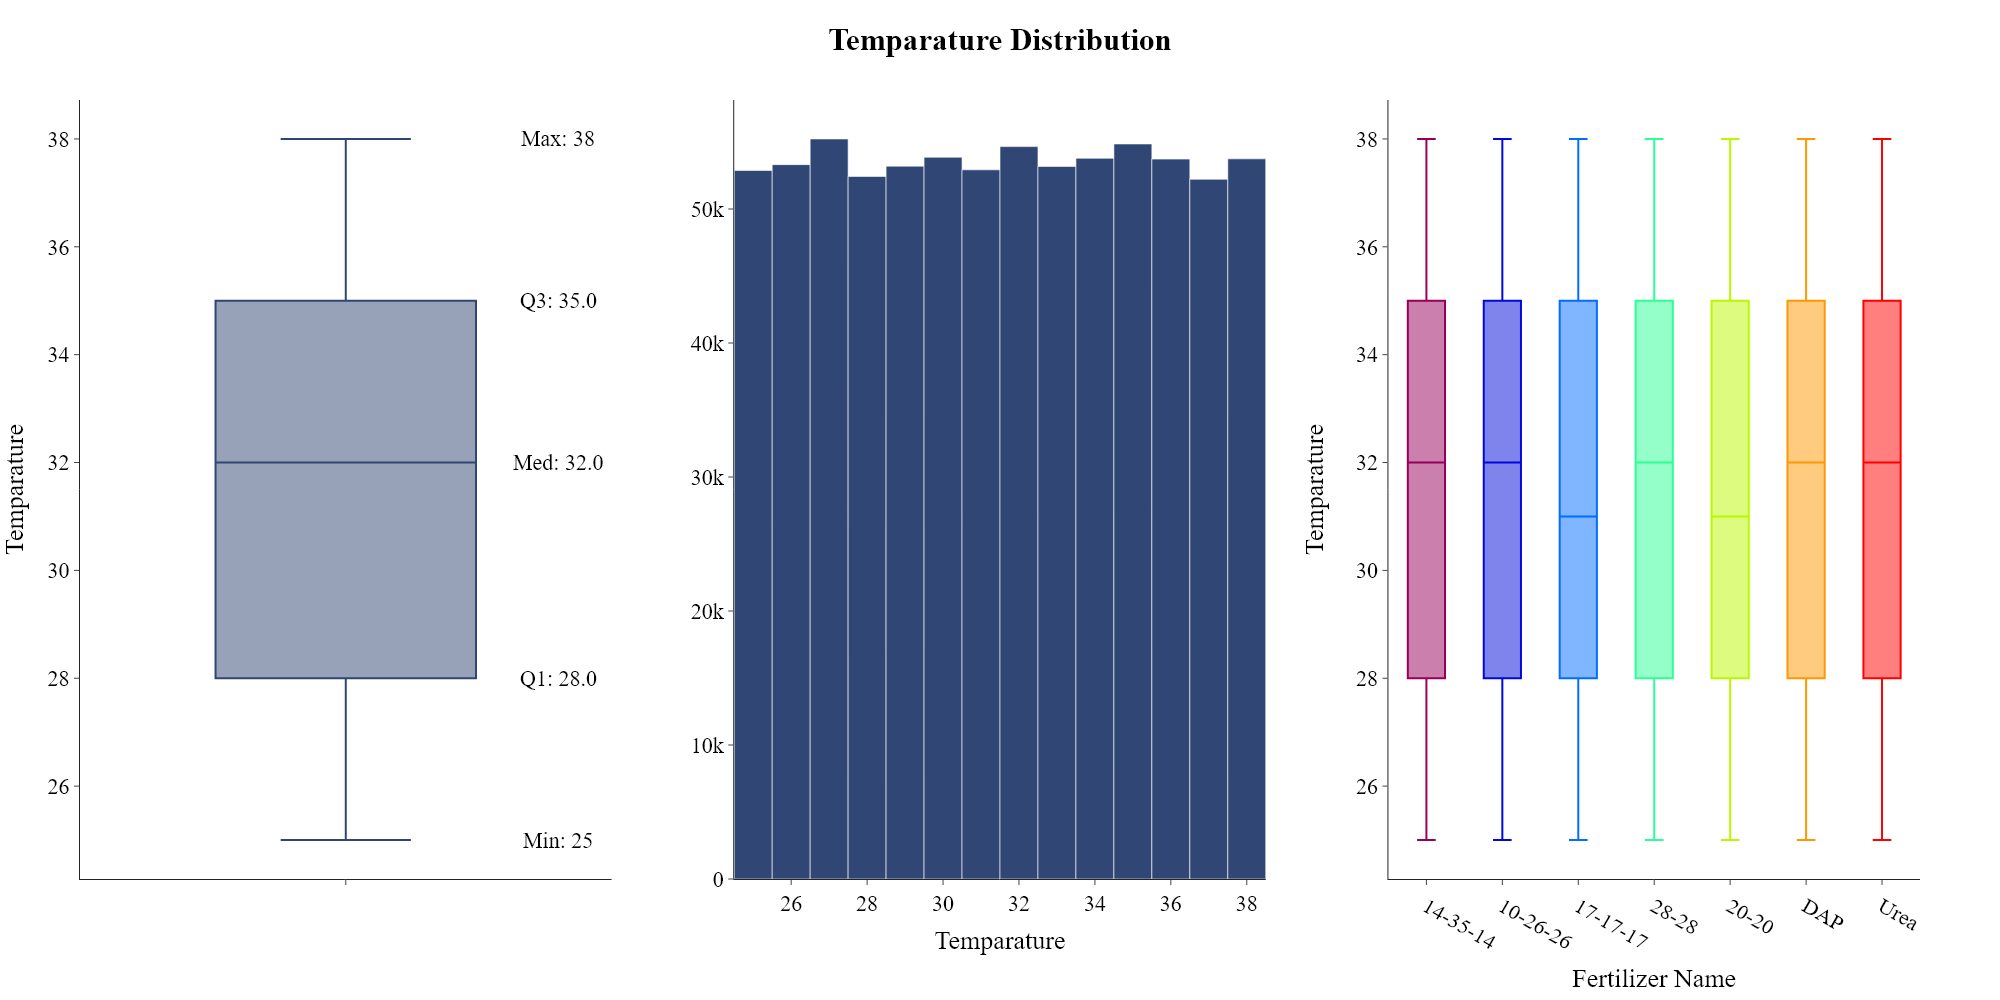

In [11]:
plots.boxplot_histogram_boxplot_by_hue(train_data, "Temparature", target_feature, bin_size=1, plot_title="Temparature distribution")

## `Humidity`

`Humidity` is a numerical feature representing the humidity percentage.

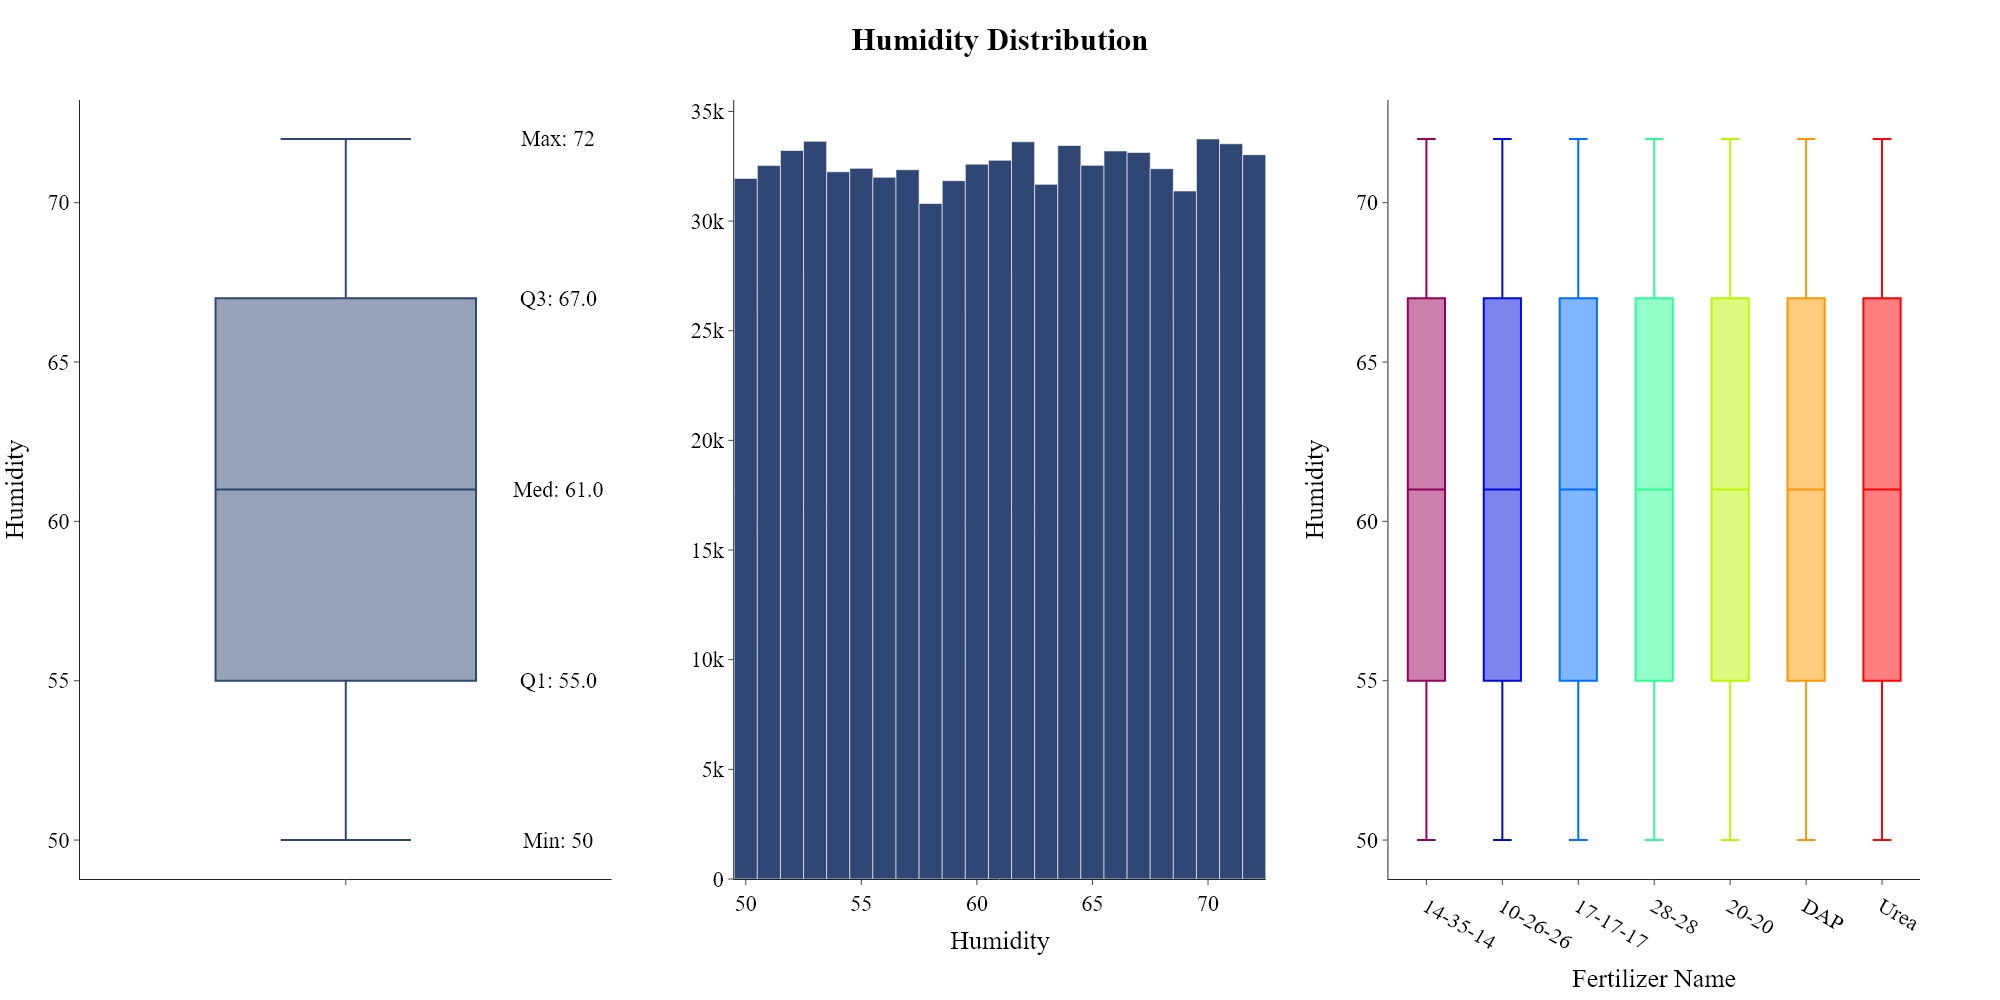

In [12]:
plots.boxplot_histogram_boxplot_by_hue(train_data, "Humidity", target_feature, bin_size=1, plot_title="Humidity distribution")

## `Moisture`

`Moisture` is a numerical feature representing the moisture level.

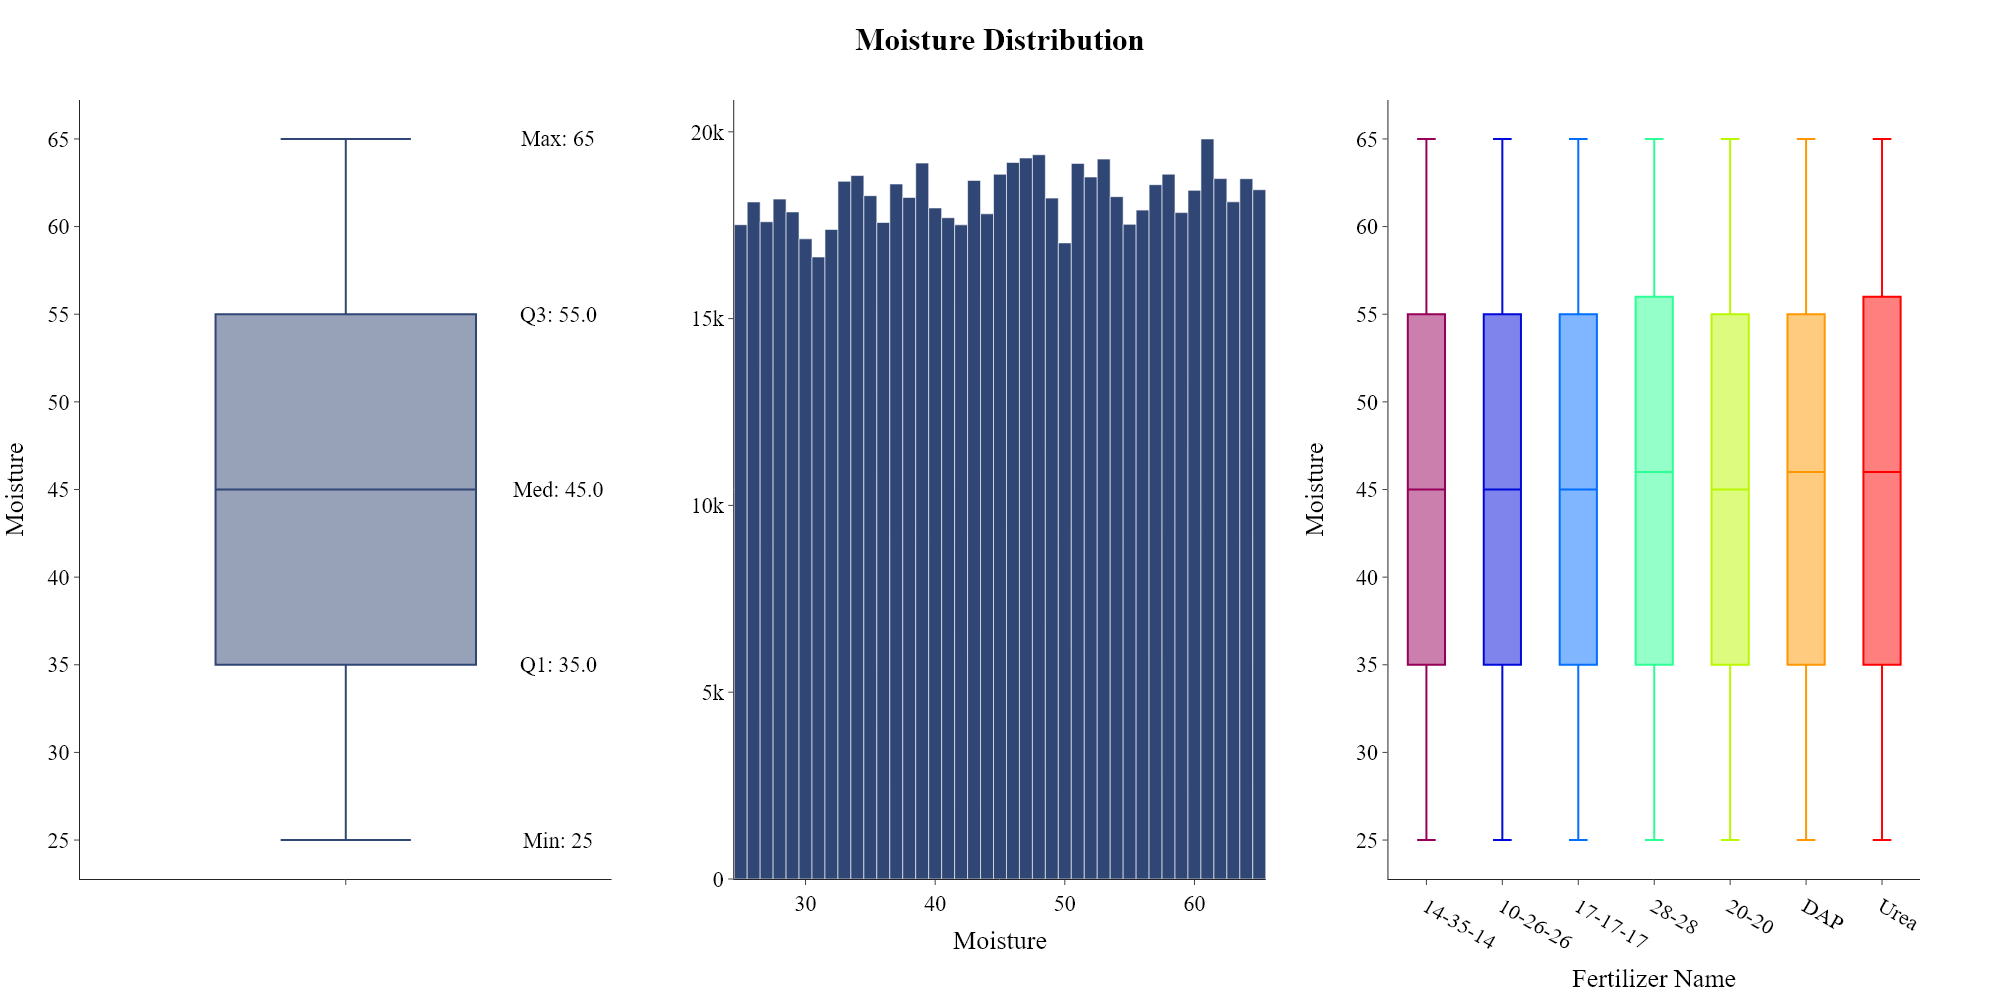

In [13]:
plots.boxplot_histogram_boxplot_by_hue(train_data, "Moisture", target_feature, bin_size=1, plot_title="Moisture distribution")

## `Soil Type`

`Soil Type` is a categorical feature representing the type of soil.

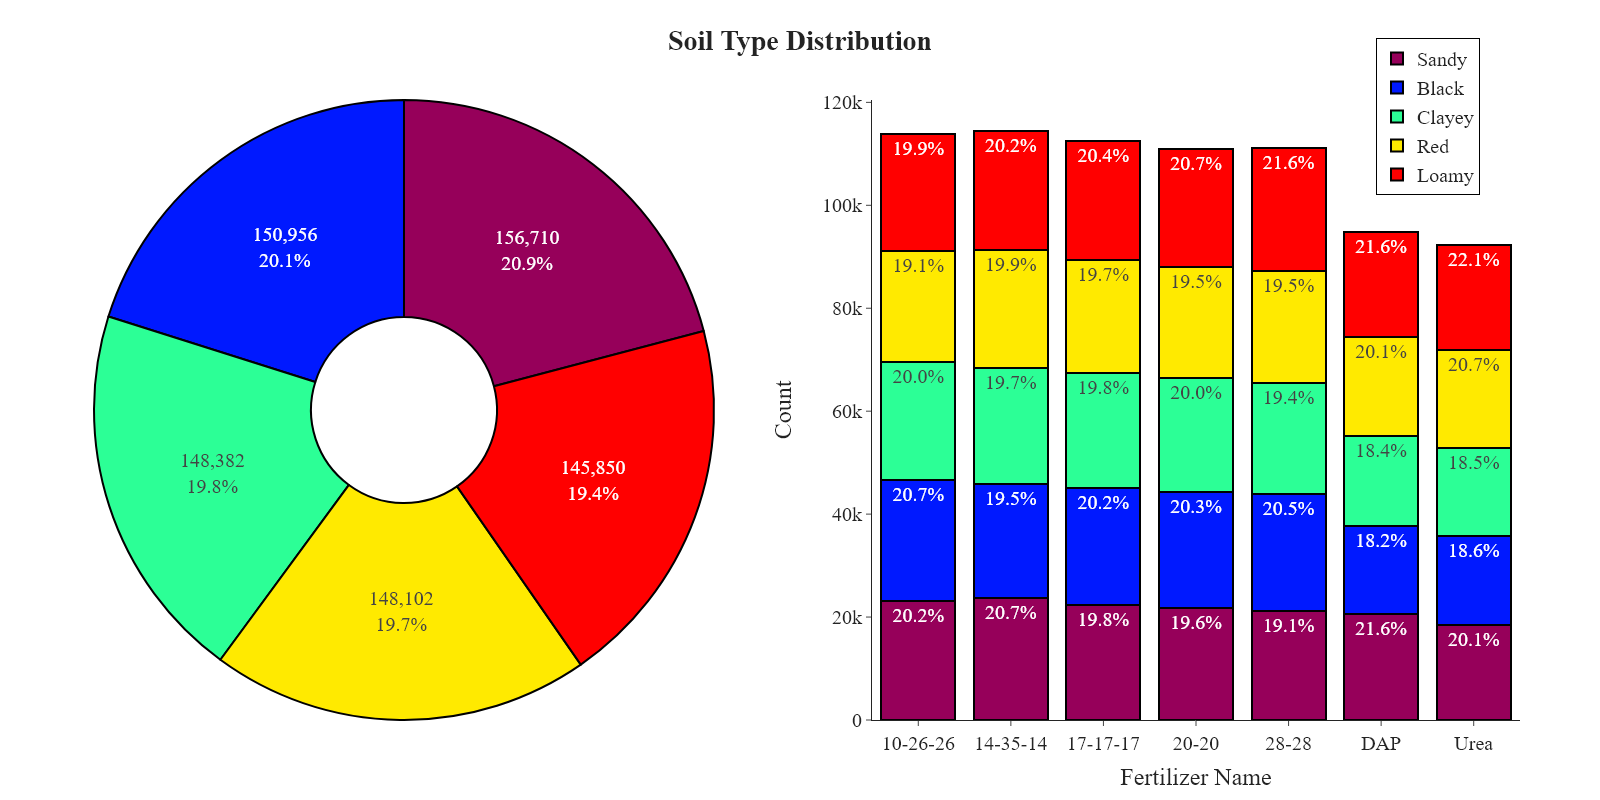

In [14]:
plots.pie_stacked_barplot_by_hue(train_data, "Soil Type", target_feature, plot_title="Soil Type distribution")

**Conclusion:**
- I will convert the `Soil Type` column to `category` dtype as it is a categorical variable (converting to `category` dtype reduces memory usage).

In [15]:
train_data['Soil Type'] = train_data['Soil Type'].astype('category')
test_data['Soil Type'] = test_data['Soil Type'].astype('category')

## `Crop Type`

`Crop Type` is a categorical feature representing the type of crop.

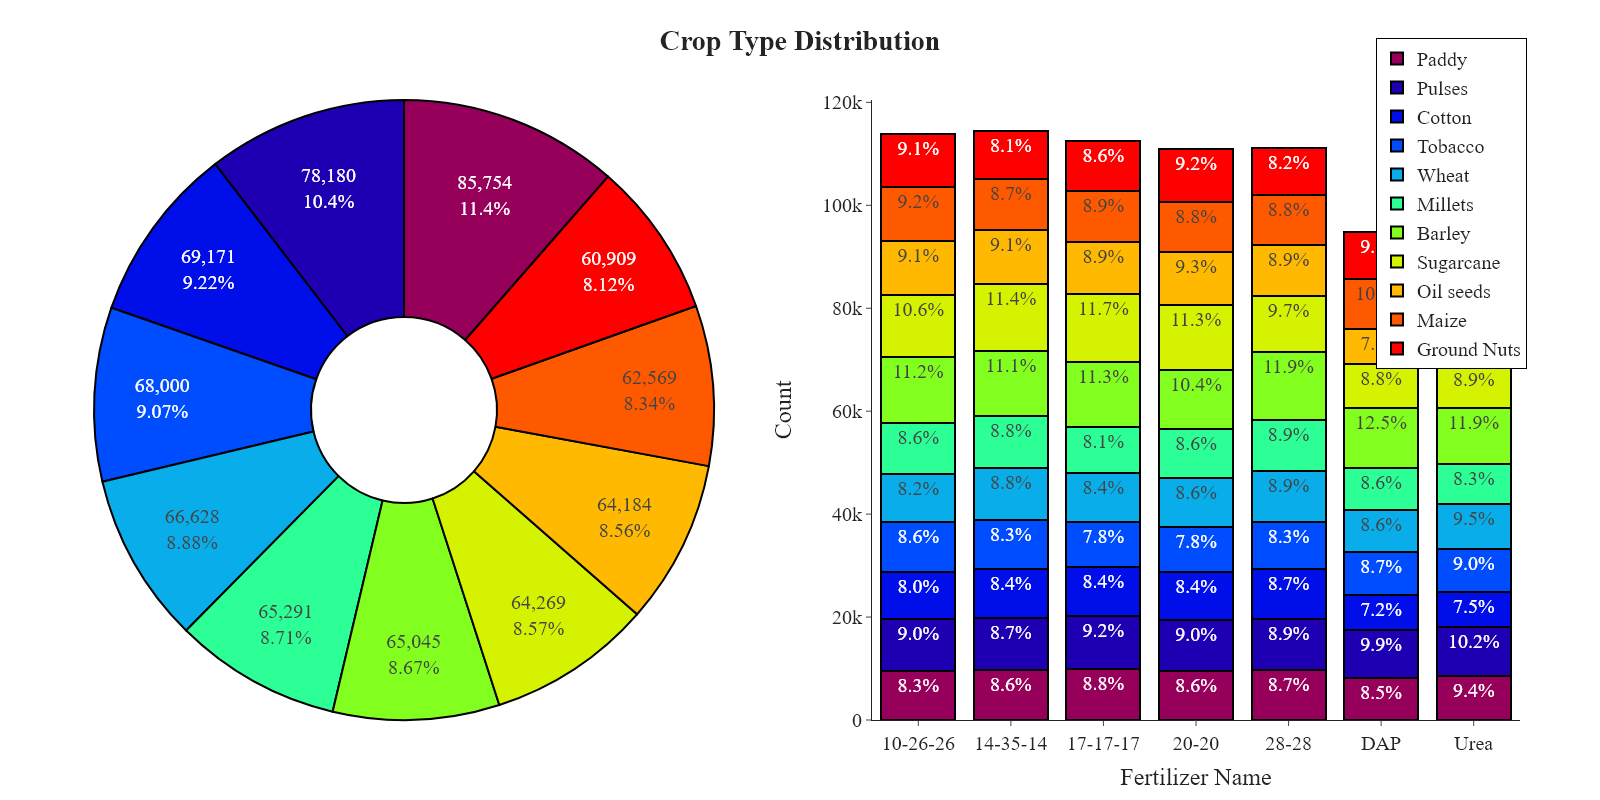

In [16]:
plots.pie_stacked_barplot_by_hue(train_data, "Crop Type", target_feature, plot_title="Crop Type distribution")

**Conclusion:**
- I will convert the `Crop Type` column to `category` dtype as it is a categorical variable (converting to `category` dtype reduces memory usage).

In [17]:
train_data['Crop Type'] = train_data['Crop Type'].astype('category')
test_data['Crop Type'] = test_data['Crop Type'].astype('category')

## `Nitrogen`

`Nitrogen` is a numerical feature representing the nitrogen level in the soil.

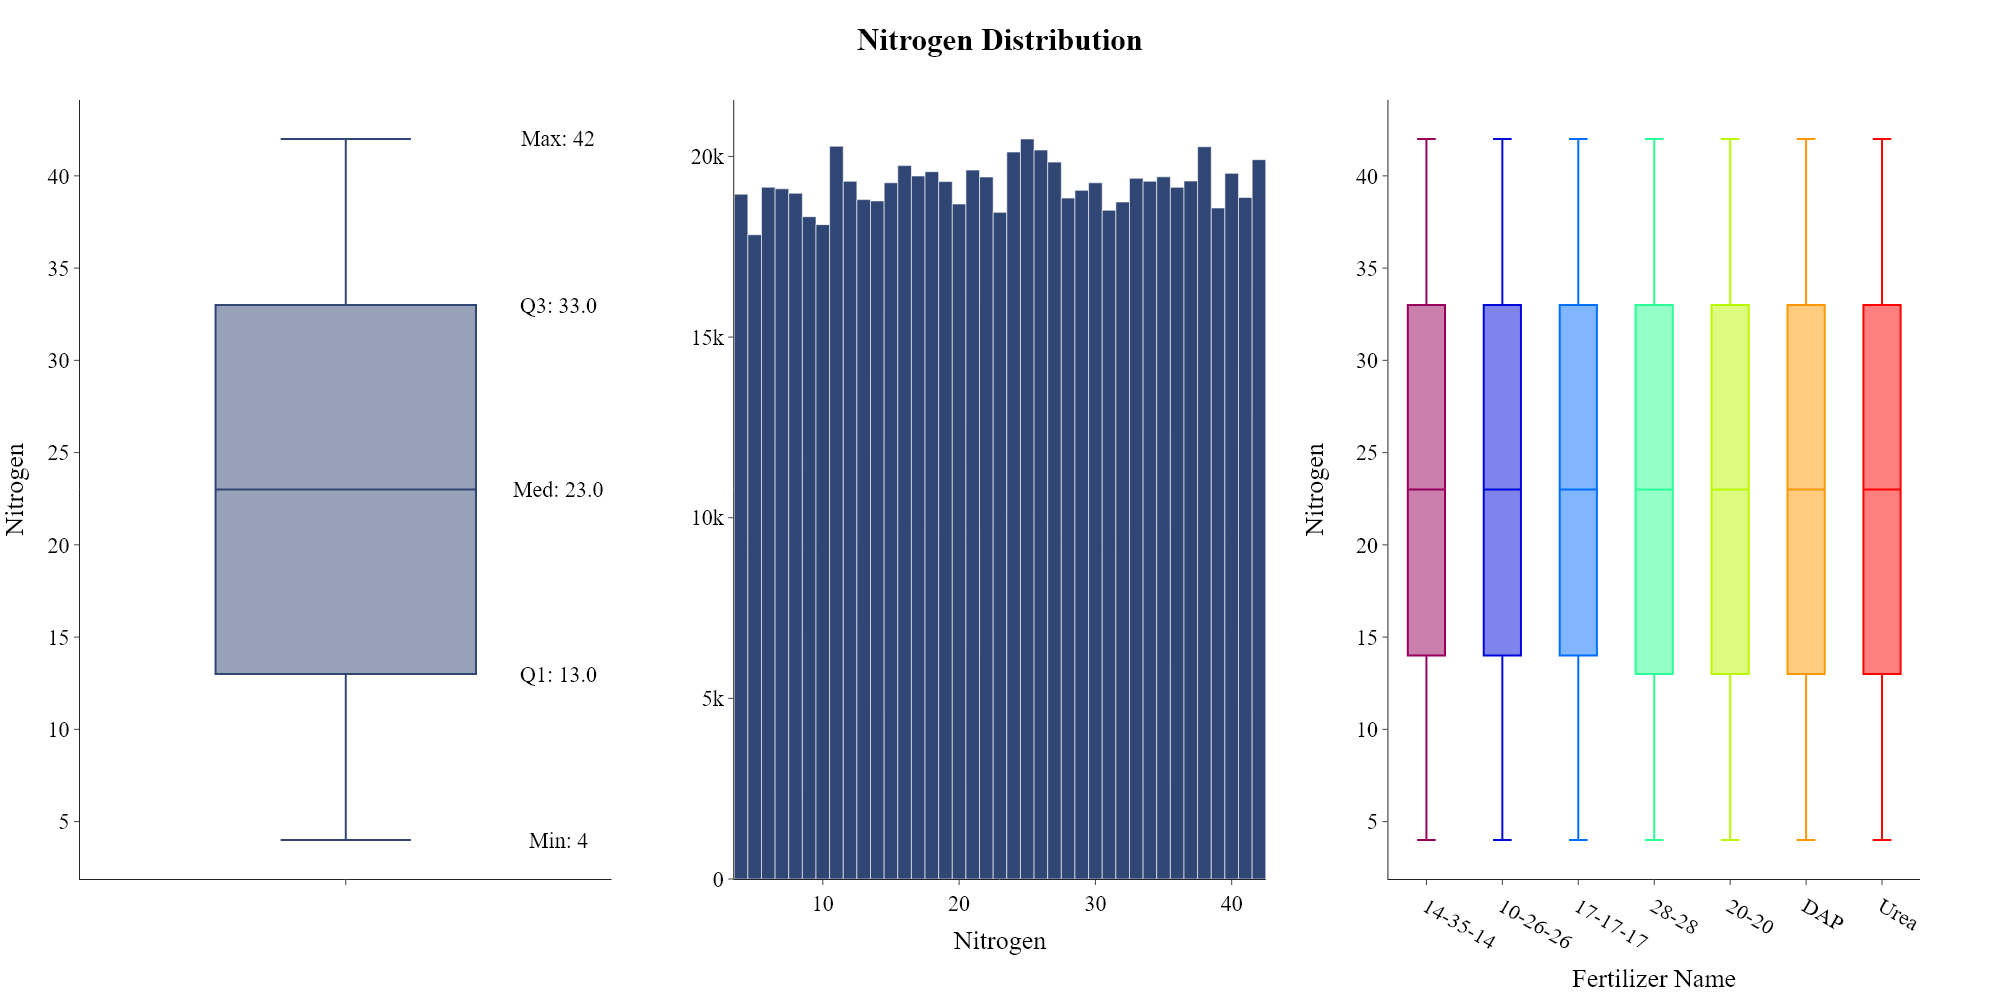

In [18]:
plots.boxplot_histogram_boxplot_by_hue(train_data, "Nitrogen", target_feature, bin_size=1, plot_title="Nitrogen distribution")

## `Potassium`

`Humidity` is a numerical feature representing the humidity percentage.

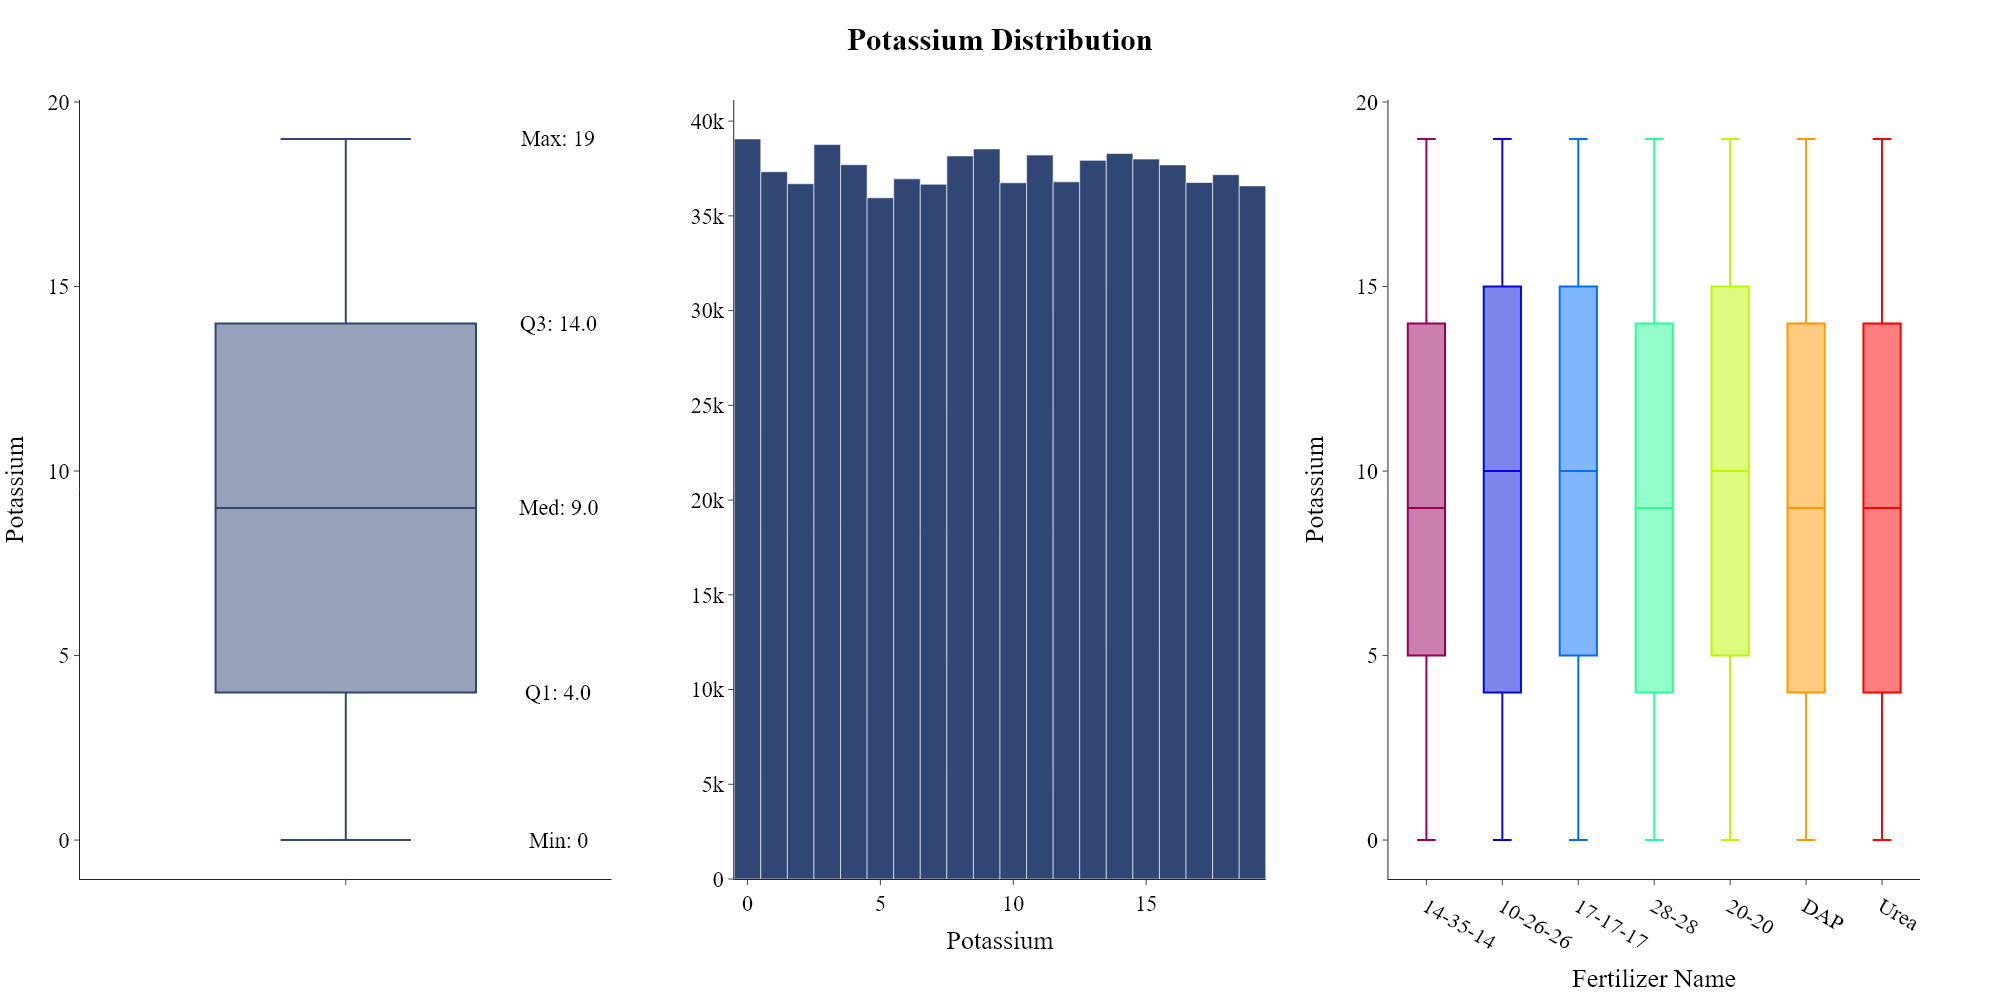

In [19]:
plots.boxplot_histogram_boxplot_by_hue(train_data, "Potassium", target_feature, bin_size=1, plot_title="Potassium distribution")

## `Phosphorous`

`Phosphorous` is a numerical feature representing the phosphorous level in the soil.

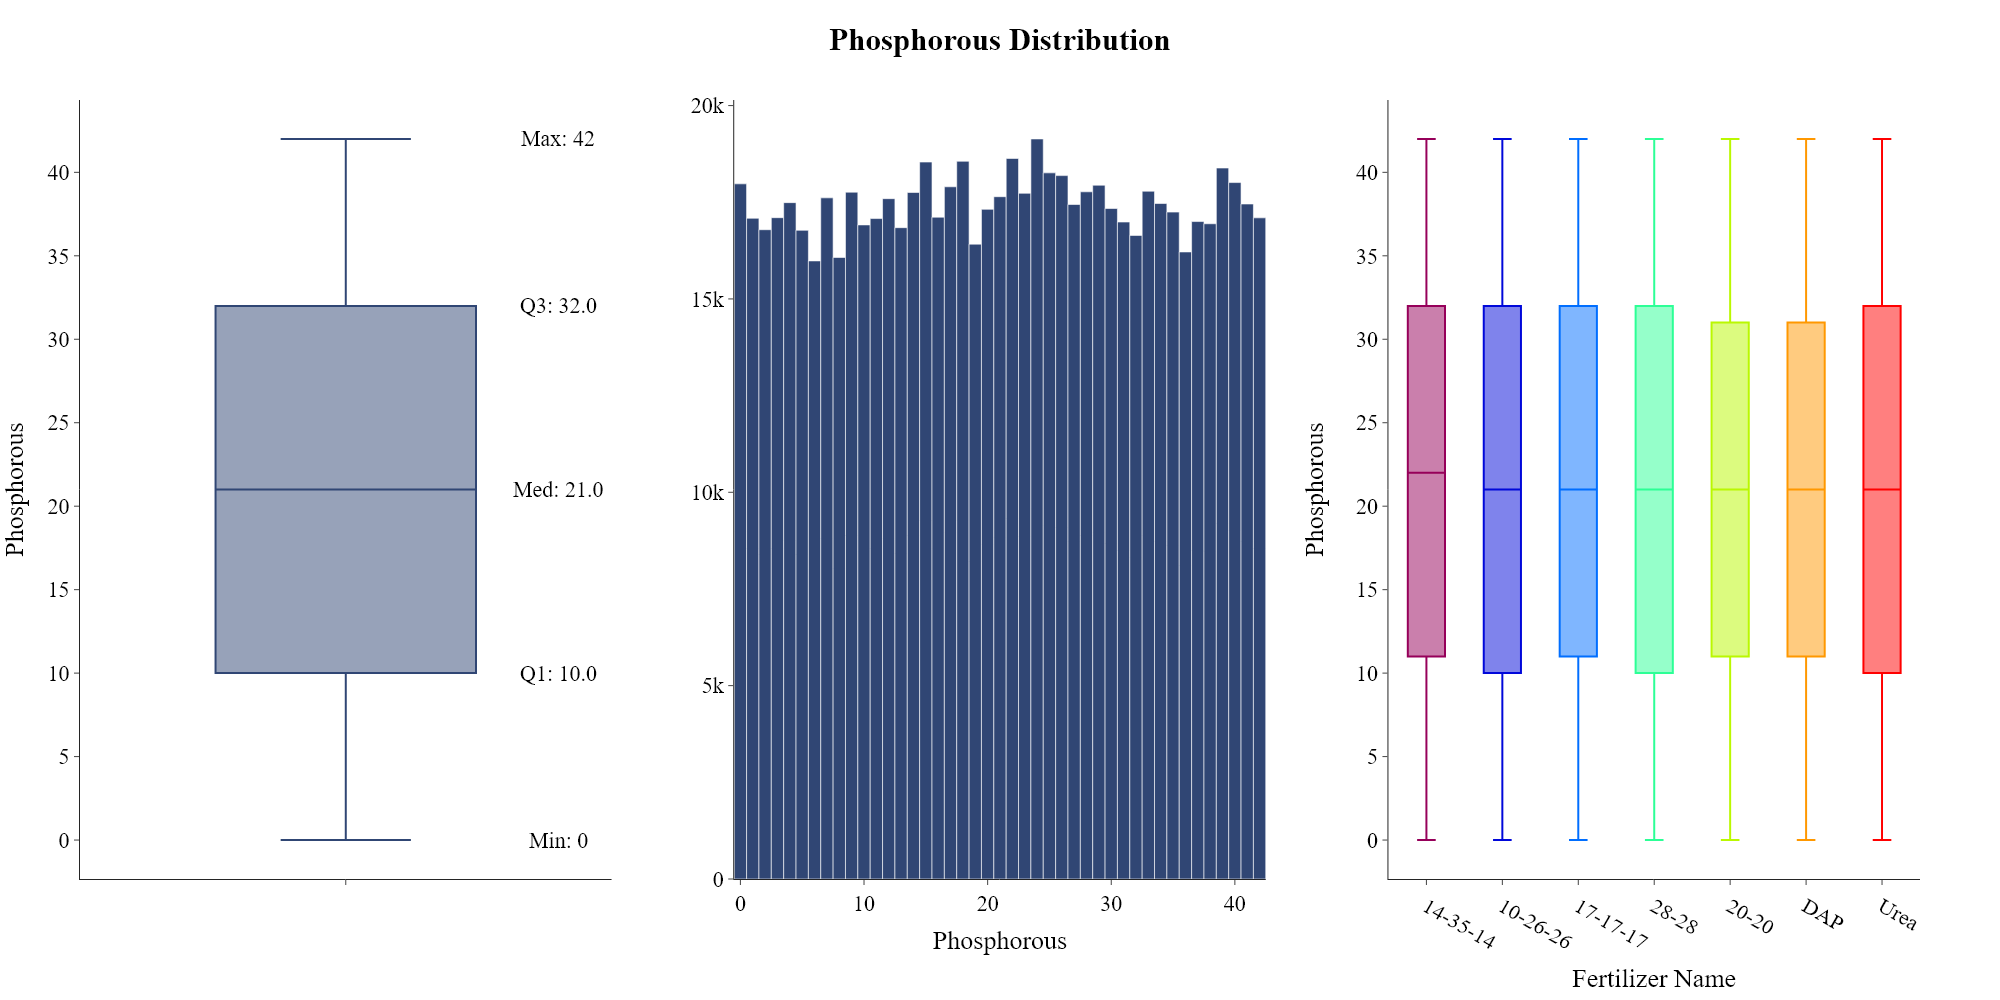

In [20]:
plots.boxplot_histogram_boxplot_by_hue(train_data, "Phosphorous", target_feature, bin_size=1, plot_title="Phosphorous distribution")

## `Fertilizer Name`

`Fertilizer Name` is the target variable, which is categorical and represents the type of fertilizer recommended for the crop.

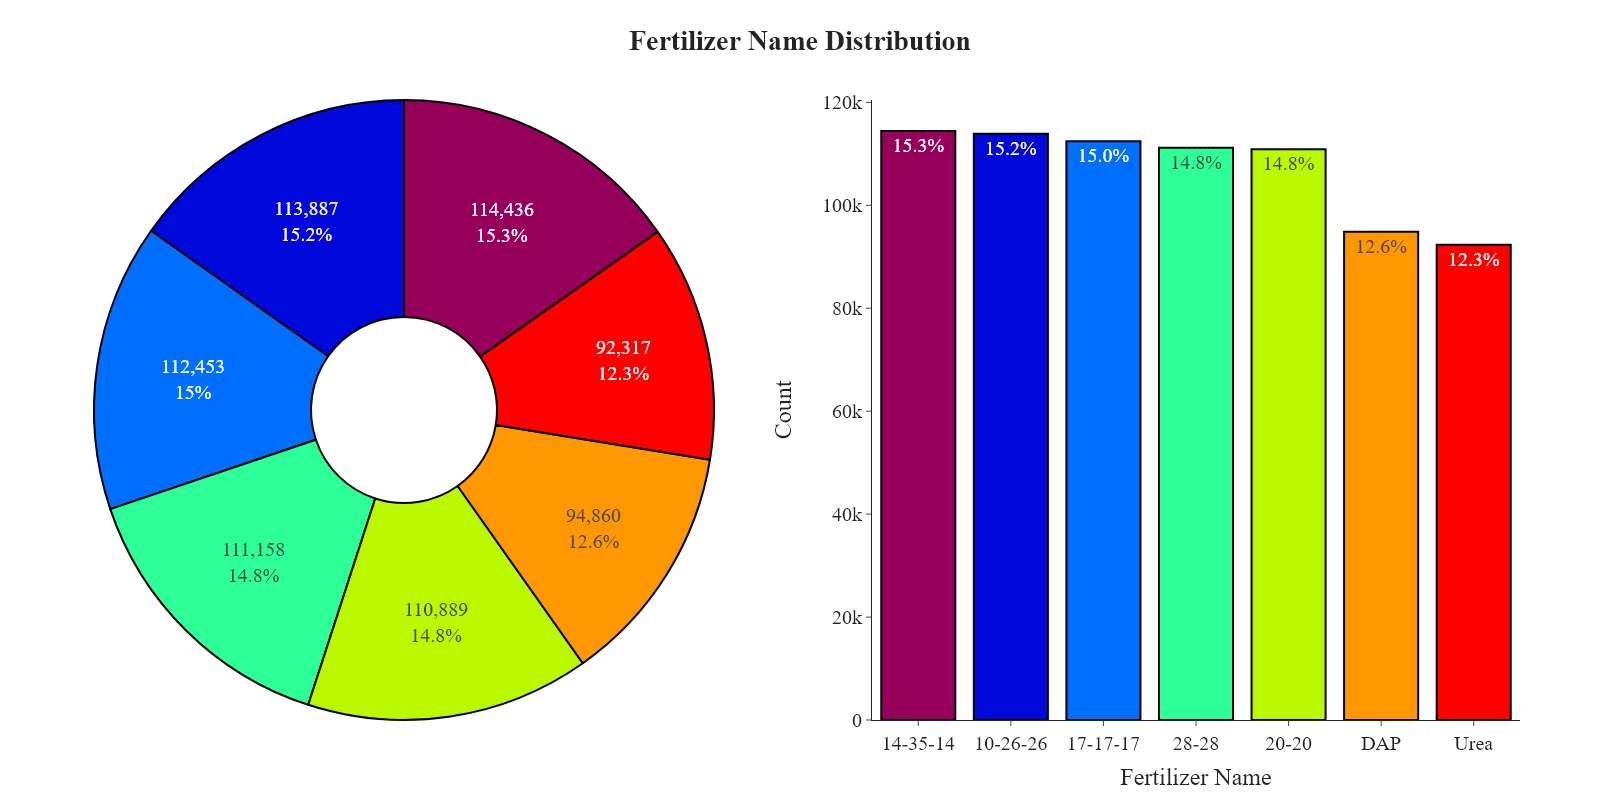

In [21]:
plots.pie_barplot(train_data, target_feature, plot_title=f"{target_feature} distribution")

**Conclusion:**
- I will convert the target feature to `category` dtype as it is a categorical variable (converting to `category` dtype reduces memory usage).

In [22]:
train_data[target_feature] = train_data[target_feature].astype('category')

## Feature engineering

In [23]:
def feature_engineering(df: pd.DataFrame) -> pd.DataFrame:
    """
    Perform feature engineering on the DataFrame.
    
    Args:
        df (pd.DataFrame): DataFrame to be processed.
    
    Returns:
        pd.DataFrame: DataFrame with new features added.
    """
    df = df.copy()
    df["N_P_diff"] = df["Nitrogen"] - df["Phosphorous"]
    df["N_K_ratio"] = df["Nitrogen"] / (df["Potassium"] + 1e-5)
    df["P_K_ratio"] = df["Phosphorous"] / (df["Potassium"] + 1e-5)
    df["Moisture_Humidity"] = df["Moisture"] * df["Humidity"]
    df["Temp_Humidity"] = df["Temparature"] * df["Humidity"]
    
    # Combine categorical features
    df["Crop_Soil"] = df["Crop Type"].astype(str) + "_" + df["Soil Type"].astype(str)
    df["Crop_Soil"] = df["Crop_Soil"].astype('category')
    
    # Binning numerical features into categories
    df["temp_bin"] = pd.cut(df["Temparature"], bins=[-np.inf, np.percentile(df["Temparature"], 25), np.percentile(df["Temparature"], 50), np.percentile(df["Temparature"], 75), np.inf], labels=["Low", "Medium", "High", "Very High"])
    df["humidity_bin"] = pd.cut(df["Humidity"], bins=[-np.inf, np.percentile(df["Humidity"], 25), np.percentile(df["Humidity"], 50), np.percentile(df["Humidity"], 75), np.inf], labels=["Low", "Medium", "High", "Very High"])
    df["moisture_bin"] = pd.cut(df["Moisture"], bins=[-np.inf, np.percentile(df["Moisture"], 25), np.percentile(df["Moisture"], 50), np.percentile(df["Moisture"], 75), np.inf], labels=["Low", "Medium", "High", "Very High"])
    
    # Optional: create binary flags for extreme conditions
    df["low_nitrogen"] = (df["Nitrogen"] < 50).astype(int)
    df["high_temp"] = (df["Temparature"] > 35).astype(int)
    return df

train_data = feature_engineering(train_data)
test_data = feature_engineering(test_data)

## Summary

In [24]:
numerical_features = train_data.select_dtypes(exclude=["category"]).columns.tolist()
categorical_features = train_data.select_dtypes(include=["category"]).columns.tolist()
if target_feature in categorical_features:
    label2id = {label: idx for idx, label in enumerate(train_data[target_feature].cat.categories)}
    id2label = {idx: label for label, idx in label2id.items()}
    print(id2label)
    train_data[target_feature] = train_data[target_feature].cat.codes
    categorical_features.remove(target_feature)
    num_classes = len(label2id)
independent_features = train_data.columns.difference([target_feature]).tolist()
independent_features_types = [(feature, train_data[feature].dtype) for feature in independent_features]
print("Independent features and their types:")
for feature, dtype in independent_features_types:
    print(f"- {feature} ({dtype}):", end="\n")

{0: '10-26-26', 1: '14-35-14', 2: '17-17-17', 3: '20-20', 4: '28-28', 5: 'DAP', 6: 'Urea'}
Independent features and their types:
- Crop Type (category):
- Crop_Soil (category):
- Humidity (int64):
- Moisture (int64):
- Moisture_Humidity (int64):
- N_K_ratio (float64):
- N_P_diff (int64):
- Nitrogen (int64):
- P_K_ratio (float64):
- Phosphorous (int64):
- Potassium (int64):
- Soil Type (category):
- Temp_Humidity (int64):
- Temparature (int64):
- high_temp (int32):
- humidity_bin (category):
- low_nitrogen (int32):
- moisture_bin (category):
- temp_bin (category):


In [25]:
base_information(train_data)

,dtypes,Number of missing values,Percentage of missing values,Unique values,Count
Temparature,int64,0,0.000000,14,750000
Humidity,int64,0,0.000000,23,750000
Moisture,int64,0,0.000000,41,750000
Soil Type,category,0,0.000000,5,750000
Crop Type,category,0,0.000000,11,750000
Nitrogen,int64,0,0.000000,39,750000
Potassium,int64,0,0.000000,20,750000
Phosphorous,int64,0,0.000000,43,750000
Fertilizer Name,int8,0,0.000000,7,750000
N_P_diff,int64,0,0.000000,81,750000


# Global data analysis

# Numerical data analysis

## Correlation matrix

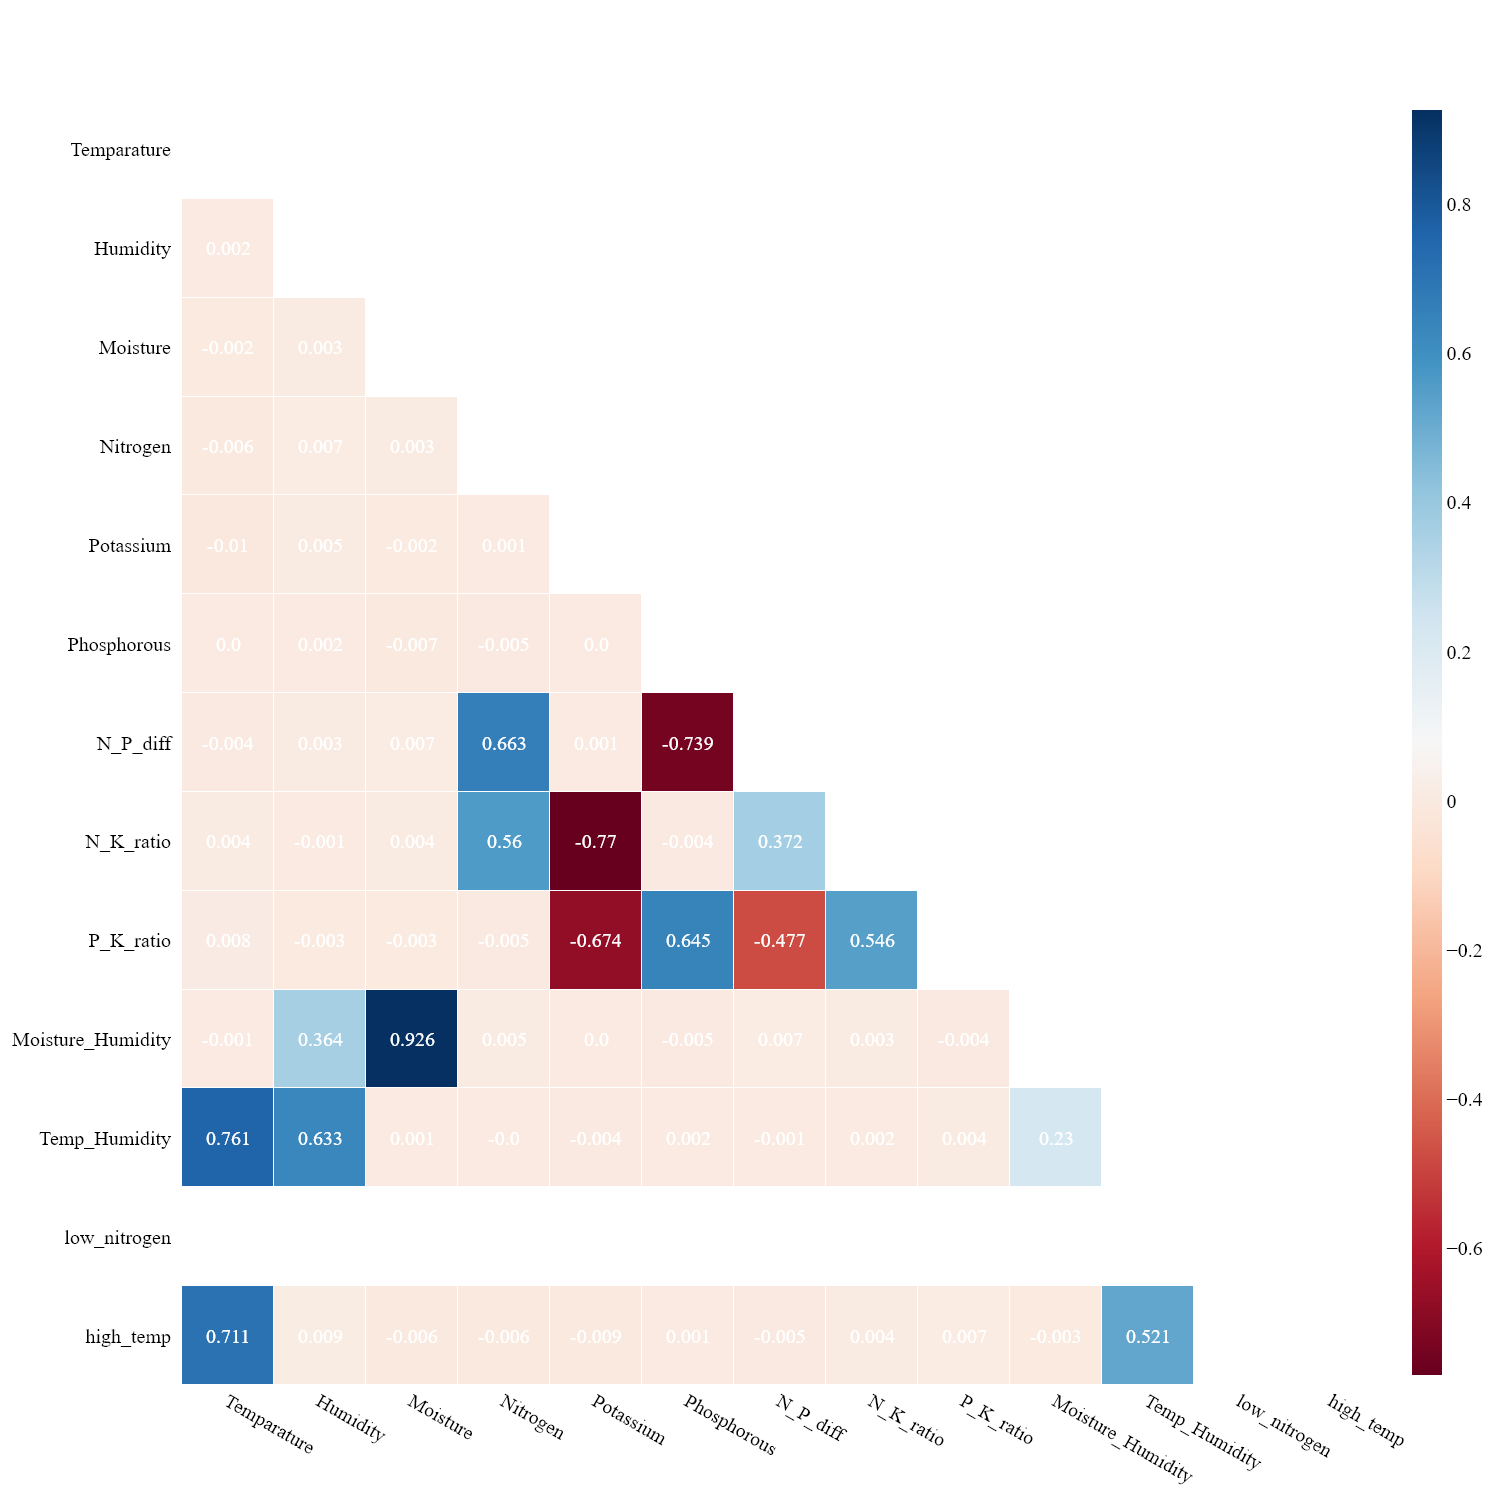

In [26]:
plots.correlation_plot(train_data[numerical_features], features_names=numerical_features, method="spearman")

## VIF

To check whether multi-collinearity is present in the dataset, we will calculate the Variance Inflation Factor (VIF) for each continuous feature.

In [27]:
vif_data = pd.DataFrame()
vif_data["feature"] = numerical_features
vif_data["VIF"] = [variance_inflation_factor(train_data[numerical_features].values, i) for i in range(len(numerical_features))] 
vif_data.sort_values("VIF", ascending=False, inplace=True)
vif_data.reset_index(drop=True, inplace=True)
vif_data

C:\Users\Kuba\AppData\Roaming\Python\Python311\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning:

divide by zero encountered in scalar divide

C:\Users\Kuba\AppData\Roaming\Python\Python311\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning:

divide by zero encountered in scalar divide

C:\Users\Kuba\AppData\Roaming\Python\Python311\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning:

divide by zero encountered in scalar divide



,feature,VIF
0,Nitrogen,inf
1,Phosphorous,inf
2,N_P_diff,inf
3,low_nitrogen,6637.457807
4,Temp_Humidity,146.953474
5,Moisture_Humidity,100.830874
6,Temparature,86.399216
7,Moisture,85.815364
8,Humidity,77.068211
9,N_K_ratio,2.581057


# Categorical data analysis

## Chi square test

Chi square test is used to determine whether there is a significant association between two categorical variables.

In [28]:
class Chi_Square_Test:
    def check_X(
        self, X: pd.DataFrame | pd.Series | np.ndarray
    ) -> np.ndarray:
        """
        Check if X is pandas DataFrame, pandas Series or numpy array and convert it to numpy array.

        Args:
            X: (pd.DataFrame | pd.Series | np.ndarray): input data.

        Returns:
            X: (np.ndarray): converted input data.
        """
        if (
            not isinstance(X, pd.DataFrame)
            and not isinstance(X, pd.Series)
            and not isinstance(X, np.ndarray)
        ):
            raise TypeError(
                "Wrong type of X. It should be pandas DataFrame, pandas Series, numpy array."
            )
        X = np.array(X)
        if X.ndim == 1:
            X = X[None, :]
        return X

    def check_y(
        self, y: pd.DataFrame | pd.Series | np.ndarray
    ) -> np.ndarray:
        """
        Check if y is pandas DataFrame, pandas Series or numpy array and convert it to numpy array.

        Args:
            y: (pd.DataFrame | pd.Series | np.ndarray): target data.

        Returns:
            y: (np.ndarray): converted target data.
        """
        if (
            not isinstance(y, pd.DataFrame)
            and not isinstance(y, pd.Series)
            and not isinstance(y, np.ndarray)
        ):
            raise TypeError(
                "Wrong type of y. It should be pandas DataFrame, pandas Series, numpy array."
            )
        y = np.array(y)
        if y.ndim != 1:
            y = y.squeeze()
        return y

    def check_for_object_columns(self, X: np.ndarray) -> np.ndarray:
        """
        Check if X contains object columns and convert it to numeric data.

        Args:
            X: (np.ndarray): input data.

        Returns:
            X: (np.ndarray): converted input data.
        """
        X = pd.DataFrame(X)
        if X.select_dtypes(include=np.number).shape[1] != X.shape[1]:
            raise TypeError(
                "Your data contains object or string columns. Numeric data is obligated."
            )
        return np.array(X)

    def fit(
        self,
        X: pd.DataFrame | pd.Series | np.ndarray,
        y: pd.DataFrame | pd.Series | np.ndarray,
        alpha: float = 0.05,
    ):
        """
        Perform Chi Square test.

        Args:
            X: (pd.DataFrame | pd.Series | np.ndarray): input data.
            y: (pd.DataFrame | pd.Series | np.ndarray): target data.
            alpha: (float): significance level.
        """
        # X = self.check_X(X)
        # X = self.check_for_object_columns(X)
        # y = self.check_y(y)
        self.crosstab_ = self.crosstab_creation(X=X, y=y)
        self.check_assumptions(crosstab=self.crosstab_)
        self.test_statistic_ = self.calculate_chi_square_statistic(
            crosstab=self.crosstab_
        )
        self.df_ = self.calculate_degrees_of_freedom(crosstab=self.crosstab_)
        self.p_value_ = self.calculate_p_value(
            test_statistic=self.test_statistic_, df=self.df_
        )
        self.critical_value_ = self.calculate_critical_value(df=self.df_, alpha=alpha)
        self.keep_H0 = self.statistical_inference(p_value=self.p_value_, alpha=alpha)
        self.V_Cramera_ = self.calculate_V_Cramera(
            test_statistic=self.test_statistic_, crosstab=self.crosstab_
        )

    def crosstab_creation(self, X: np.ndarray, y: np.ndarray) -> np.ndarray:
        """
        Create crosstab from input data.

        Args:
            X: (np.ndarray): input data.
            y: (np.ndarray): target data.

        Returns:
            crosstab: (np.ndarray): crosstab.
        """
        return np.array(pd.crosstab(X, y, margins=True))

    def check_assumptions(self, crosstab: np.ndarray) -> bool:
        """
        Check if assumptions for Chi Square test are met.

        Args:
            crosstab: (np.ndarray): crosstab.

        Raises:
            Warning: if assumptions are not met.
        """
        if not all(i <= 5 for i in crosstab.flatten()):
            self.assumption_ = False
            #warnings.warn("Assumptions for Chi Square test are not met.")
        else:
            self.assumption_ = True

    def calculate_chi_square_statistic(self, crosstab: np.ndarray) -> float:
        """
        Calculate Chi Square statistic.

        Args:
            crosstab: (np.ndarray): crosstab.

        Returns:
            chi_square: (float): Chi Square statistic.
        """
        chi_square = 0
        for row in range(0, crosstab.shape[0] - 1):
            for column in range(0, crosstab.shape[1] - 1):
                observed = crosstab[row][column]
                expected = crosstab[row][-1] * crosstab[-1][column] / crosstab[-1][-1]
                chi_square += (observed - expected) ** 2 / expected
        return chi_square

    def calculate_degrees_of_freedom(self, crosstab: np.ndarray) -> int:
        """
        Calculate degrees of freedom.

        Args:
            crosstab: (np.ndarray): crosstab.

        Returns:
            df: (int): degrees of freedom.
        """
        return (crosstab.shape[0] - 2) * (crosstab.shape[1] - 2)

    def calculate_p_value(self, test_statistic: float, df: int) -> float:
        """
        Calculate p value.

        Args:
            test_statistic: (float): test statistic.
            df: (int): degrees of freedom.

        Returns:
            p_value: (float): p value.
        """
        return 1 - chi2.cdf(x=test_statistic, df=df)

    def calculate_critical_value(self, df: int, alpha: float) -> float:
        """
        Calculate critical value.

        Args:
            df: (int): degrees of freedom.
            alpha: (float): significance level.

        Returns:
            critical_value: (float): critical value.
        """
        return chi2.isf(q=alpha, df=df)

    def statistical_inference(self, p_value: float, alpha: float) -> bool:
        """
        Perform statistical inference.

        Args:
            p_value: (float): p value.
            alpha: (float): significance level.

        Returns:
            bool: (bool): True if H0 is not rejected, False otherwise.
        """
        if p_value >= alpha:
            return True
        else:
            return False

    def calculate_V_Cramera(self, test_statistic: float, crosstab: np.ndarray) -> float:
        """
        Calculate V Cramer test statistic.

        Args:
            test_statistic: (float): test statistic.
            crosstab: (np.ndarray): crosstab.

        Returns:
            V_Cramer: (float): V Cramer test statistic.
        """
        return (
            test_statistic
            / (
                crosstab[-1][-1]
                * np.min([crosstab.shape[0] - 2, crosstab.shape[1] - 2])
            )
        ) ** 0.5

chi_square = Chi_Square_Test()

In [29]:
train_data_temp = train_data.copy()
chi_square_results = pd.DataFrame(columns=["Feature", "p_value", "Test statistic", "Critical value", "H0 rejected", "V Cramera"])
for feature in categorical_features:
    chi_square.fit(X=train_data_temp[feature], y=train_data_temp[f"{target_feature}"])
    chi_square_results = pd.concat([chi_square_results if not chi_square_results.empty else None, pd.DataFrame({"Feature": [feature], "p_value": [chi_square.p_value_], "Test statistic": [chi_square.test_statistic_], "Critical value": [chi_square.critical_value_], "H0 rejected": [not chi_square.keep_H0], "V Cramera": [chi_square.V_Cramera_]})])
chi_square_results.sort_values(by="Test statistic", ascending=False, inplace=True)
chi_square_results.reset_index(drop=True, inplace=True)
print(f"Percantage of features where H0 is not rejected (features are NOT associated with {target_feature}): {chi_square_results[chi_square_results['H0 rejected'] == False].shape[0]/len(chi_square_results)*100:.2f}%")
print(f"Percantage of features where H0 is rejected (features are associated with {target_feature}): {chi_square_results[chi_square_results['H0 rejected'] == True].shape[0]/len(chi_square_results)*100:.2f}%")
chi_square_results

Percantage of features where H0 is not rejected (features are NOT associated with Fertilizer Name): 0.00%
Percantage of features where H0 is rejected (features are associated with Fertilizer Name): 100.00%


,Feature,p_value,Test statistic,Critical value,H0 rejected,V Cramera
0,Crop_Soil,0.0,5615.891953,366.976967,True,0.035327
1,Crop Type,0.0,3094.462764,79.081944,True,0.026223
2,Soil Type,0.0,923.333302,36.415029,True,0.017544
3,moisture_bin,0.0,461.368265,28.869299,True,0.014320
4,humidity_bin,0.0,228.852274,28.869299,True,0.010085
5,temp_bin,0.0,165.592264,28.869299,True,0.008579


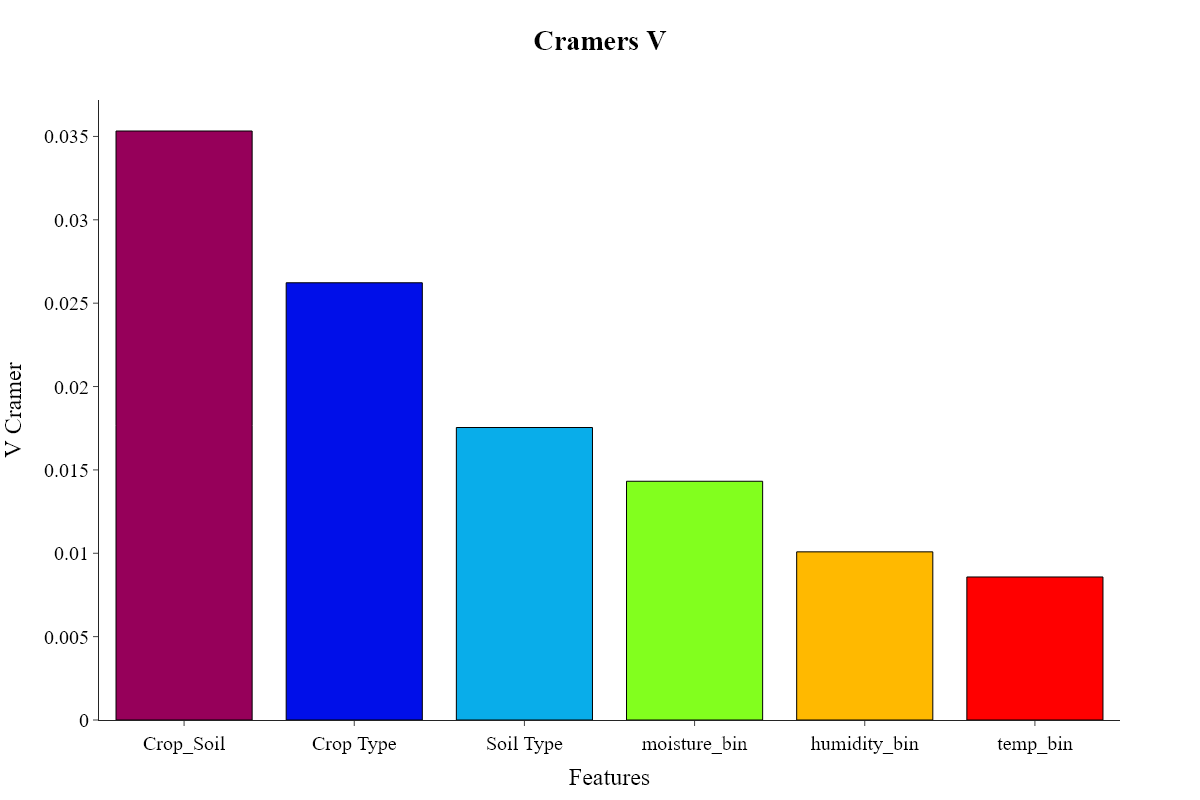

In [30]:
train_data_temp = train_data.copy()
chi_square_results_sorted = chi_square_results.sort_values(by="V Cramera", ascending=False)
fig = go.Figure()
n_colors = len(chi_square_results_sorted)
colors = px.colors.sample_colorscale("rainbow", [n/(n_colors - 1) for n in range(n_colors)])
fig.add_trace(go.Bar(x=chi_square_results_sorted["Feature"], y=chi_square_results_sorted["V Cramera"], marker=dict(color=colors, line=dict(color='black', width=1), line_color='black')))
fig.update_xaxes(title_text="Features")
fig.update_yaxes(title_text="V Cramer")
fig.update_layout(template="simple_white", width=1200, height=800, title="<b>Cramers V<b>", title_x=0.5, font=dict(family="Times New Roman", size=20, color="Black"))
fig.show("png")

# All features

## Mutual information

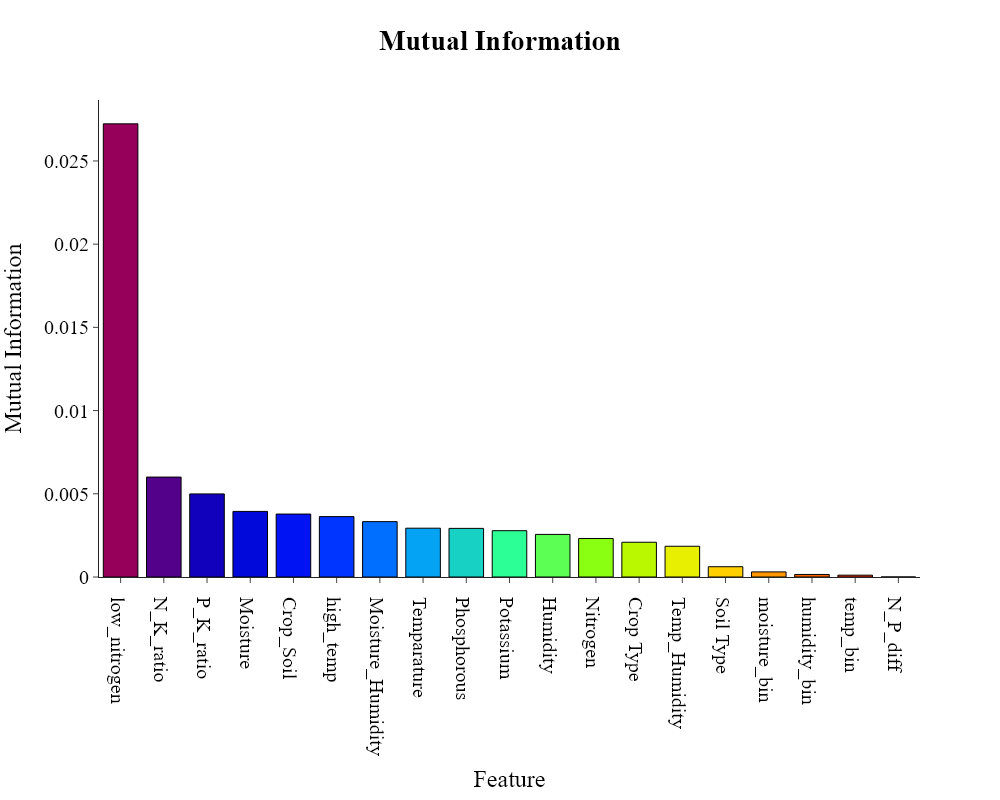

In [31]:
ordinal_encoder = OrdinalEncoder()
train_data_temp[categorical_features] = ordinal_encoder.fit_transform(train_data_temp[categorical_features])
mi_scores = {}
for feature in independent_features:
    if feature in categorical_features:
        mi_scores[feature] = mutual_info_classif(train_data_temp[[feature]], train_data_temp[target_feature], random_state=SEED, discrete_features=True)[0]
    else:
        mi_scores[feature] = mutual_info_classif(train_data_temp[[feature]], train_data_temp[target_feature], random_state=SEED)[0]
mi_scores = {k: v for k, v in sorted(mi_scores.items(), key=lambda item: item[1], reverse=True)}
fig = go.Figure()
n_colors = len(mi_scores)
colors = px.colors.sample_colorscale("rainbow", [n/(n_colors -1) for n in range(n_colors)])
fig.add_trace(go.Bar(x=list(mi_scores.keys()), y=list(mi_scores.values()), marker=dict(color=colors, line=dict(color='black', width=1), line_color='black')))
fig.update_layout(template="simple_white", width=1000, height=800, title="<b>Mutual Information<b>", title_x=0.5, xaxis_title="Feature", yaxis_title=f"Mutual Information", font=dict(family="Times New Roman",size=20,color="Black"), showlegend=False)
fig.show("png")

## Outliers

Before applying Isolation Forest we will convert categorical features with the usage of pandas `get_dummies` function.

In [32]:
train_data_temp = train_data.copy()
train_data_temp.drop(target_feature, axis=1, inplace=True)
train_data_temp = pd.get_dummies(train_data_temp, columns=categorical_features, drop_first=True)

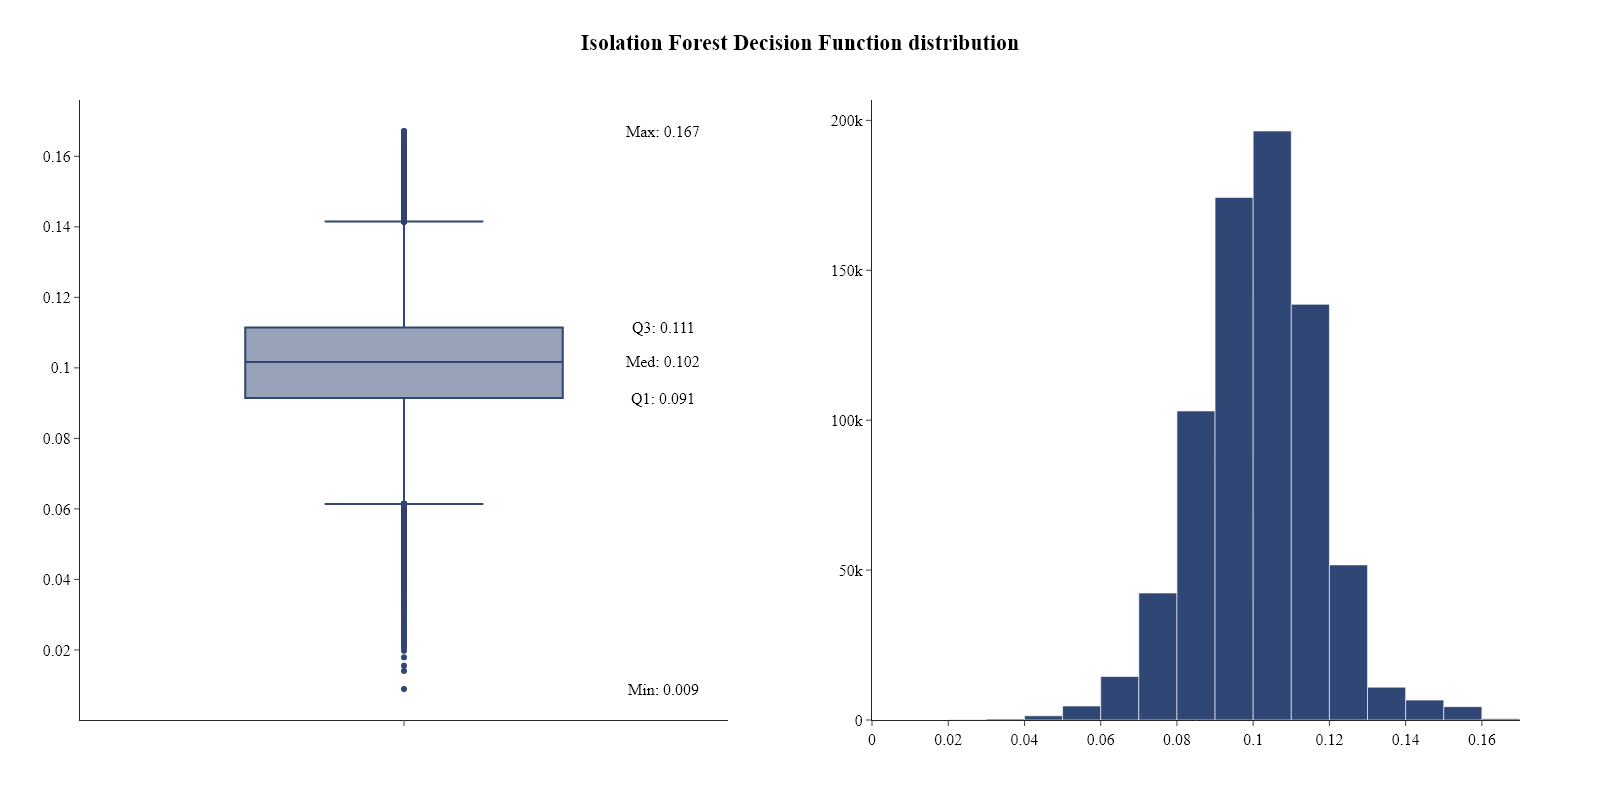

Number of outliers: 0.
Proportion of outliers: 0.0%.


In [33]:
isolation_forest = IsolationForest(random_state=SEED, n_jobs=-1)
isolation_forest.fit(train_data_temp)
plots.histogram_and_box_plot(data=isolation_forest.decision_function(train_data_temp), name="Isolation Forest Decision Function", annotations=True, bin_size=0.01)
outliers = isolation_forest.predict(train_data_temp)
outliers = pd.Series(outliers)
print("Number of outliers: {}.".format(outliers[outliers == -1].shape[0]))
print("Proportion of outliers: {}%.".format(np.round(outliers[outliers == -1].shape[0] / train_data_temp.shape[0] * 100, 2)))

Before UMAP which is time consuming I will limit dataset to 10k observations.

In [34]:
train_data_temp = train_data_temp.sample(min(train_data_temp.shape[0], 10000))
outliers = isolation_forest.predict(train_data_temp)
outliers = pd.Series(outliers)

C:\Users\Kuba\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

C:\Users\Kuba\AppData\Roaming\Python\Python311\site-packages\umap\umap_.py:1943: UserWarning:

n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.



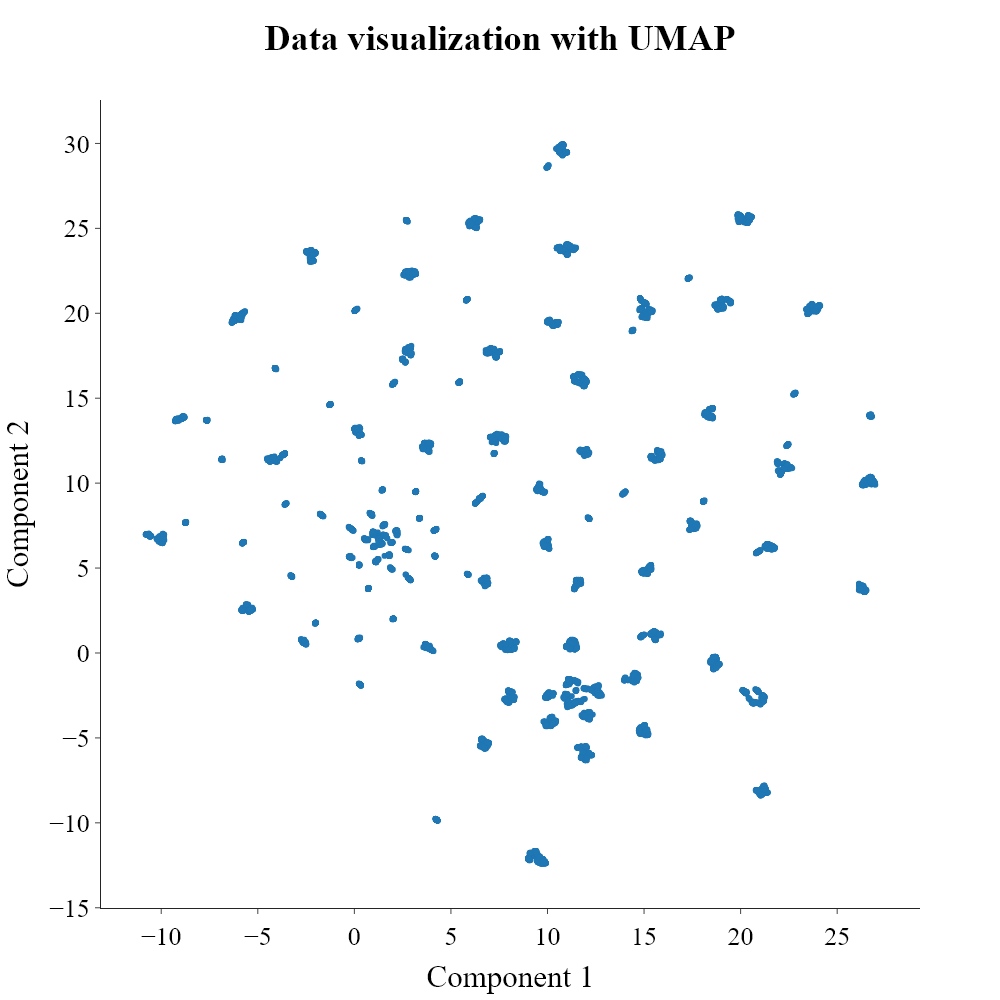

In [35]:
scaler = MinMaxScaler()
umap_model = UMAP(n_components=2, random_state=SEED, n_jobs=-1)
train_data_temp_scaled = scaler.fit_transform(train_data_temp)
X_umap = umap_model.fit_transform(train_data_temp_scaled)
plots.scatter_plot(data=X_umap, hue=outliers, hue_name="Outliers", name="Data visualization with UMAP")

**Notes:**
- We can clearly see some clusters in the data.
- It does not look like outliers were correctly detected by Isolation Forest (at least based on UMAP plot).

In [36]:
del train_data_temp, train_data_temp_scaled

# Modeling

## Base models

### LightGBM

In [37]:
model = LGBMClassifier(random_state=SEED, verbose=-1, n_jobs=-1, objective='multiclass', num_class=num_classes, metric='multi_logloss', early_stopping_rounds=100)
train_scores, validation_scores = perform_cv(train_data[independent_features], train_data[target_feature], model, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED), metric_name=compare_metric_name)
print(f"Train {compare_metric_name}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {compare_metric_name}: {np.mean(validation_scores):.4f} +- {np.std(validation_scores):.4f}")

Train Mean Average Precision: 0.3787 +- 0.0003
Validation Mean Average Precision: 0.3171 +- 0.0006


### XGBoost

In [38]:
model = XGBClassifier(random_state=SEED, n_jobs=-1, objective='multi:softmax', num_class=num_classes, eval_metric='mlogloss', enable_categorical=True, tree_method='hist', early_stopping_rounds=100)
train_scores, validation_scores = perform_cv(train_data[independent_features], train_data[target_feature], model, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED), metric_name=compare_metric_name)
print(f"Train {compare_metric_name}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {compare_metric_name}: {np.mean(validation_scores):.4f} +- {np.std(validation_scores):.4f}")

Train Mean Average Precision: 0.4117 +- 0.0023
Validation Mean Average Precision: 0.3194 +- 0.0011


### Histogram-based Gradient Boosting

In [39]:
model = HistGradientBoostingClassifier(random_state=SEED, categorical_features=categorical_features)
train_scores, validation_scores = perform_cv(train_data[independent_features], train_data[target_feature], model, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED), metric_name=compare_metric_name)
print(f"Train {compare_metric_name}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {compare_metric_name}: {np.mean(validation_scores):.4f} +- {np.std(validation_scores):.4f}")

Train Mean Average Precision: 0.3863 +- 0.0004
Validation Mean Average Precision: 0.3168 +- 0.0009


### CatBoost

In [40]:
model = CatBoostClassifier(random_state=SEED, verbose=0, cat_features=categorical_features, task_type='GPU', loss_function='MultiClass', eval_metric='MultiClass', early_stopping_rounds=100)
train_scores, validation_scores = perform_cv(train_data[independent_features], train_data[target_feature], model, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED), metric_name=compare_metric_name)
print(f"Train {compare_metric_name}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {compare_metric_name}: {np.mean(validation_scores):.4f} +- {np.std(validation_scores):.4f}")

Train Mean Average Precision: 0.3900 +- 0.0052
Validation Mean Average Precision: 0.3253 +- 0.0004


## Ensemble model

In [41]:
class EnsembleWeightTunerCV:
    def __init__(
        self,
        estimators: list,
        metric: str,
        cv=KFold(n_splits=5, shuffle=True, random_state=42),
        n_trials: int = 50,
        seed: int = 17
    ):
        self.estimators = estimators
        self.cv = cv
        self.n_trials = n_trials
        self.seed = seed

        if metric not in METRICS:
            raise ValueError(f"Unsupported metric: {metric}. Supported: {', '.join(METRICS.keys())}")
        self.eval_metric = METRICS[metric][0]
        self.metric_type = METRICS[metric][1]
        self.direction = METRICS[metric][2]

    def tune(self, X, y) -> optuna.Study:
        # X_sample = X.sample(n=min(20000, X.shape[0]))
        # y_sample = y[X_sample.index]
        X_sample = X.sample(n=min(X.shape[0], X.shape[0]))
        y_sample = y[X_sample.index]
        y_true, y_pred = self.perform_cv(X_sample, y_sample)
        study = self.create_study()
        study.optimize(
            lambda trial: self.objective(trial, y_true, y_pred),
            n_trials=self.n_trials,
        )
        self.best_weights = np.array([study.best_params[f"w{i}"] for i in range(len(self.estimators))])
        self.best_weights = self.best_weights / self.best_weights.sum()
        return study
    
    def create_study(self) -> optuna.study.Study:
        sampler = optuna.samplers.TPESampler(seed=self.seed)
        return optuna.create_study(
            direction=self.direction,
            sampler=sampler,
            study_name="Weight Tuning Study",
        )

    def objective(self, trial, y_true, y_pred):
        weights = np.array([trial.suggest_float(f"w{i}", 0.01, 0.99) for i in range(len(self.estimators))])
        weights /= weights.sum()
        blended = sum(w * p for w, p in zip(weights, y_pred))
        if self.metric_type == "preds":
            try:
                return self.eval_metric(y_true, blended)
            except:
                blended = np.round(blended).astype(int)
                return self.eval_metric(y_true, blended)
        return self.eval_metric(y_true, blended)

    def perform_cv(self, X: pd.DataFrame, y: pd.Series) -> tuple:
        y_valid_true = []
        y_valid_pred = [[] for _ in range(len(self.estimators))]
        for train_idx, valid_idx in self.cv.split(X, y):
            X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
            y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
            y_valid_true.extend(y_valid.tolist())
            for i, estimator in enumerate(self.estimators):
                _, pred = fit_and_predict(
                    estimator, X_train, y_train, X_valid, y_valid, metric_type=self.metric_type
                )
                y_valid_pred[i].extend(pred.tolist())
        y_valid_true = np.array(y_valid_true)
        y_valid_pred = [np.array(pred) for pred in y_valid_pred]
        return y_valid_true, y_valid_pred

    @staticmethod
    def check_X(X: object) -> pd.DataFrame:
        return X if isinstance(X, pd.DataFrame) else pd.DataFrame(X)

    @staticmethod
    def check_y(y: object) -> pd.Series:
        return y if isinstance(y, pd.Series) else pd.Series(y)
    

ensemble_weights_tuner = EnsembleWeightTunerCV(
    estimators = [
    LGBMClassifier(random_state=SEED, verbose=-1, n_jobs=-1, objective='multiclass', num_class=num_classes, metric='multi_logloss', early_stopping_rounds=100),
    XGBClassifier(random_state=SEED, n_jobs=-1, objective='multi:softmax', num_class=num_classes, eval_metric='mlogloss', enable_categorical=True, tree_method='hist', early_stopping_rounds=100),
    HistGradientBoostingClassifier(random_state=SEED, categorical_features=categorical_features),
    CatBoostClassifier(random_state=SEED, verbose=0, cat_features=categorical_features, task_type='GPU', loss_function='MultiClass', eval_metric='MultiClass', early_stopping_rounds=100)
],
    metric=compare_metric_name,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    n_trials=N_TRIALS*2,
    seed=SEED
)
ensemble_weights_tuner.tune(train_data[independent_features], train_data[target_feature])
best_weights = ensemble_weights_tuner.best_weights
for i, estimator in enumerate(ensemble_weights_tuner.estimators):
    print(f"Estimator {i}: {estimator.__class__.__name__}, Weight: {best_weights[i]:.4f}")

[I 2025-06-10 08:12:34,390] A new study created in memory with name: Weight Tuning Study
[I 2025-06-10 08:12:35,390] Trial 0 finished with value: 0.32241000000000014 and parameters: {'w0': 0.2987717026333675, 'w1': 0.5299750204931882, 'w2': 0.19769037120854496, 'w3': 0.07654235102746554}. Best is trial 0 with value: 0.32241000000000014.
[I 2025-06-10 08:12:36,889] Trial 1 finished with value: 0.324860888888889 and parameters: {'w0': 0.7812457507999151, 'w1': 0.6532068513403384, 'w2': 0.6347704781227631, 'w3': 0.5740908358779733}. Best is trial 1 with value: 0.324860888888889.
[I 2025-06-10 08:12:38,421] Trial 2 finished with value: 0.3209311111111112 and parameters: {'w0': 0.04828165786508915, 'w1': 0.3606573323938779, 'w2': 0.9367695230820394, 'w3': 0.06884378670907763}. Best is trial 1 with value: 0.324860888888889.
[I 2025-06-10 08:12:39,611] Trial 3 finished with value: 0.32567377777777784 and parameters: {'w0': 0.8567612614752868, 'w1': 0.8697447156250696, 'w2': 0.0601697923080446

Estimator 0: LGBMClassifier, Weight: 0.0449
Estimator 1: XGBClassifier, Weight: 0.2499
Estimator 2: HistGradientBoostingClassifier, Weight: 0.0983
Estimator 3: CatBoostClassifier, Weight: 0.6069


## Hyperparameter tuning

In [42]:
class RandomSearchCV:
    def __init__(
        self,
        algorithm: object,
        metric: str,
        cv: sklearn.model_selection.BaseCrossValidator = StratifiedKFold(n_splits=5, shuffle=True, random_state=17),
        n_trials: int = 100,
        seed: int = 17,
        gap_weight: float = 0.3,
    ):
        self.algorithm = algorithm
        self.cv = cv
        self.n_trials = n_trials
        self.seed = seed
        self.gap_weight = gap_weight

        if metric not in METRICS:
            raise ValueError(f"Unsupported metric: {metric}. Supported metrics are: {', '.join(METRICS.keys())}")
        self.eval_metric = METRICS[metric][0]
        self.metric_type = METRICS[metric][1]
        self.direction = METRICS[metric][2]

    def tune(
        self,
        X: pd.DataFrame,
        y: pd.Series,
        params_grid: dict[str, tuple[str, list[object]]],
        X_valid: pd.DataFrame = None,
        y_valid: pd.Series = None,
    ) -> optuna.study.Study:
        self.params_grid = params_grid
        study = self.create_study()
        X, y = self.check_X(X), self.check_y(y)
        if X_valid is not None and y_valid is not None:
            X_valid = self.check_X(X_valid)
            y_valid = self.check_y(y_valid)
            study.optimize(lambda trial: self.objective(trial, X, y, X_valid, y_valid), n_trials=self.n_trials)
        else:
            study.optimize(lambda trial: self.objective_cv(trial, X, y), n_trials=self.n_trials)
        return study

    def create_study(self) -> optuna.study.Study:
        sampler = optuna.samplers.TPESampler(seed=self.seed)
        return optuna.create_study(
            direction=self.direction,
            sampler=sampler,
            study_name="Optuna tuning"
        )

    def get_param(self, trial: optuna.Trial, param_name: str, param_values: tuple[str, list[object]]) -> object:
        param_type, param_value = param_values
        if param_type == "int":
            return trial.suggest_int(param_name, *param_value)
        elif param_type == "float":
            return trial.suggest_float(param_name, *param_value, log=True)
        elif param_type == "categorical":
            return trial.suggest_categorical(param_name, param_value)
        elif param_type == "constant":
            return param_value[0]

    def objective(self, trial: optuna.Trial, X_train: pd.DataFrame, y_train: pd.Series, X_valid: pd.DataFrame, y_valid: pd.Series) -> float:
        params = {k: self.get_param(trial, k, v) for k, v in self.params_grid.items()}
        model = self.algorithm.set_params(**params)
        model.fit(X_train, y_train)
        preds = model.predict(X_valid) if self.metric_type == "preds" else model.predict_proba(X_valid)
        return self.eval_metric(y_valid, preds)

    def objective_cv(self, trial: optuna.Trial, X: pd.DataFrame, y: pd.Series) -> float:
        params = {k: self.get_param(trial, k, v) for k, v in self.params_grid.items()}
        # self.algorithm.set_params(**params)
        self.algorithm = self.algorithm.__class__(**params)
        X_sample = X.sample(n=min(100000, X.shape[0]))
        y_sample = y[X_sample.index]
        valid_scores = []
        for train_idx, valid_idx in self.cv.split(X_sample, y_sample):
            X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
            y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
            _, y_valid_pred = fit_and_predict(
                self.algorithm, X_train, y_train, X_valid, y_valid, metric_type=self.metric_type
            )
            valid_scores.append(self.eval_metric(y_valid, y_valid_pred))
        mean_valid = np.mean(valid_scores)
        return mean_valid

    @staticmethod
    def check_X(X: object) -> pd.DataFrame:
        return X if isinstance(X, pd.DataFrame) else pd.DataFrame(X)

    @staticmethod
    def check_y(y: object) -> pd.Series:
        return y if isinstance(y, pd.Series) else pd.Series(y)

### LightGBM

In [43]:
model = LGBMClassifier()
cv = RandomSearchCV(
    algorithm=model,
    metric=compare_metric_name,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    n_trials=N_TRIALS,
    seed=SEED
)

constant_params_grid = {
    "objective": ("constant", ["multiclass"]),
    "num_class": ("constant", [num_classes]),
    "metric": ("constant", ["multi_logloss"]),
    "boosting_type": ("constant", ["gbdt"]),
    "seed": ("constant", [SEED]),
    "verbose": ("constant", [-1]),
    "n_jobs": ("constant", [-1]),
    "class_weight": ("constant", ["balanced"]),
    "early_stopping_rounds": ("constant", [100]),
}
tunable_params_grid = {
    "n_estimators": ("int", [50, 1000]),
    "learning_rate": ("float", [1e-3, 0.3]),
    "num_leaves": ("int", [10, 450]),
    "max_depth": ("int", [3, 30]),
    "min_child_samples": ("int", [10, 300]),
    "subsample": ("float", [0.3, 1.0]),
    "colsample_bytree": ("float", [0.3, 1.0]),
    "reg_alpha": ("float", [1e-3, 10]),
    "reg_lambda": ("float", [1e-3, 10]),
    "min_split_gain": ("float", [1e-3, 1.0])
}
params_grid = {**constant_params_grid, **tunable_params_grid}

study = cv.tune(
    train_data[independent_features],
    train_data[target_feature],
    params_grid
)
lgbm_best_params = study.best_trial.params
constant_params = {k: v[1][0] for k, v in constant_params_grid.items()}
lgbm_best_params = {**constant_params, **lgbm_best_params}
print(lgbm_best_params)

[I 2025-06-10 08:17:08,219] A new study created in memory with name: Optuna tuning
[I 2025-06-10 08:17:18,637] Trial 0 finished with value: 0.2876666666666666 and parameters: {'n_estimators': 330, 'learning_rate': 0.0206218550445619, 'num_leaves': 94, 'max_depth': 4, 'min_child_samples': 239, 'subsample': 0.6611562428979949, 'colsample_bytree': 0.6463494460474463, 'reg_alpha': 0.200637253882253, 'reg_lambda': 0.0014330180633302001, 'min_split_gain': 0.011842429649211153}. Best is trial 0 with value: 0.2876666666666666.
[I 2025-06-10 08:24:00,636] Trial 1 finished with value: 0.29362 and parameters: {'n_estimators': 949, 'learning_rate': 0.001408438713195345, 'num_leaves': 391, 'max_depth': 27, 'min_child_samples': 24, 'subsample': 0.6580472549057305, 'colsample_bytree': 0.5829352503057804, 'reg_alpha': 0.24550085725408072, 'reg_lambda': 0.0859240021375131, 'min_split_gain': 0.007062597926314823}. Best is trial 1 with value: 0.29362.
[I 2025-06-10 08:24:39,494] Trial 2 finished with val

{'objective': 'multiclass', 'num_class': 7, 'metric': 'multi_logloss', 'boosting_type': 'gbdt', 'seed': 17, 'verbose': -1, 'n_jobs': -1, 'class_weight': 'balanced', 'early_stopping_rounds': 100, 'n_estimators': 840, 'learning_rate': 0.007030190436276558, 'num_leaves': 345, 'max_depth': 15, 'min_child_samples': 20, 'subsample': 0.3394050489676681, 'colsample_bytree': 0.300225148002303, 'reg_alpha': 0.06936714562235674, 'reg_lambda': 0.3527090541314771, 'min_split_gain': 0.4998317501537619}


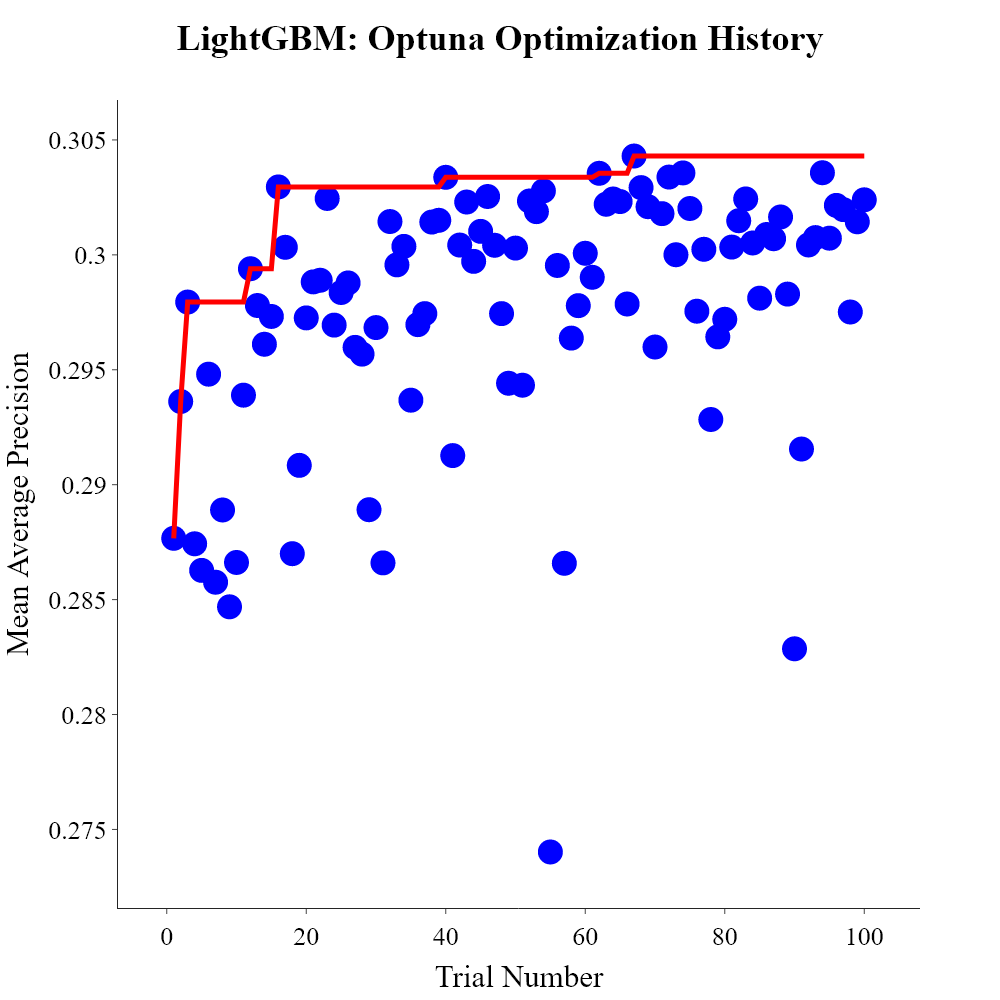

In [44]:
scores = study.trials_dataframe()
fig = go.Figure()
scores.index = scores.index + 1
fig.add_trace(go.Scatter(x=scores.index, y=scores["value"], mode="markers", name="Trial Score", marker=dict(size=25, color="blue"), showlegend=False))
maximum_scores = []
for i in range(len(scores)):
    maximum_scores.append(scores.loc[:i+1, "value"].max())
fig.add_trace(go.Scatter(x=scores.index, y=maximum_scores, mode="lines", name="Minimum Score", line=dict(color="red", width=5), showlegend=False))
fig.update_layout(template="simple_white", width=1000, height=1000, title="<b>LightGBM: Optuna Optimization History<b>", title_x=0.5, xaxis_title="Trial Number", yaxis_title=compare_metric_name, font=dict(family="Times New Roman",size=26,color="Black"), showlegend=False)
fig.show("png")

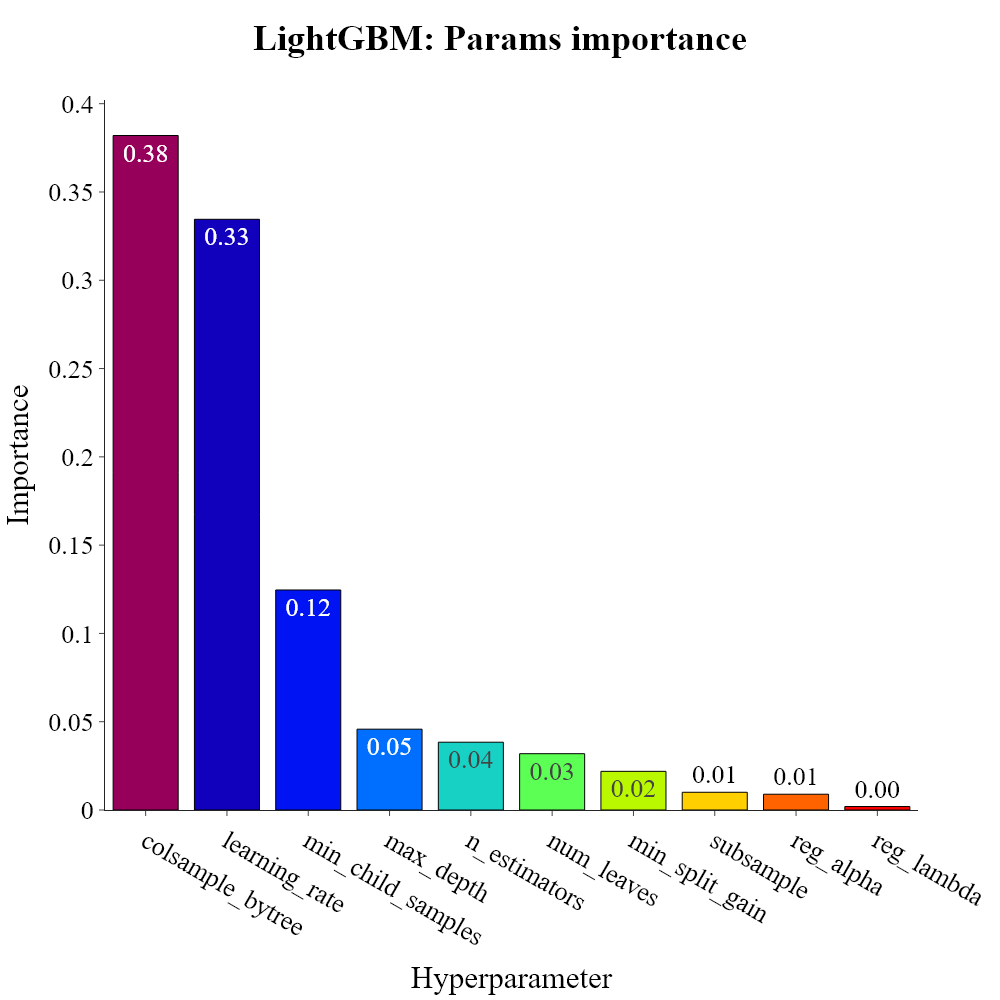

In [45]:
importances = optuna.importance.get_param_importances(study)
fig = go.Figure()
n_colors = len(importances)
colors = px.colors.sample_colorscale("rainbow", [n/(n_colors -1) for n in range(n_colors)])
fig.add_trace(go.Bar(x=list(importances.keys()), y=list(importances.values()), marker=dict(color=colors, line=dict(color='black', width=1), line_color='black'), text=[f"{v:.2f}" for v in list(importances.values())], textposition="auto"))
fig.update_layout(template="simple_white", width=1000, height=1000, title="<b>LightGBM: Params importance<b>", title_x=0.5, xaxis_title="Hyperparameter", yaxis_title=f"Importance", font=dict(family="Times New Roman",size=26,color="Black"), showlegend=False)
fig.show("png")

In [46]:
model = LGBMClassifier(**lgbm_best_params)
train_scores, validation_scores = perform_cv(train_data[independent_features], train_data[target_feature], model, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED), metric_name=compare_metric_name)
print(f"Train {compare_metric_name}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {compare_metric_name}: {np.mean(validation_scores):.4f} +- {np.std(validation_scores):.4f}")

Train Mean Average Precision: 0.5280 +- 0.0003
Validation Mean Average Precision: 0.3310 +- 0.0014


### XGBoost

In [ ]:
model = XGBClassifier()
cv = RandomSearchCV(
    algorithm=model,
    metric=compare_metric_name,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    n_trials=N_TRIALS,
    seed=SEED
)

constant_params_grid = {
    "objective": ("constant", ["multi:softprob"]),
    "num_class": ("constant", [num_classes]),
    "eval_metric": ("constant", ["mlogloss"]),
    "seed": ("constant", [SEED]),
    "verbosity": ("constant", [0]),
    "n_jobs": ("constant", [-1]),
    "tree_method": ("constant", ["hist"]),
    "enable_categorical": ("constant", [True]),
    "scale_pos_weight": ("constant", [1.0]),
    "early_stopping_rounds": ("constant", [100]),
}
tunable_params_grid = {
    "n_estimators": ("int", [50, 1000]),
    "learning_rate": ("float", [1e-3, 0.3]),
    "max_depth": ("int", [3, 30]),
    "min_child_weight": ("int", [1, 100]),
    "subsample": ("float", [0.3, 1.0]),
    "colsample_bytree": ("float", [0.3, 1.0]),
    "gamma": ("float", [1e-3, 10.0]),
    "reg_alpha": ("float", [1e-3, 10]),
    "reg_lambda": ("float", [1e-3, 10])
}
params_grid = {**constant_params_grid, **tunable_params_grid}

study = cv.tune(
    train_data[independent_features],
    train_data[target_feature],
    params_grid
)
xgb_best_params = study.best_trial.params
constant_params = {k: v[1][0] for k, v in constant_params_grid.items()}
xgb_best_params = {**constant_params, **xgb_best_params}
print(xgb_best_params)

[I 2025-06-10 11:24:02,935] A new study created in memory with name: Optuna tuning
[I 2025-06-10 11:24:29,559] Trial 0 finished with value: 0.2965999999999999 and parameters: {'n_estimators': 330, 'learning_rate': 0.0206218550445619, 'max_depth': 8, 'min_child_weight': 7, 'subsample': 0.7737830722497602, 'colsample_bytree': 0.6611562428979949, 'gamma': 0.3548816830746042, 'reg_alpha': 0.200637253882253, 'reg_lambda': 0.0014330180633302001}. Best is trial 0 with value: 0.2965999999999999.
[I 2025-06-10 11:24:36,776] Trial 1 finished with value: 0.29761166666666666 and parameters: {'n_estimators': 390, 'learning_rate': 0.2200756140551977, 'max_depth': 4, 'min_child_weight': 87, 'subsample': 0.8626563515456908, 'colsample_bytree': 0.31907247004783607, 'gamma': 0.407075028414586, 'reg_alpha': 0.16106659384496572, 'reg_lambda': 0.24550085725408072}. Best is trial 1 with value: 0.29761166666666666.
[I 2025-06-10 11:25:37,498] Trial 2 finished with value: 0.297855 and parameters: {'n_estimato

{'objective': 'multi:softprob', 'num_class': 7, 'eval_metric': 'mlogloss', 'seed': 17, 'verbosity': 0, 'n_jobs': -1, 'tree_method': 'hist', 'enable_categorical': True, 'scale_pos_weight': 1.0, 'early_stopping_rounds': 100, 'n_estimators': 770, 'learning_rate': 0.011168758192832123, 'max_depth': 12, 'min_child_weight': 31, 'subsample': 0.865609541137457, 'colsample_bytree': 0.315650895993391, 'gamma': 0.1383259460932209, 'reg_alpha': 2.20674302671626, 'reg_lambda': 0.13203245892716126}


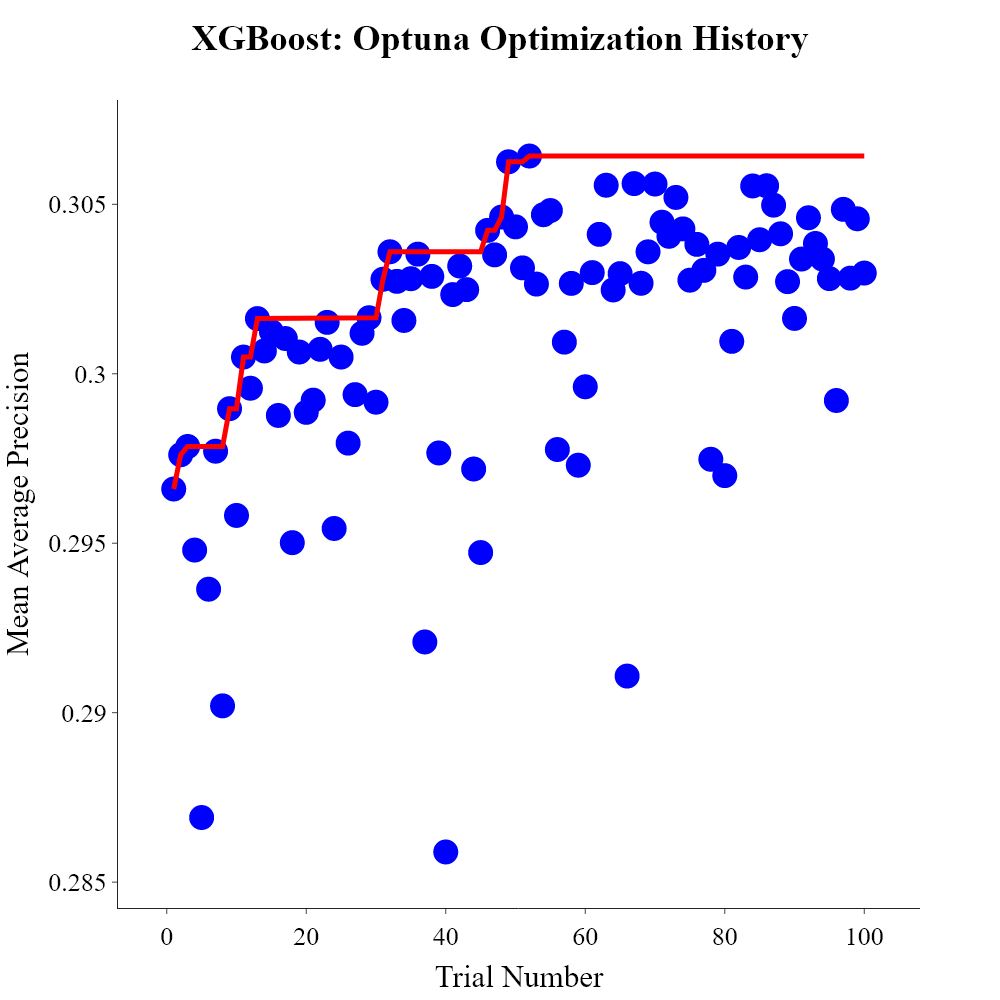

In [48]:
scores = study.trials_dataframe()
fig = go.Figure()
scores.index = scores.index + 1
fig.add_trace(go.Scatter(x=scores.index, y=scores["value"], mode="markers", name="Trial Score", marker=dict(size=25, color="blue"), showlegend=False))
maximum_scores = []
for i in range(len(scores)):
    maximum_scores.append(scores.loc[:i+1, "value"].max())
fig.add_trace(go.Scatter(x=scores.index, y=maximum_scores, mode="lines", name="Minimum Score", line=dict(color="red", width=5), showlegend=False))
fig.update_layout(template="simple_white", width=1000, height=1000, title="<b>XGBoost: Optuna Optimization History<b>", title_x=0.5, xaxis_title="Trial Number", yaxis_title=compare_metric_name, font=dict(family="Times New Roman",size=26,color="Black"), showlegend=False)
fig.show("png")

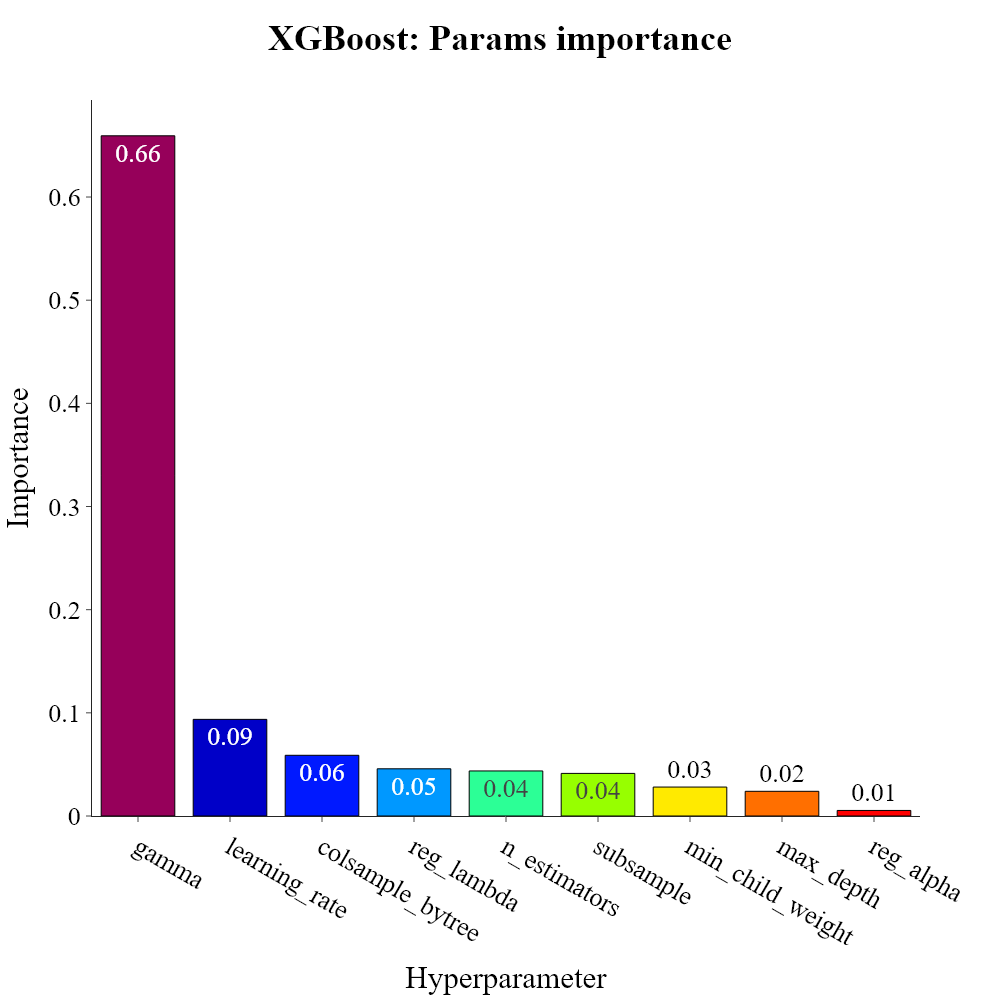

In [49]:
importances = optuna.importance.get_param_importances(study)
fig = go.Figure()
n_colors = len(importances)
colors = px.colors.sample_colorscale("rainbow", [n/(n_colors -1) for n in range(n_colors)])
fig.add_trace(go.Bar(x=list(importances.keys()), y=list(importances.values()), marker=dict(color=colors, line=dict(color='black', width=1), line_color='black'), text=[f"{v:.2f}" for v in list(importances.values())], textposition="auto"))
fig.update_layout(template="simple_white", width=1000, height=1000, title="<b>XGBoost: Params importance<b>", title_x=0.5, xaxis_title="Hyperparameter", yaxis_title=f"Importance", font=dict(family="Times New Roman",size=26,color="Black"), showlegend=False)
fig.show("png")

In [50]:
model = XGBClassifier(**xgb_best_params)
train_scores, validation_scores = perform_cv(train_data[independent_features], train_data[target_feature], model, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED), metric_name=compare_metric_name)
print(f"Train {compare_metric_name}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {compare_metric_name}: {np.mean(validation_scores):.4f} +- {np.std(validation_scores):.4f}")

Train Mean Average Precision: 0.5611 +- 0.0011
Validation Mean Average Precision: 0.3353 +- 0.0010


### Histogram-based Gradient Boosting

In [51]:
model = HistGradientBoostingClassifier()
cv = RandomSearchCV(
    algorithm=model,
    metric=compare_metric_name,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    n_trials=N_TRIALS,
    seed=SEED
)

constant_params_grid = {
    "random_state": ("constant", [SEED]),
    "loss": ("constant", ["log_loss"]),
    "categorical_features": ("constant", [categorical_features]),
    "class_weight": ("constant", ["balanced"]),
    "early_stopping": ("constant", [True]),
}
tunable_params_grid = {
    "learning_rate": ("float", [1e-3, 0.3]),
    "max_iter": ("int", [50, 1000]),
    "max_leaf_nodes": ("int", [10, 512]),
    "max_depth": ("int", [3, 30]),
    "max_features": ("float", [0.3, 1.0]),
    "min_samples_leaf": ("int", [20, 300]),
    "l2_regularization": ("float", [1e-3, 30]),
    "max_bins": ("int", [64, 255]),
    "n_iter_no_change": ("int", [10, 50]),
    "validation_fraction": ("float", [0.1, 0.3]),
}
params_grid = {**constant_params_grid, **tunable_params_grid}

study = cv.tune(
    train_data[independent_features],
    train_data[target_feature],
    params_grid
)
hgbm_best_params = study.best_trial.params
constant_params = {k: v[1][0] for k, v in constant_params_grid.items()}
hgbm_best_params = {**constant_params, **hgbm_best_params}
print(hgbm_best_params)

[I 2025-06-10 14:20:39,443] A new study created in memory with name: Optuna tuning
[I 2025-06-10 14:21:33,675] Trial 0 finished with value: 0.28298333333333336 and parameters: {'learning_rate': 0.005369340441799301, 'max_iter': 554, 'max_leaf_nodes': 106, 'max_depth': 4, 'max_features': 0.7737830722497602, 'min_samples_leaf': 204, 'l2_regularization': 0.7149214935861121, 'max_bins': 174, 'n_iter_no_change': 11, 'validation_fraction': 0.1481564202055472}. Best is trial 0 with value: 0.28298333333333336.
[I 2025-06-10 14:22:13,941] Trial 1 finished with value: 0.28398500000000004 and parameters: {'learning_rate': 0.2200756140551977, 'max_iter': 107, 'max_leaf_nodes': 444, 'max_depth': 27, 'max_features': 0.31907247004783607, 'min_samples_leaf': 203, 'l2_regularization': 0.2952961466414886, 'max_bins': 178, 'n_iter_no_change': 29, 'validation_fraction': 0.13646449311033657}. Best is trial 1 with value: 0.28398500000000004.
[I 2025-06-10 14:24:38,233] Trial 2 finished with value: 0.29035 a

{'random_state': 17, 'loss': 'log_loss', 'categorical_features': ['Soil Type', 'Crop Type', 'Crop_Soil', 'temp_bin', 'humidity_bin', 'moisture_bin'], 'class_weight': 'balanced', 'early_stopping': True, 'learning_rate': 0.001731206920185087, 'max_iter': 937, 'max_leaf_nodes': 238, 'max_depth': 12, 'max_features': 0.358653057124365, 'min_samples_leaf': 193, 'l2_regularization': 0.9134319885170242, 'max_bins': 186, 'n_iter_no_change': 37, 'validation_fraction': 0.13020796770226176}


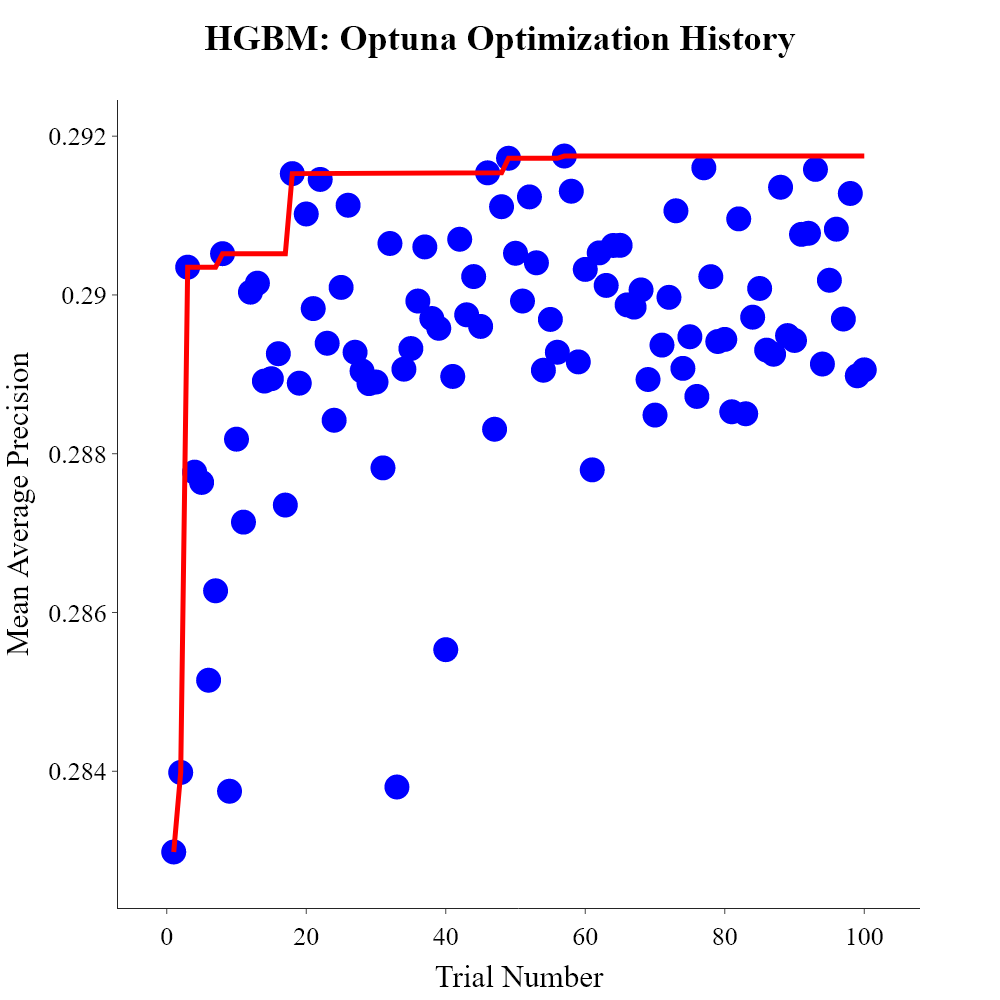

In [52]:
scores = study.trials_dataframe()
fig = go.Figure()
scores.index = scores.index + 1
fig.add_trace(go.Scatter(x=scores.index, y=scores["value"], mode="markers", name="Trial Score", marker=dict(size=25, color="blue"), showlegend=False))
maximum_scores = []
for i in range(len(scores)):
    maximum_scores.append(scores.loc[:i+1, "value"].max())
fig.add_trace(go.Scatter(x=scores.index, y=maximum_scores, mode="lines", name="Minimum Score", line=dict(color="red", width=5), showlegend=False))
fig.update_layout(template="simple_white", width=1000, height=1000, title="<b>HGBM: Optuna Optimization History<b>", title_x=0.5, xaxis_title="Trial Number", yaxis_title=compare_metric_name, font=dict(family="Times New Roman",size=26,color="Black"), showlegend=False)
fig.show("png")

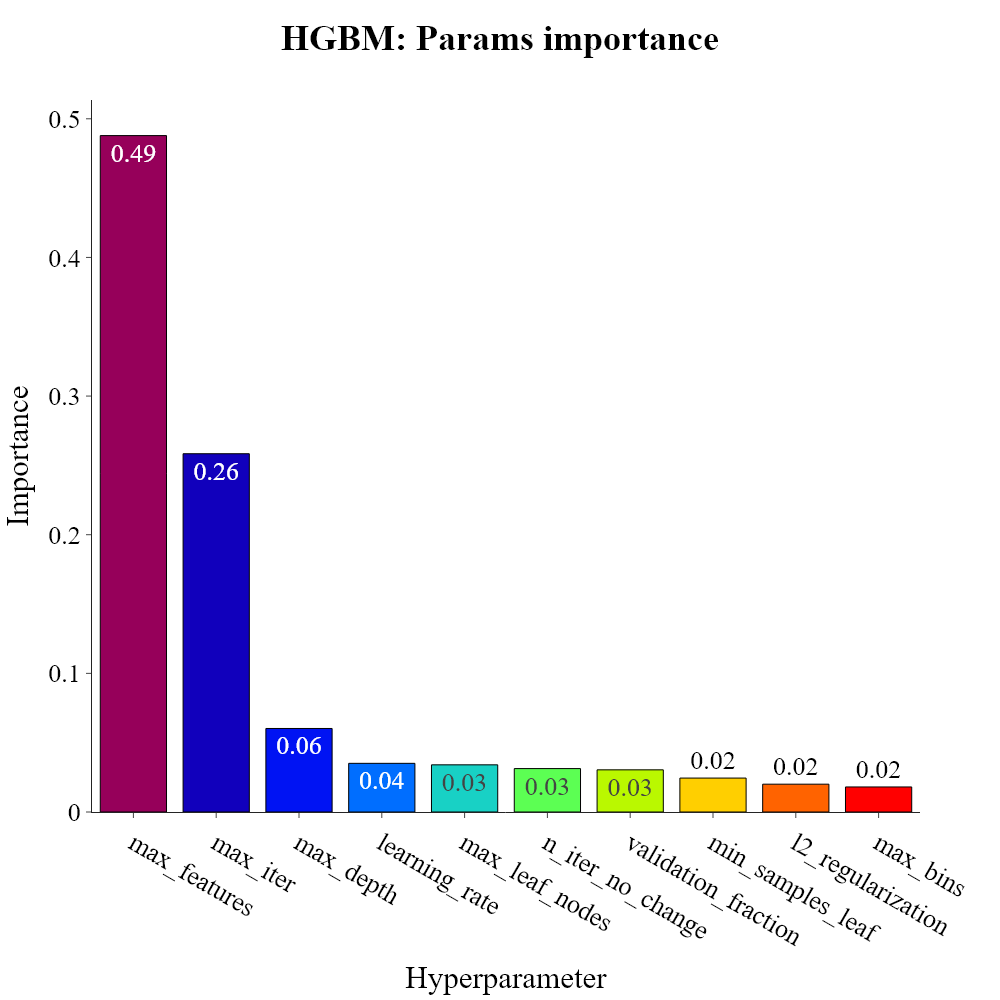

In [53]:
importances = optuna.importance.get_param_importances(study)
fig = go.Figure()
n_colors = len(importances)
colors = px.colors.sample_colorscale("rainbow", [n/(n_colors -1) for n in range(n_colors)])
fig.add_trace(go.Bar(x=list(importances.keys()), y=list(importances.values()), marker=dict(color=colors, line=dict(color='black', width=1), line_color='black'), text=[f"{v:.2f}" for v in list(importances.values())], textposition="auto"))
fig.update_layout(template="simple_white", width=1000, height=1000, title="<b>HGBM: Params importance<b>", title_x=0.5, xaxis_title="Hyperparameter", yaxis_title=f"Importance", font=dict(family="Times New Roman",size=26,color="Black"), showlegend=False)
fig.show("png")

In [54]:
model = HistGradientBoostingClassifier(**hgbm_best_params)
train_scores, validation_scores = perform_cv(train_data[independent_features], train_data[target_feature], model, cv=KFold(n_splits=5, shuffle=True, random_state=SEED), metric_name=compare_metric_name)
print(f"Train {compare_metric_name}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {compare_metric_name}: {np.mean(validation_scores):.4f} +- {np.std(validation_scores):.4f}")

Train Mean Average Precision: 0.4093 +- 0.0004
Validation Mean Average Precision: 0.3085 +- 0.0011


### Catboost

In [55]:
model = CatBoostClassifier()
cv = RandomSearchCV(
    algorithm=model,
    metric=compare_metric_name,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    n_trials=N_TRIALS,
    seed=SEED
)

constant_params_grid = {
    "random_state": ("constant", [SEED]),
    "verbose": ("constant", [0]),
    "cat_features": ("constant", [categorical_features]),
    "task_type": ("constant", ["GPU"]),
    "loss_function": ("constant", ["MultiClass"]),
    "eval_metric": ("constant", ["MultiClass"]),
    "early_stopping_rounds": ("constant", [100]),
}
tunable_params_grid = {
    "iterations": ("int", [50, 1000]),
    "learning_rate": ("float", [1e-3, 0.3]),
    "depth": ("int", [3, 10]),
    "l2_leaf_reg": ("float", [1e-3, 30]),
    "random_strength": ("float", [1e-3, 10.0]),
    "bagging_temperature": ("float", [0.3, 1.0]),
    "border_count": ("int", [32, 255]),
    "min_data_in_leaf": ("int", [1, 300]),
}
params_grid = {**constant_params_grid, **tunable_params_grid}

study = cv.tune(
    train_data[independent_features],
    train_data[target_feature],
    params_grid
)
catboost_best_params = study.best_trial.params
constant_params = {k: v[1][0] for k, v in constant_params_grid.items()}
catboost_best_params = {**constant_params, **catboost_best_params}
print(catboost_best_params)

[I 2025-06-10 21:26:47,262] A new study created in memory with name: Optuna tuning
[I 2025-06-10 21:27:01,864] Trial 0 finished with value: 0.28904166666666664 and parameters: {'iterations': 330, 'learning_rate': 0.0206218550445619, 'depth': 4, 'l2_leaf_reg': 0.00201371561093265, 'random_strength': 1.4058592411732862, 'bagging_temperature': 0.6611562428979949, 'border_count': 174, 'min_data_in_leaf': 173}. Best is trial 0 with value: 0.28904166666666664.
[I 2025-06-10 21:27:32,478] Trial 1 finished with value: 0.28561999999999993 and parameters: {'iterations': 87, 'learning_rate': 0.007697464327022002, 'depth': 10, 'l2_leaf_reg': 0.0018570658959306857, 'random_strength': 2.8586988975615437, 'bagging_temperature': 0.8626563515456908, 'border_count': 43, 'min_data_in_leaf': 196}. Best is trial 0 with value: 0.28904166666666664.
[I 2025-06-10 21:28:08,127] Trial 2 finished with value: 0.29498499999999994 and parameters: {'iterations': 574, 'learning_rate': 0.03020736057097153, 'depth': 6,

{'random_state': 17, 'verbose': 0, 'cat_features': ['Soil Type', 'Crop Type', 'Crop_Soil', 'temp_bin', 'humidity_bin', 'moisture_bin'], 'task_type': 'GPU', 'loss_function': 'MultiClass', 'eval_metric': 'MultiClass', 'early_stopping_rounds': 100, 'iterations': 783, 'learning_rate': 0.18691761695113285, 'depth': 3, 'l2_leaf_reg': 0.008948094551902855, 'random_strength': 0.002121314819908465, 'bagging_temperature': 0.4833675233162264, 'border_count': 141, 'min_data_in_leaf': 27}


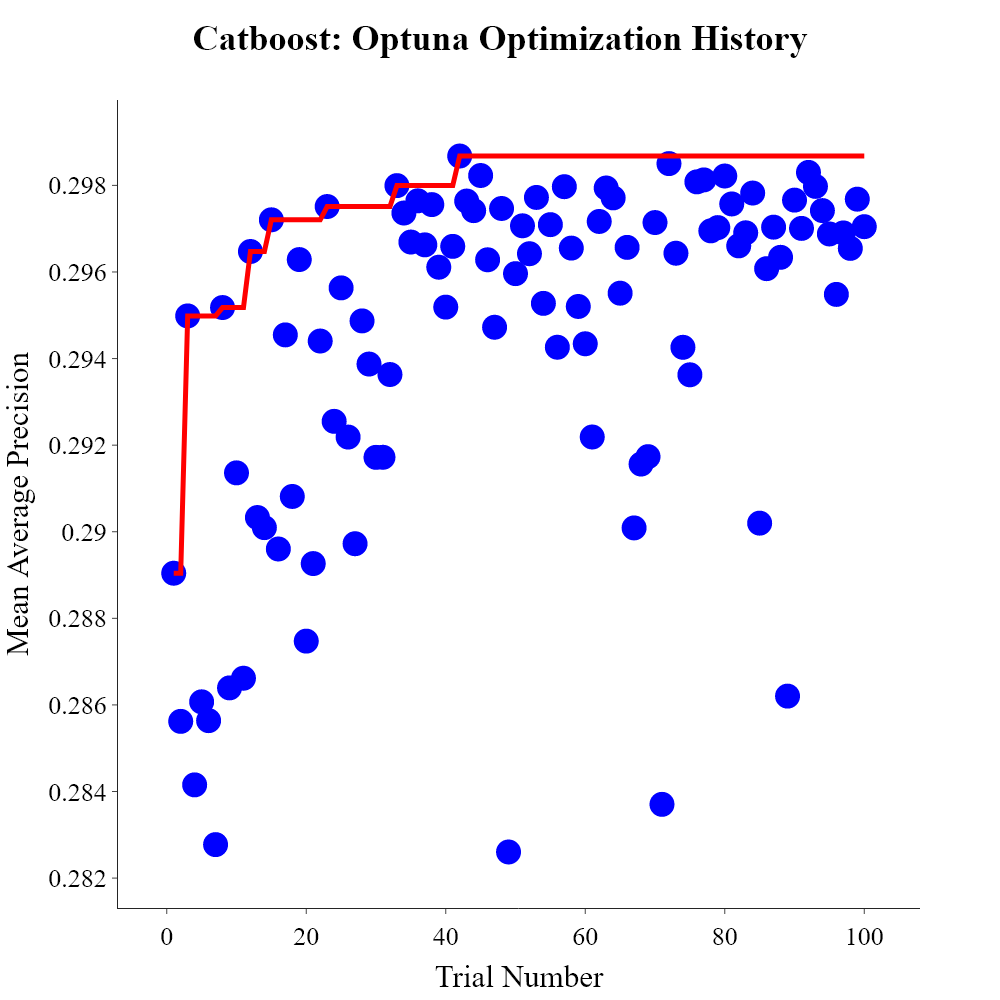

In [56]:
scores = study.trials_dataframe()
fig = go.Figure()
scores.index = scores.index + 1
fig.add_trace(go.Scatter(x=scores.index, y=scores["value"], mode="markers", name="Trial Score", marker=dict(size=25, color="blue"), showlegend=False))
maximum_scores = []
for i in range(len(scores)):
    maximum_scores.append(scores.loc[:i+1, "value"].max())
fig.add_trace(go.Scatter(x=scores.index, y=maximum_scores, mode="lines", name="Minimum Score", line=dict(color="red", width=5), showlegend=False))
fig.update_layout(template="simple_white", width=1000, height=1000, title="<b>Catboost: Optuna Optimization History<b>", title_x=0.5, xaxis_title="Trial Number", yaxis_title=compare_metric_name, font=dict(family="Times New Roman",size=26,color="Black"), showlegend=False)
fig.show("png")

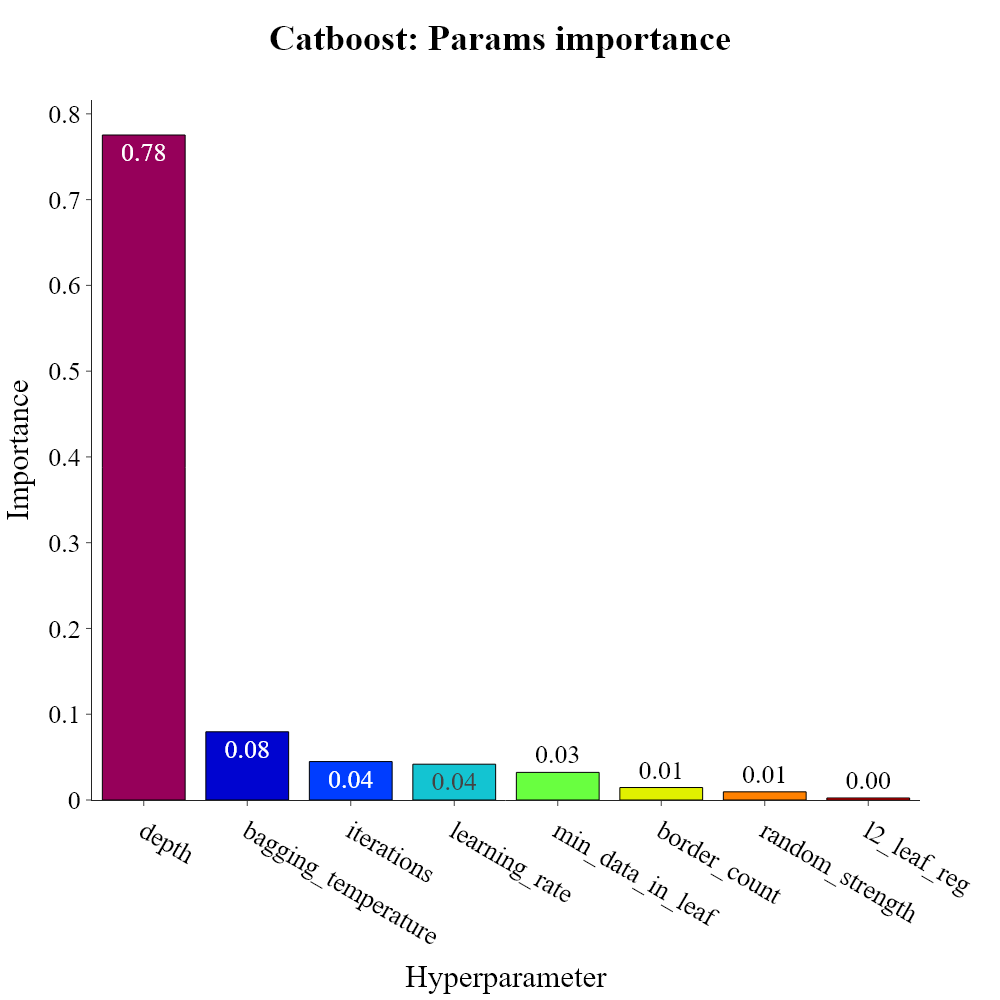

In [57]:
importances = optuna.importance.get_param_importances(study)
fig = go.Figure()
n_colors = len(importances)
colors = px.colors.sample_colorscale("rainbow", [n/(n_colors -1) for n in range(n_colors)])
fig.add_trace(go.Bar(x=list(importances.keys()), y=list(importances.values()), marker=dict(color=colors, line=dict(color='black', width=1), line_color='black'), text=[f"{v:.2f}" for v in list(importances.values())], textposition="auto"))
fig.update_layout(template="simple_white", width=1000, height=1000, title="<b>Catboost: Params importance<b>", title_x=0.5, xaxis_title="Hyperparameter", yaxis_title=f"Importance", font=dict(family="Times New Roman",size=26,color="Black"), showlegend=False)
fig.show("png")

In [58]:
model = CatBoostClassifier(**catboost_best_params)
train_scores, validation_scores = perform_cv(train_data[independent_features], train_data[target_feature], model, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED), metric_name=compare_metric_name)
print(f"Train {compare_metric_name}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {compare_metric_name}: {np.mean(validation_scores):.4f} +- {np.std(validation_scores):.4f}")

Train Mean Average Precision: 0.3357 +- 0.0003
Validation Mean Average Precision: 0.3205 +- 0.0009


## Ensemble weight

In [59]:
# estimators = [
#     LGBMClassifier(**lgbm_best_params),
#     XGBClassifier(**xgb_best_params),
#     HistGradientBoostingClassifier(**hgbm_best_params),
#     CatBoostClassifier(**catboost_best_params)
# ]
estimators = [
    LGBMClassifier(**lgbm_best_params),
    XGBClassifier(**xgb_best_params),
    HistGradientBoostingClassifier(random_state=SEED, categorical_features=categorical_features),
    CatBoostClassifier(random_state=SEED, verbose=0, cat_features=categorical_features, task_type='GPU', loss_function='MultiClass', eval_metric='MultiClass', early_stopping_rounds=100)
]

ensemble_weights_tuner = EnsembleWeightTunerCV(
    estimators = estimators,
    metric=compare_metric_name,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    n_trials=N_TRIALS*2,
    seed=SEED
)
ensemble_weights_tuner.tune(train_data[independent_features], train_data[target_feature])
best_weights = ensemble_weights_tuner.best_weights
for i, estimator in enumerate(ensemble_weights_tuner.estimators):
    print(f"Estimator {i}: {estimator.__class__.__name__}, Weight: {best_weights[i]:.4f}")

[I 2025-06-10 23:27:06,801] A new study created in memory with name: Weight Tuning Study
[I 2025-06-10 23:27:08,137] Trial 0 finished with value: 0.33487177777777777 and parameters: {'w0': 0.2987717026333675, 'w1': 0.5299750204931882, 'w2': 0.19769037120854496, 'w3': 0.07654235102746554}. Best is trial 0 with value: 0.33487177777777777.
[I 2025-06-10 23:27:09,426] Trial 1 finished with value: 0.3336262222222222 and parameters: {'w0': 0.7812457507999151, 'w1': 0.6532068513403384, 'w2': 0.6347704781227631, 'w3': 0.5740908358779733}. Best is trial 0 with value: 0.33487177777777777.
[I 2025-06-10 23:27:10,683] Trial 2 finished with value: 0.325518 and parameters: {'w0': 0.04828165786508915, 'w1': 0.3606573323938779, 'w2': 0.9367695230820394, 'w3': 0.06884378670907763}. Best is trial 0 with value: 0.33487177777777777.
[I 2025-06-10 23:27:12,152] Trial 3 finished with value: 0.3353982222222221 and parameters: {'w0': 0.8567612614752868, 'w1': 0.8697447156250696, 'w2': 0.06016979230804462, 'w3

Estimator 0: LGBMClassifier, Weight: 0.3459
Estimator 1: XGBClassifier, Weight: 0.5460
Estimator 2: HistGradientBoostingClassifier, Weight: 0.0065
Estimator 3: CatBoostClassifier, Weight: 0.1016


In [60]:
class EnsembleModel(BaseEstimator, ClassifierMixin):
    def __init__(self, estimators, weights):
        self.estimators = estimators
        self.weights = weights

    def fit(self, X_train: pd.DataFrame, y_train: pd.Series, eval_set: tuple[pd.DataFrame, pd.Series], verbose: bool = False, sample_weight: pd.Series = None):
        for estimator in self.estimators:
            sig = signature(estimator.fit)
            fit_params = {}
            if "eval_set" in sig.parameters:
                fit_params["eval_set"] = eval_set
            if "verbose" in sig.parameters:
                fit_params["verbose"] = False
            if "X_val" and "y_val" in sig.parameters:
                fit_params["X_val"] = eval_set[0][0]
                fit_params["y_val"] = eval_set[0][1]
            #Można spróbować dodać sample_weight do fit_params i sprawdzić czy będzie lepiej
            # if "sample_weight" in sig.parameters:
            #     fit_params["sample_weight"] = sample_weight
            estimator.fit(X_train, y_train, **fit_params)
        return self

    def predict(self, X):
        pred_probs = np.array([estimator.predict_proba(X) for estimator in self.estimators])
        weighted_probabilities = sum(w * p for w, p in zip(self.weights, pred_probs))
        predictions = np.round(weighted_probabilities).astype(int)
        return predictions

    def predict_proba(self, X):
        pred_probs = np.array([estimator.predict_proba(X) for estimator in self.estimators])
        weighted_probabilities = sum(w * p for w, p in zip(self.weights, pred_probs))
        return weighted_probabilities

final_model = EnsembleModel(estimators=ensemble_weights_tuner.estimators, weights=ensemble_weights_tuner.best_weights)
train_scores, validation_scores = perform_cv(train_data[independent_features], train_data[target_feature], final_model, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED), metric_name=compare_metric_name)
print(f"Train {compare_metric_name}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {compare_metric_name}: {np.mean(validation_scores):.4f} +- {np.std(validation_scores):.4f}")

Train Mean Average Precision: 0.5431 +- 0.0007
Validation Mean Average Precision: 0.3367 +- 0.0011


# Cutoff tuning

In [61]:
class CutoffTunerCV:
    def __init__(
        self,
        algorithm: object,
        metric: str,
        cv: sklearn.model_selection.BaseCrossValidator = KFold(n_splits=5, shuffle=True, random_state=17),
        n_trials: int = 50,
        seed: int = 17,
    ):
        self.algorithm = algorithm
        self.cv = cv
        self.n_trials = n_trials
        self.seed = seed

        if metric not in METRICS:
            raise ValueError(f"Unsupported metric: {metric}. Supported metrics are: {', '.join(METRICS.keys())}")
        self.eval_metric = METRICS[metric][0]
        self.direction = METRICS[metric][2]

    def tune(self, X: np.ndarray, y: np.ndarray) -> optuna.Study:
        """
        Perform cross-validation and tune cutoffs using Optuna.

        Args:
            X (np.ndarray): Feature matrix.
            y (np.ndarray): Target vector.
        
        Returns:
            optuna.Study: Optuna study object containing the results of the optimization.
        """
        y_true, y_proba = self.perform_cv(X, y)
        study = self.create_study()
        study.optimize(
            lambda trial: self.objective(trial, y_true, y_proba),
            n_trials=self.n_trials,
        )
        self.best_cutoffs = np.array([study.best_params[f"cutoff_{i}"] for i in range(y_proba.shape[1])])
        self.best_cutoffs = self.best_cutoffs / self.best_cutoffs.sum() # Normalize to sum=1
        return study
    
    def create_study(self) -> optuna.study.Study:
        """
        Create an Optuna study for tuning cutoffs.
        
        Returns:
            optuna.study.Study: Optuna study object.
        """
        sampler = optuna.samplers.TPESampler(seed=self.seed)
        return optuna.create_study(
            direction=self.direction,
            sampler=sampler,
            study_name="Optuna cutoff tuning"
        )
    
    def objective(self, trial, y_true: np.ndarray, y_proba: np.ndarray) -> float:
        """
        Objective function for Optuna to optimize cutoffs.
        
        Args:
            trial (optuna.Trial): Optuna trial object.
            y_true (np.ndarray): True labels.
            y_proba (np.ndarray): Predicted probabilities.
        
        Returns:
            float: Evaluated metric score.
        """
        n_classes = y_proba.shape[1]
        cutoffs = np.array([trial.suggest_float(f"cutoff_{i}", 0.01, 0.99) for i in range(n_classes)])
        cutoffs = cutoffs / cutoffs.sum()  # Normalize to sum=1
        y_pred = np.argmax(y_proba / cutoffs, axis=1)
        return self.eval_metric(y_true, y_pred)
    
    def perform_cv(self, X: pd.DataFrame, y: pd.Series) -> tuple[np.ndarray, np.ndarray]:
        """
        Perform cross-validation and return true labels and predicted probabilities.
        
        Args:
            X (pd.DataFrame): Feature matrix.
            y (pd.Series): Target vector.
        
        Returns:
            tuple[np.ndarray, np.ndarray]: True labels and predicted probabilities.
        """
        y_valid_true = []
        y_valid_proba = []
        for train_idx, valid_idx in self.cv.split(X, y):
            X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
            y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
            sig = signature(self.algorithm.fit)
            fit_params = {}
            if "eval_set" in sig.parameters:
                fit_params["eval_set"] = [(X_valid, y_valid)]
            if "verbose" in sig.parameters:
                fit_params["verbose"] = False
            if "X_val" and "y_val" in sig.parameters:
                fit_params["X_val"] = X_valid
                fit_params["y_val"] = y_valid
            self.algorithm.fit(X_train, y_train, **fit_params)
            #Można spróbować dodać sample_weight do fit_params i sprawdzić czy będzie lepiej
            # if "sample_weight" in sig.parameters:
            #     fit_params["sample_weight"] = sample_weight
            y_valid_true.extend(y_valid.tolist())
            y_valid_proba.extend(self.algorithm.predict_proba(X_valid).tolist())
        return np.array(y_valid_true), np.array(y_valid_proba)

In [62]:
cutoff_tuner = CutoffTunerCV(
    algorithm=final_model,
    metric="F1 (Macro)",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    n_trials=N_TRIALS*10,
    seed=SEED,
)
cutoff_tuner.tune(train_data[independent_features], train_data[target_feature])
cutoffs = cutoff_tuner.best_cutoffs
print("Optimal cutoffs:")
for i, cutoff in enumerate(cutoffs):
    print(f"   - {id2label[i]}: {cutoff:.4f}")

[I 2025-06-11 00:21:03,920] A new study created in memory with name: Optuna cutoff tuning
[I 2025-06-11 00:21:04,015] Trial 0 finished with value: 0.03691642581061866 and parameters: {'cutoff_0': 0.2987717026333675, 'cutoff_1': 0.5299750204931882, 'cutoff_2': 0.19769037120854496, 'cutoff_3': 0.07654235102746554, 'cutoff_4': 0.7812457507999151, 'cutoff_5': 0.6532068513403384, 'cutoff_6': 0.6347704781227631}. Best is trial 0 with value: 0.03691642581061866.
[I 2025-06-11 00:21:04,099] Trial 1 finished with value: 0.052176871789285144 and parameters: {'cutoff_0': 0.5740908358779733, 'cutoff_1': 0.04828165786508915, 'cutoff_2': 0.3606573323938779, 'cutoff_3': 0.9367695230820394, 'cutoff_4': 0.06884378670907763, 'cutoff_5': 0.8567612614752868, 'cutoff_6': 0.8697447156250696}. Best is trial 1 with value: 0.052176871789285144.
[I 2025-06-11 00:21:04,199] Trial 2 finished with value: 0.0376659711943146 and parameters: {'cutoff_0': 0.06016979230804462, 'cutoff_1': 0.6493702431563417, 'cutoff_2'

Optimal cutoffs:
   - 10-26-26: 0.1455
   - 14-35-14: 0.1461
   - 17-17-17: 0.1466
   - 20-20: 0.1447
   - 28-28: 0.1437
   - DAP: 0.1403
   - Urea: 0.1330


In [ ]:
def predict_with_cutoffs(model: object, cutoffs: np.ndarray, X: pd.DataFrame) -> np.ndarray:
    """
    Predict using the model and apply cutoffs to the predicted probabilities.

    Below are some cases which might be run with the following code:
    y_proba = np.array([[0.1, 0.1, 0.3, 0.1, 0.1, 0.3]])
    cutoffs = np.array([0.1, 0.1, 0.2, 0.1, 0.1, 0.2])
    print(predict_with_cutoffs(None, None, None))

    Cases:
    1. Same probability for two classes, but different cutoffs. The class with the lower cutoff will be chosen.
    y_proba = np.array([[0.1, 0.1, 0.3, 0.1, 0.1, 0.3]])
    cutoffs = np.array([0.2, 0.2, 0.2, 0.2, 0.1, 0.1])
    The output will be:
    y_pred = np.array([5])

    2. All probabilities are lower than cutoffs. The class with the lowest cutoff will be chosen.
    y_proba = np.array([[0.16, 0.16, 0.16, 0.16, 0.16, 0.16]])
    cutoffs = np.array([0.16, 0.16, 0.16, 0.16, 0.16, 0.16])
    The output will be:
    y_pred = np.array([0])

    3. Same probability for two classes and same cutoffs. The class with the lower index will be chosen.
    y_proba = np.array([[0.1, 0.1, 0.3, 0.1, 0.1, 0.3]])
    cutoffs = np.array([0.1, 0.1, 0.2, 0.1, 0.1, 0.2])
    The output will be:
    y_pred = np.array([2])

    Args:
        model (object): Trained model.
        cutoffs (np.ndarray): Cutoffs for each class.
        X (pd.DataFrame): Feature matrix.
    
    Returns:
        np.ndarray: Predicted labels after applying cutoffs.
    """
    y_proba = model.predict_proba(X)
    y_pred = np.argmax(y_proba / cutoffs, axis=1)
    return y_pred

def perform_cv_with_cutoffs(X: pd.DataFrame, y: pd.Series, algorithm: object, cutoffs: np.ndarray, cv: sklearn.model_selection = KFold(n_splits=5, shuffle=True, random_state=SEED), metric_name: str = "RMSE") -> tuple[list[float], list[float]]:
    """
    Perform cross-validation with cutoffs and return train and validation scores.
    
    Args:
        X (pd.DataFrame): Feature matrix.
        y (pd.Series): Target vector.
        algorithm (object): Trained model.
        cutoffs (np.ndarray): Cutoffs for each class.
        cv (sklearn.model_selection.BaseCrossValidator): Cross-validation strategy.
        metric_name (str): Metric name for evaluation.
    
    Returns:
        tuple[list[float], list[float]]: Train and validation scores.
    """
    if metric_name not in METRICS:
        raise ValueError(f"Unsupported metric: {metric_name}. Supported metrics are: {', '.join(METRICS.keys())}")
    eval_metric = METRICS[metric_name][0]
    train_scores, validation_scores = [], []
    for train_idx, valid_idx in cv.split(X, y):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
        sig = signature(algorithm.fit)
        fit_params = {}
        if "eval_set" in sig.parameters:
            fit_params["eval_set"] = [(X_valid, y_valid)]
        if "verbose" in sig.parameters:
            fit_params["verbose"] = False
        if "X_val" and "y_val" in sig.parameters:
            fit_params["X_val"] = X_valid
            fit_params["y_val"] = y_valid
        algorithm.fit(X_train, y_train, **fit_params)
        y_train_pred = predict_with_cutoffs(algorithm, cutoffs, X_train)
        y_valid_pred = predict_with_cutoffs(algorithm, cutoffs, X_valid)
        train_scores.append(eval_metric(y_train, y_train_pred))
        validation_scores.append(eval_metric(y_valid, y_valid_pred))
    return train_scores, validation_scores

In [64]:
train_scores, validation_scores = perform_cv_with_cutoffs(
    X=train_data[independent_features],
    y=train_data[target_feature],
    algorithm=final_model,
    cutoffs=cutoff_tuner.best_cutoffs,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    metric_name="F1 (Macro)"
)
print(f"Train F1 (Macro): {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation F1 (Macro): {np.mean(validation_scores):.4f} +- {np.std(validation_scores):.4f}")

Train F1 (Macro): 0.3923 +- 0.0007
Validation F1 (Macro): 0.1989 +- 0.0010


In [65]:
train_data_temp, test_data_temp = train_test_split(train_data, test_size=0.2, random_state=SEED, shuffle=True, stratify=train_data[target_feature])
final_model.fit(train_data_temp[independent_features], train_data_temp[target_feature], eval_set=[(test_data_temp[independent_features], test_data_temp[target_feature])], verbose=False)

y_train = train_data_temp[target_feature]
y_train_pred = final_model.predict(train_data_temp[independent_features])
y_train_prob = final_model.predict_proba(train_data_temp[independent_features])
y_train_labels = y_train.map(id2label)

y_test = test_data_temp[target_feature]
y_test_pred = final_model.predict(test_data_temp[independent_features])
y_test_prob = final_model.predict_proba(test_data_temp[independent_features])
y_test_labels = y_test.map(id2label)

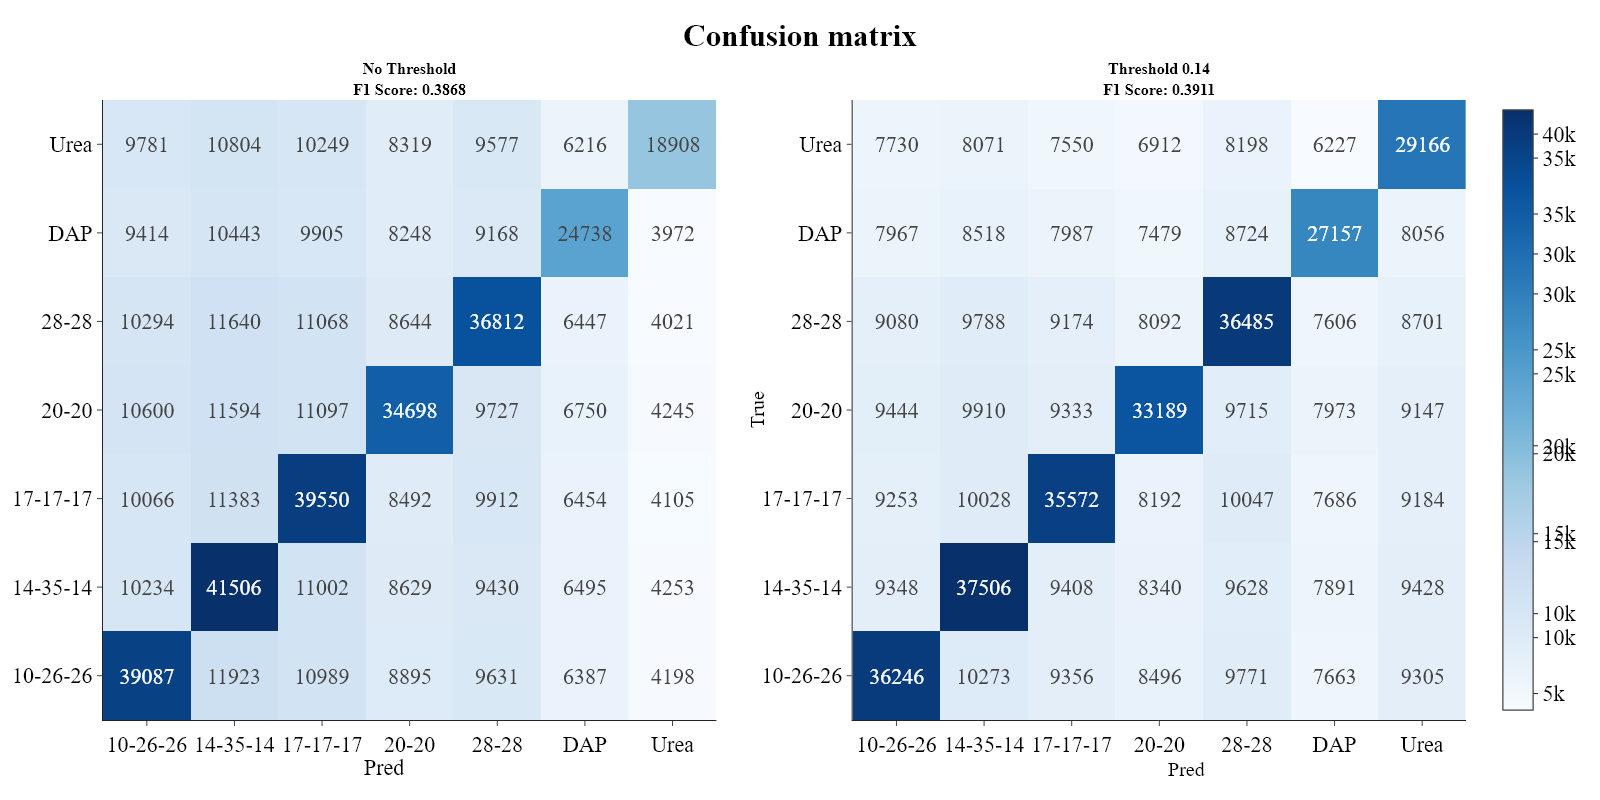

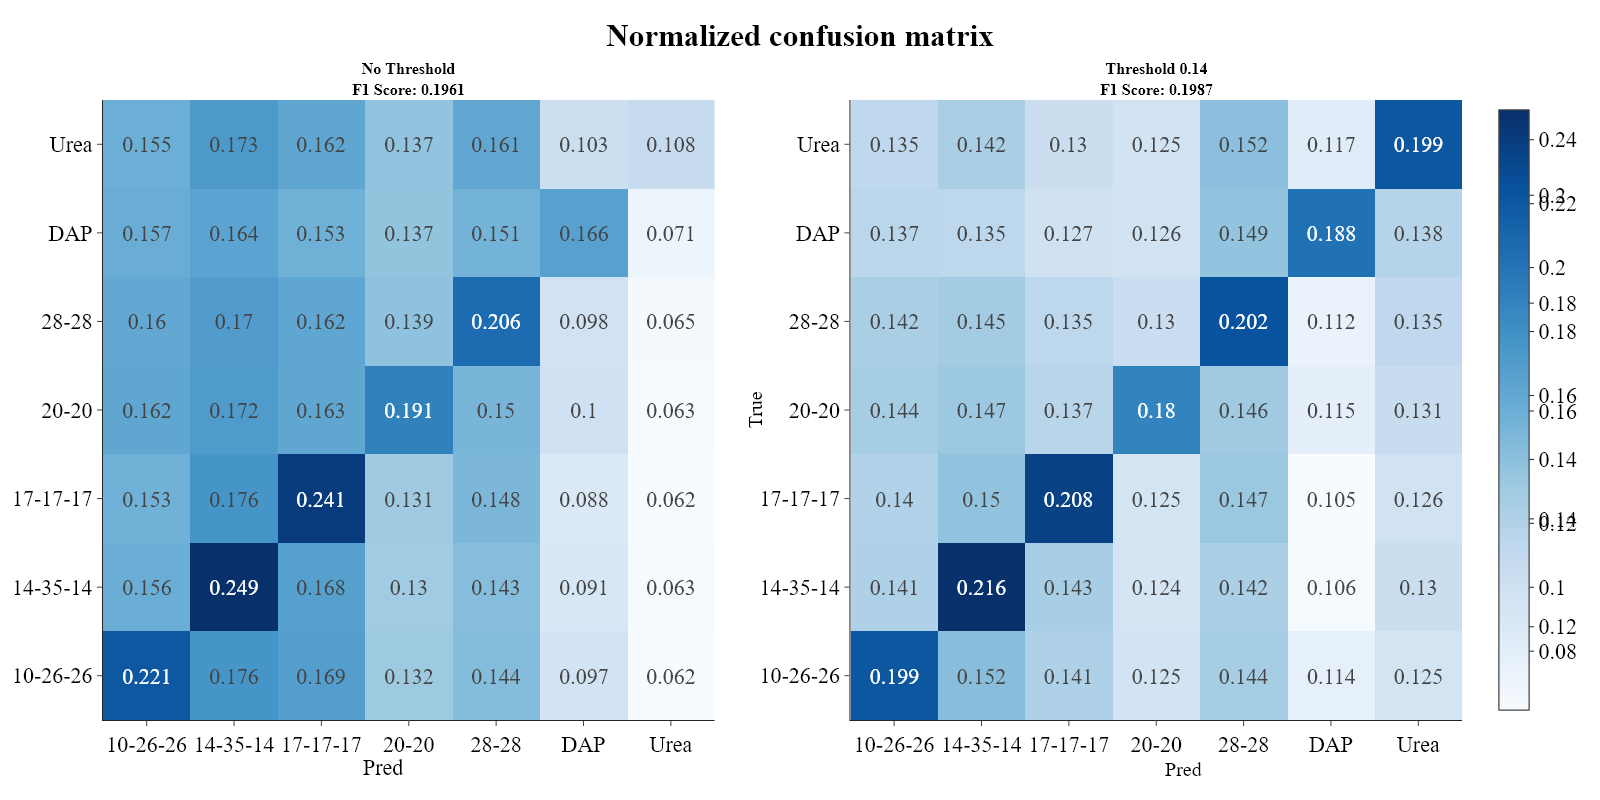

In [66]:
plots.subplot_multilabel_conf_matrix(y_train_labels, y_train_prob, cutoffs=cutoff_tuner.best_cutoffs, id2label=id2label, normalize=False)
plots.subplot_multilabel_conf_matrix(y_test_labels, y_test_prob, cutoffs=cutoff_tuner.best_cutoffs, id2label=id2label, normalize=True)

C:\Users\Kuba\AppData\Roaming\Python\Python311\site-packages\plotly\express\_core.py:1992: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



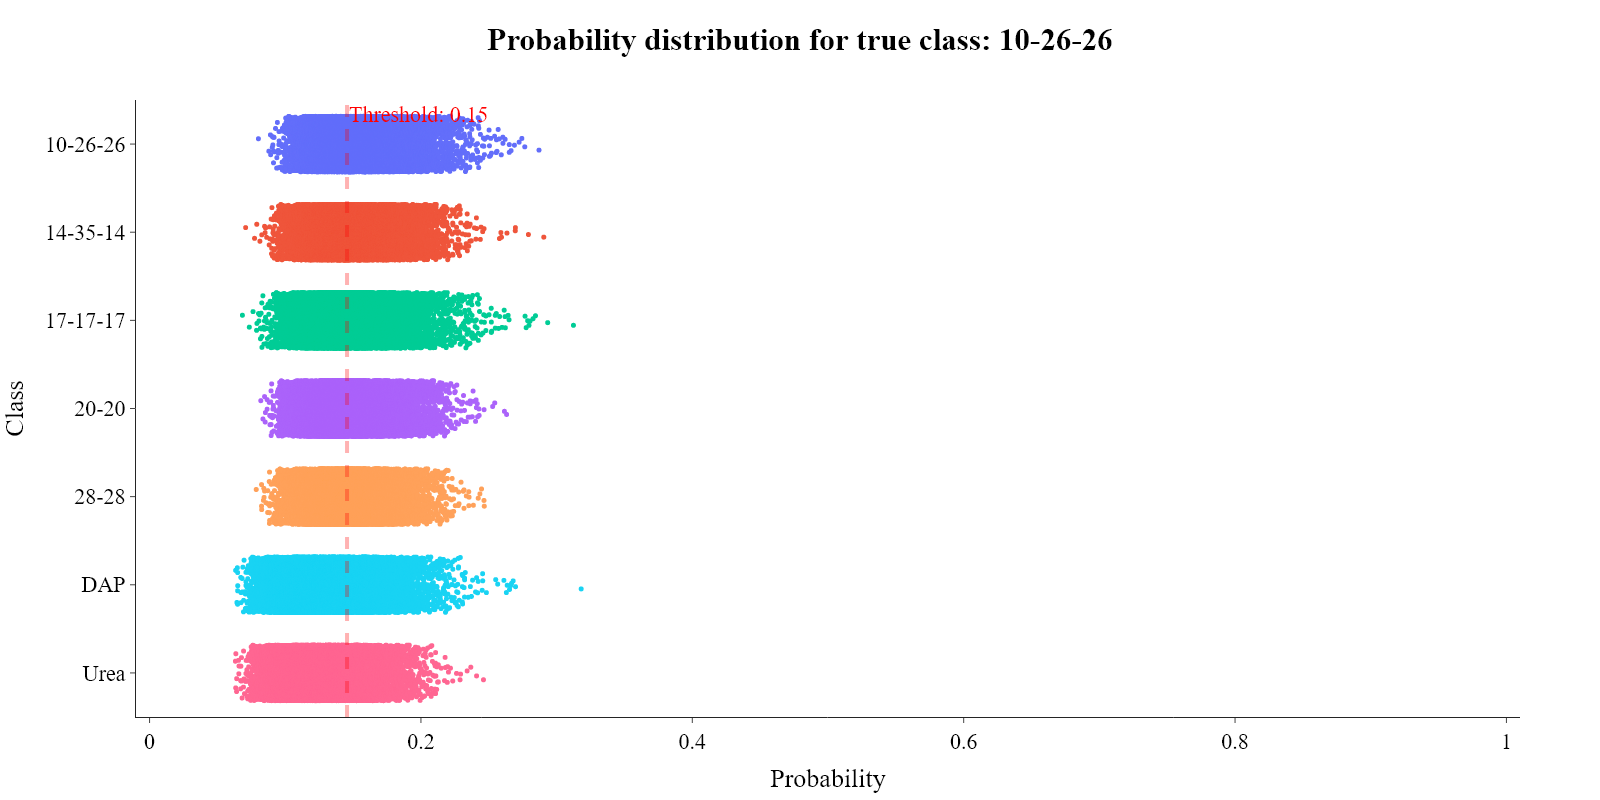

C:\Users\Kuba\AppData\Roaming\Python\Python311\site-packages\plotly\express\_core.py:1992: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



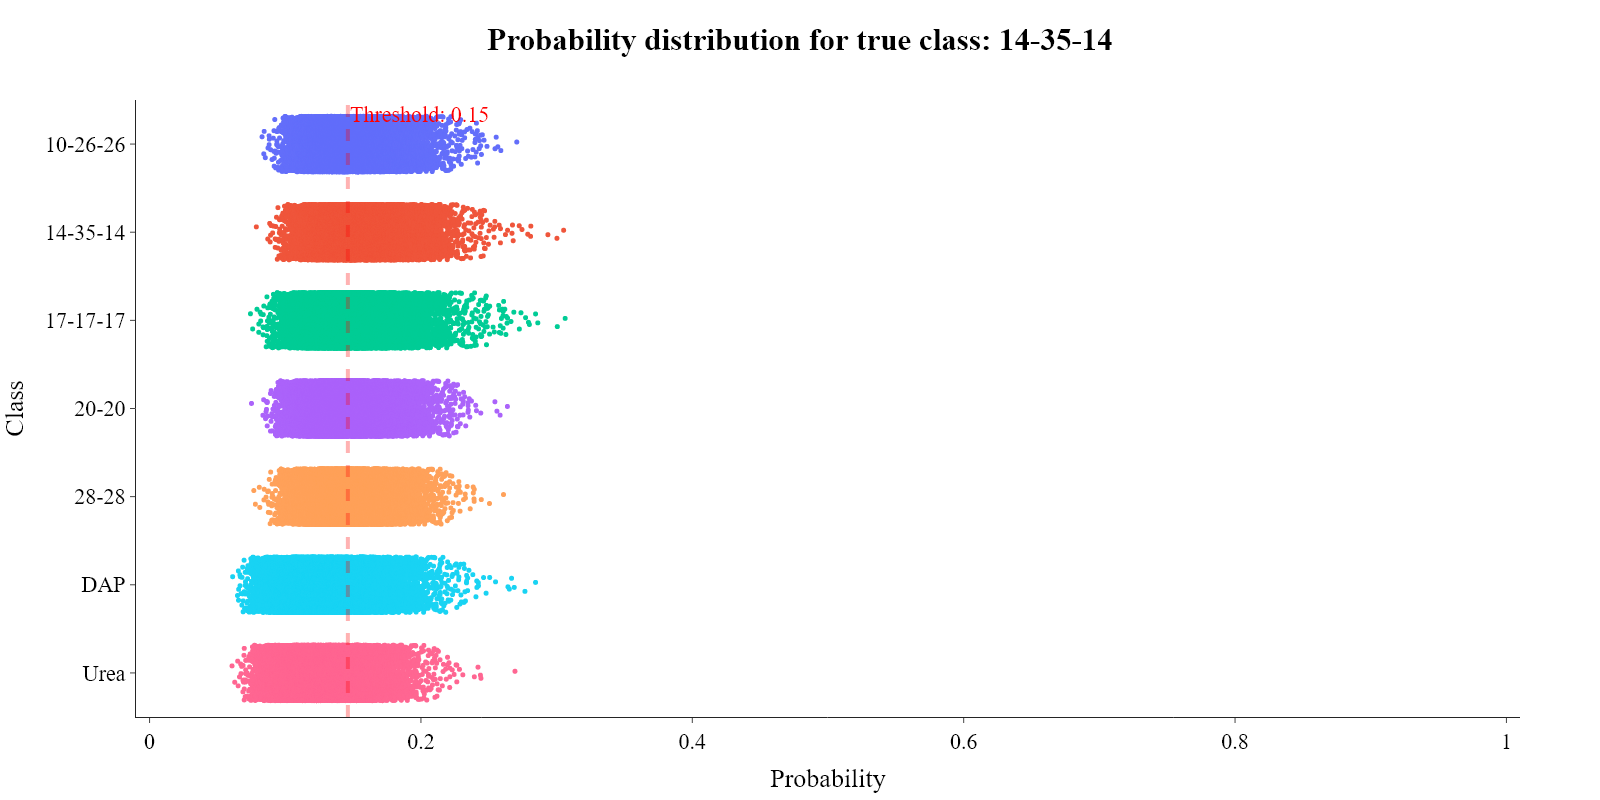

C:\Users\Kuba\AppData\Roaming\Python\Python311\site-packages\plotly\express\_core.py:1992: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



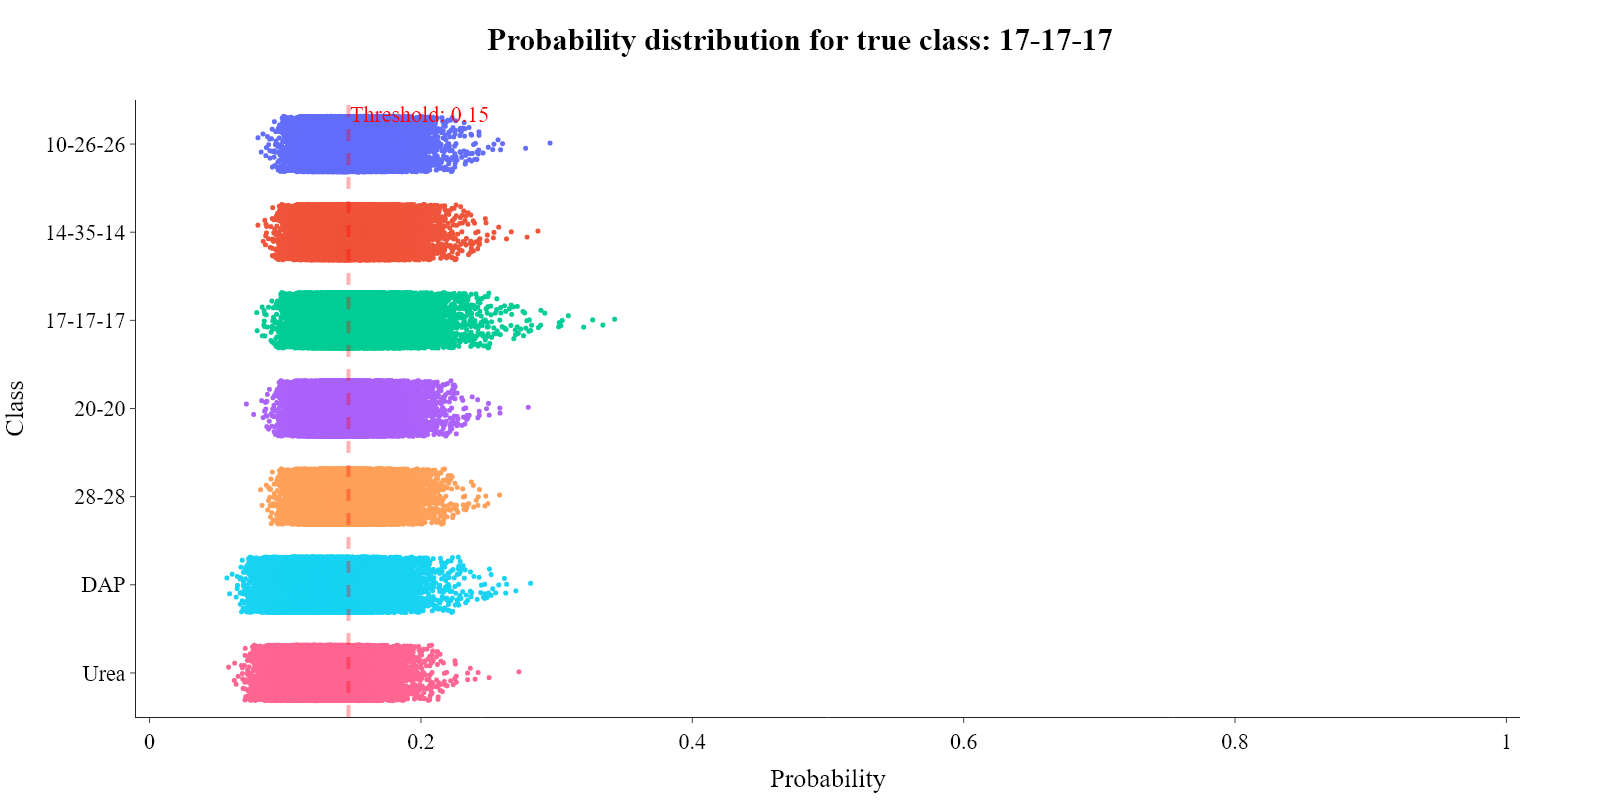

C:\Users\Kuba\AppData\Roaming\Python\Python311\site-packages\plotly\express\_core.py:1992: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



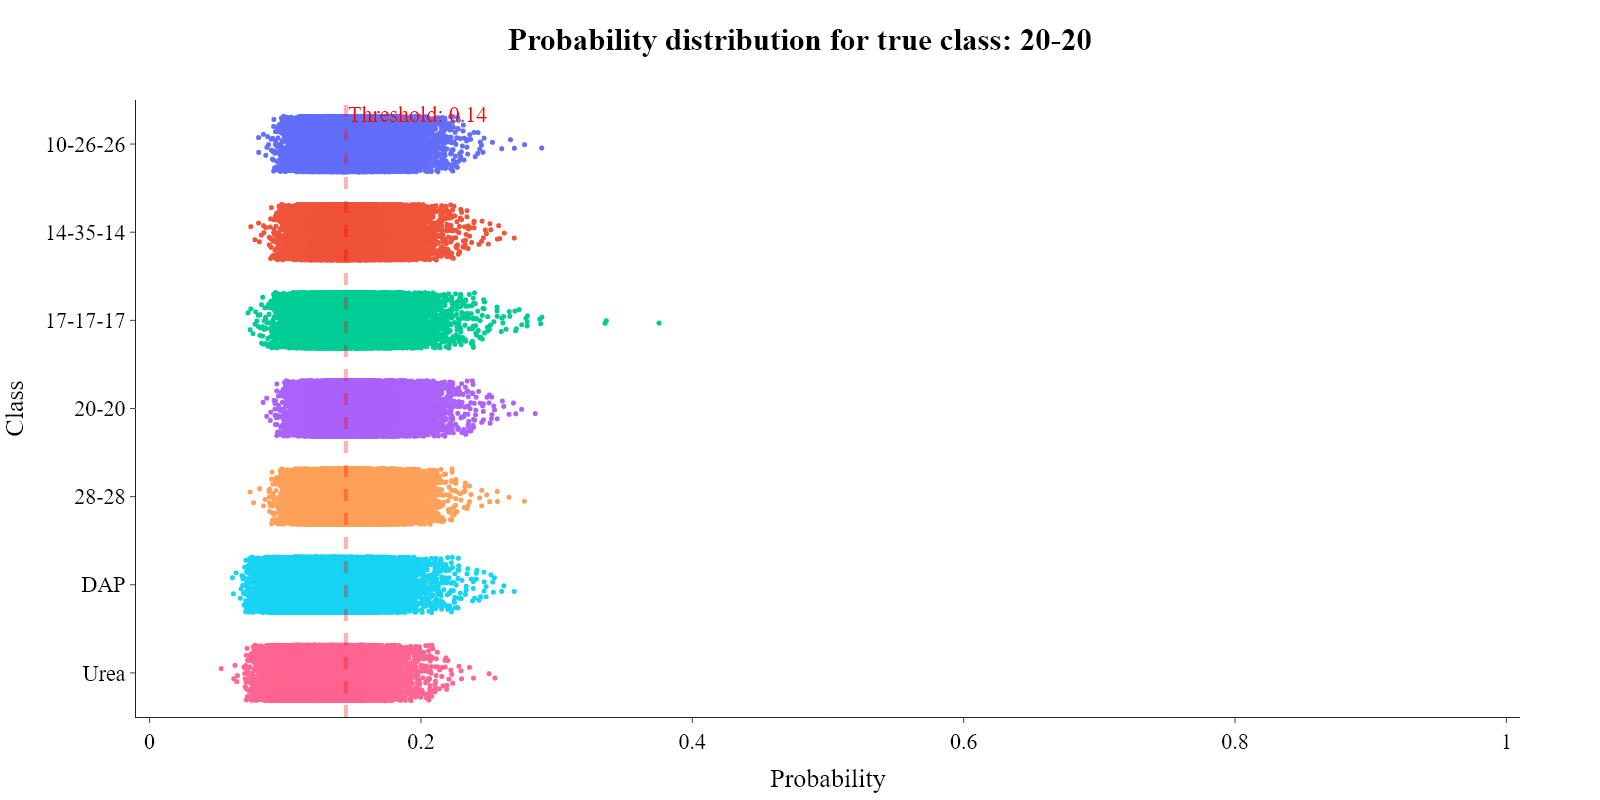

C:\Users\Kuba\AppData\Roaming\Python\Python311\site-packages\plotly\express\_core.py:1992: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



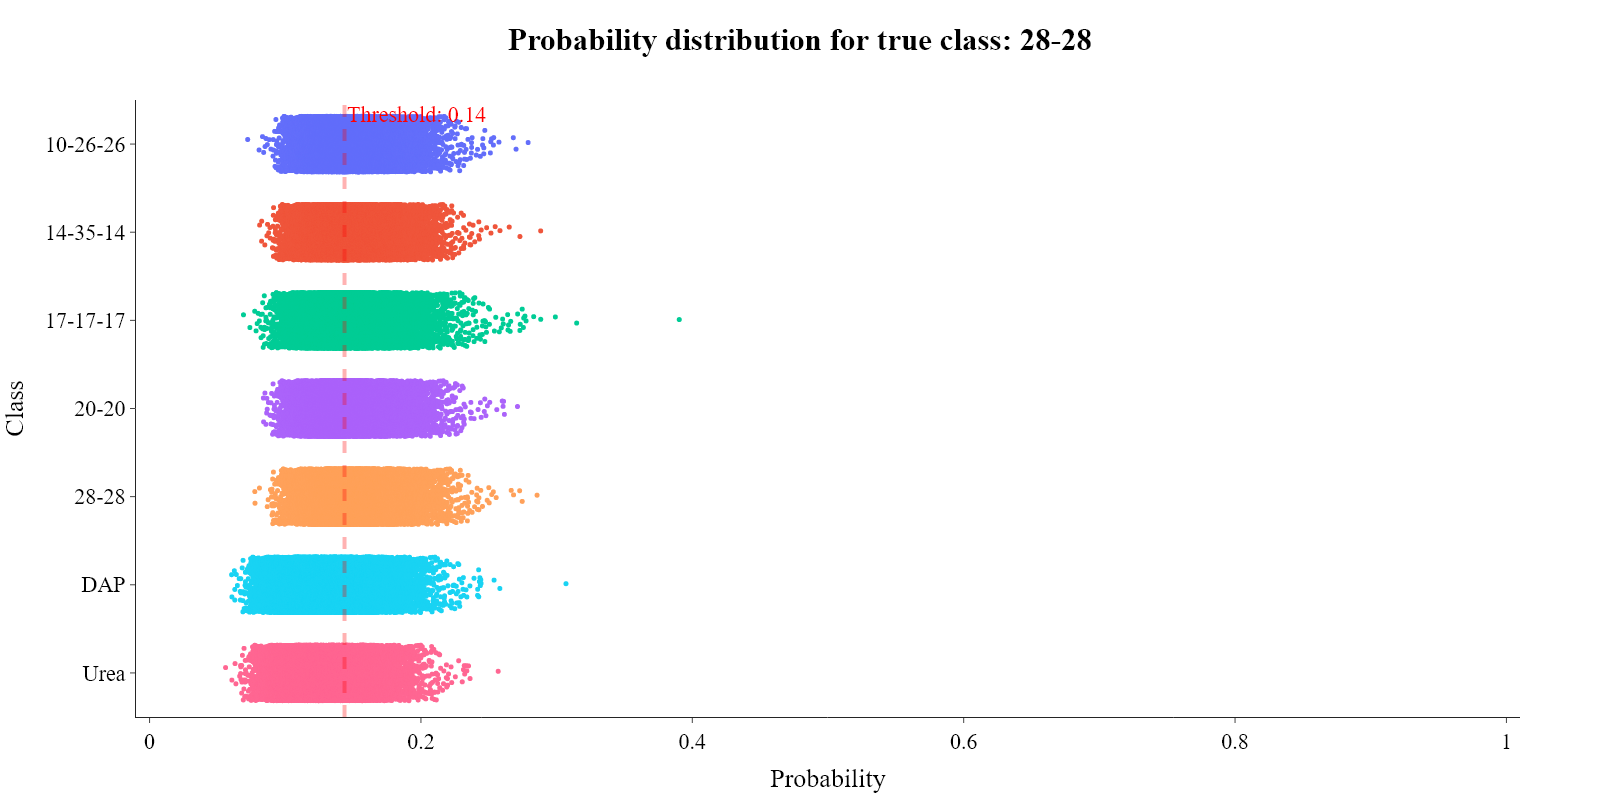

C:\Users\Kuba\AppData\Roaming\Python\Python311\site-packages\plotly\express\_core.py:1992: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



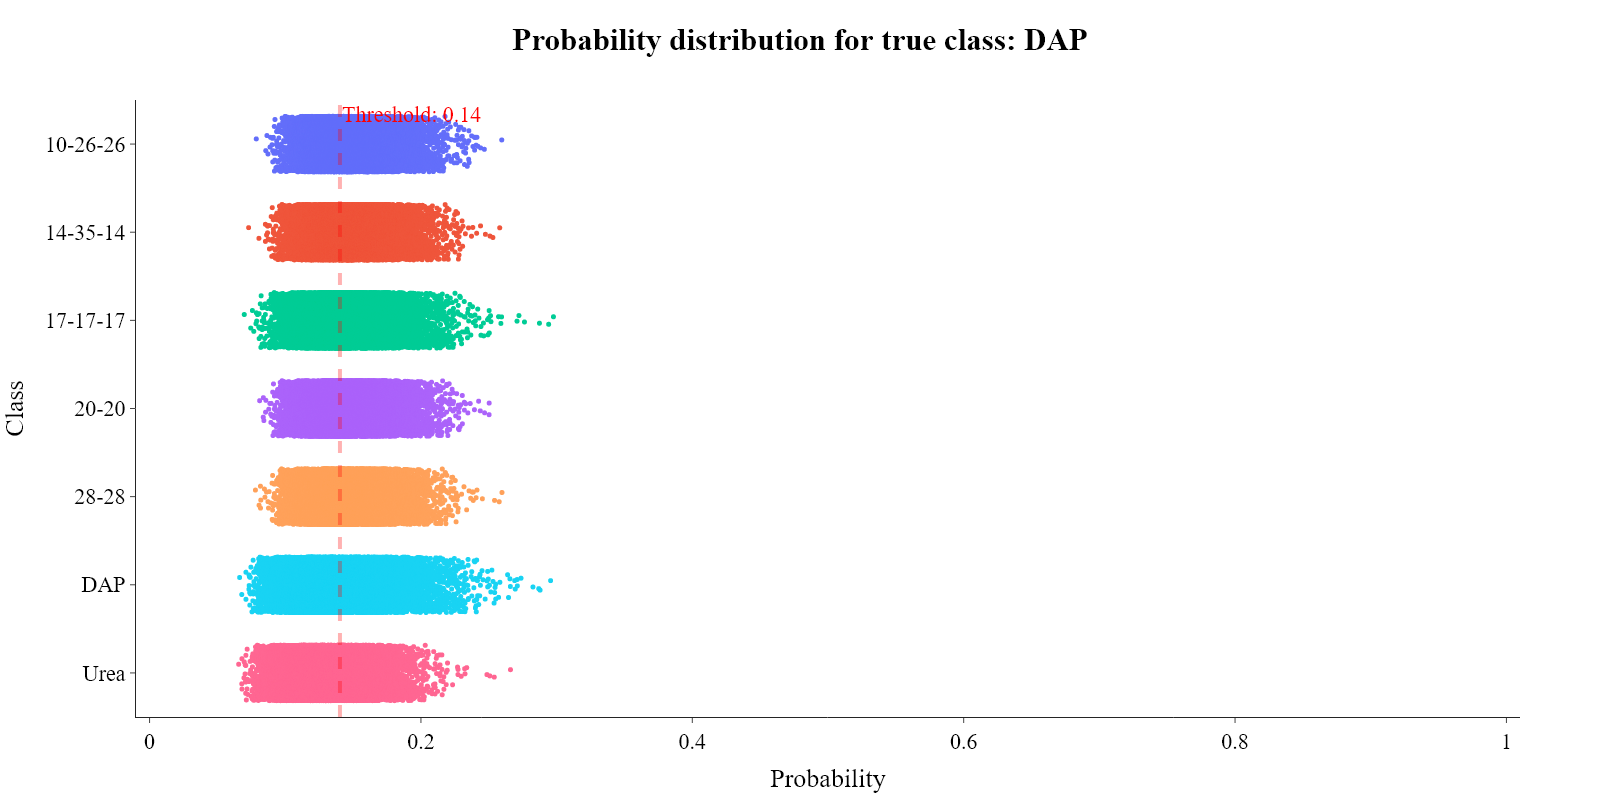

C:\Users\Kuba\AppData\Roaming\Python\Python311\site-packages\plotly\express\_core.py:1992: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



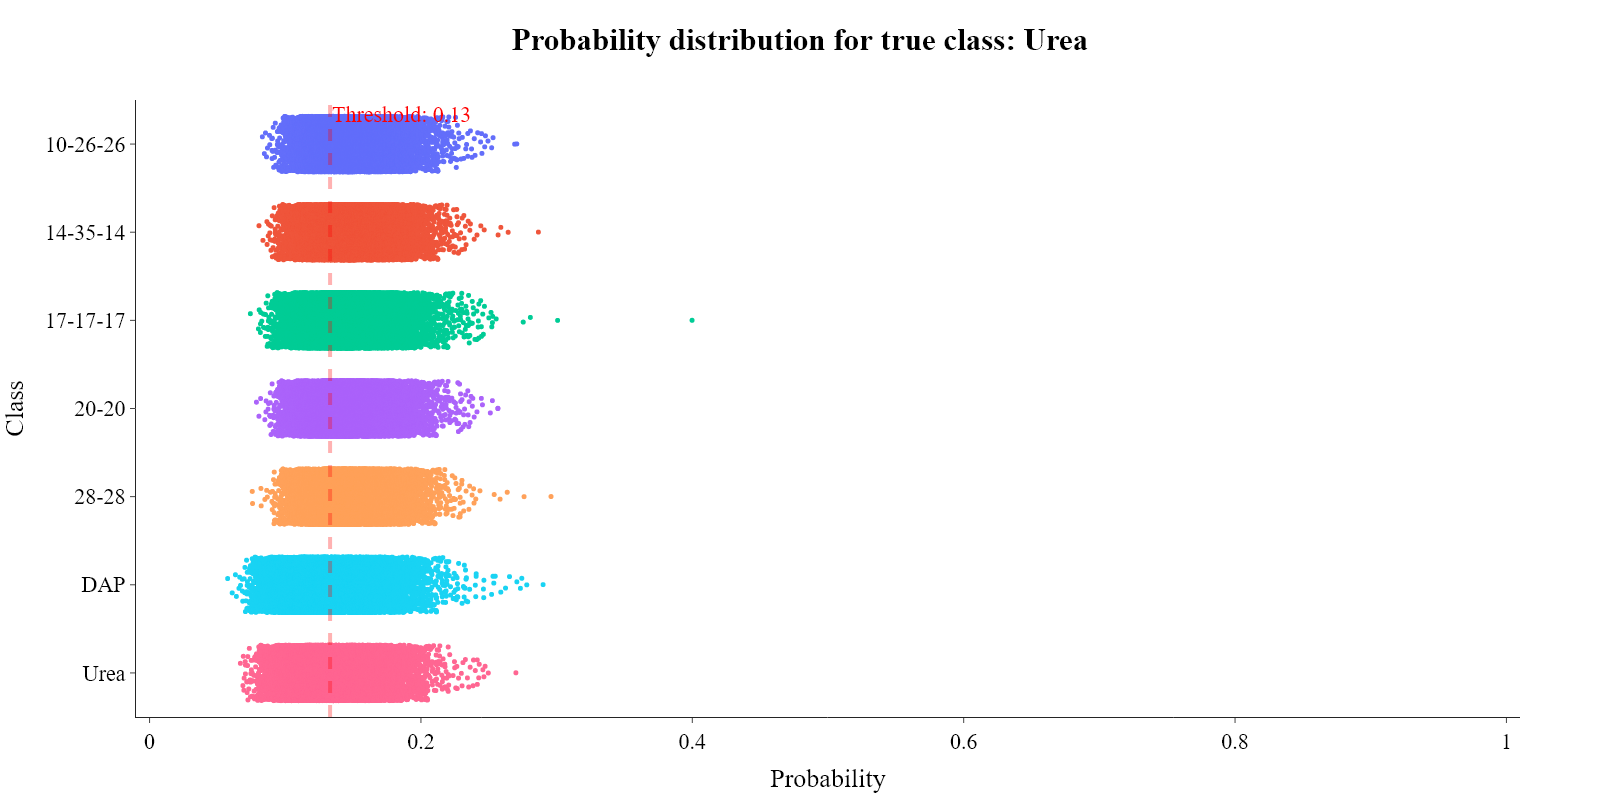

In [67]:
plots.plot_probabilities_per_class(y_true=y_test_labels, probabilities=y_test_prob, labels=label2id.keys(), cutoffs=cutoff_tuner.best_cutoffs)

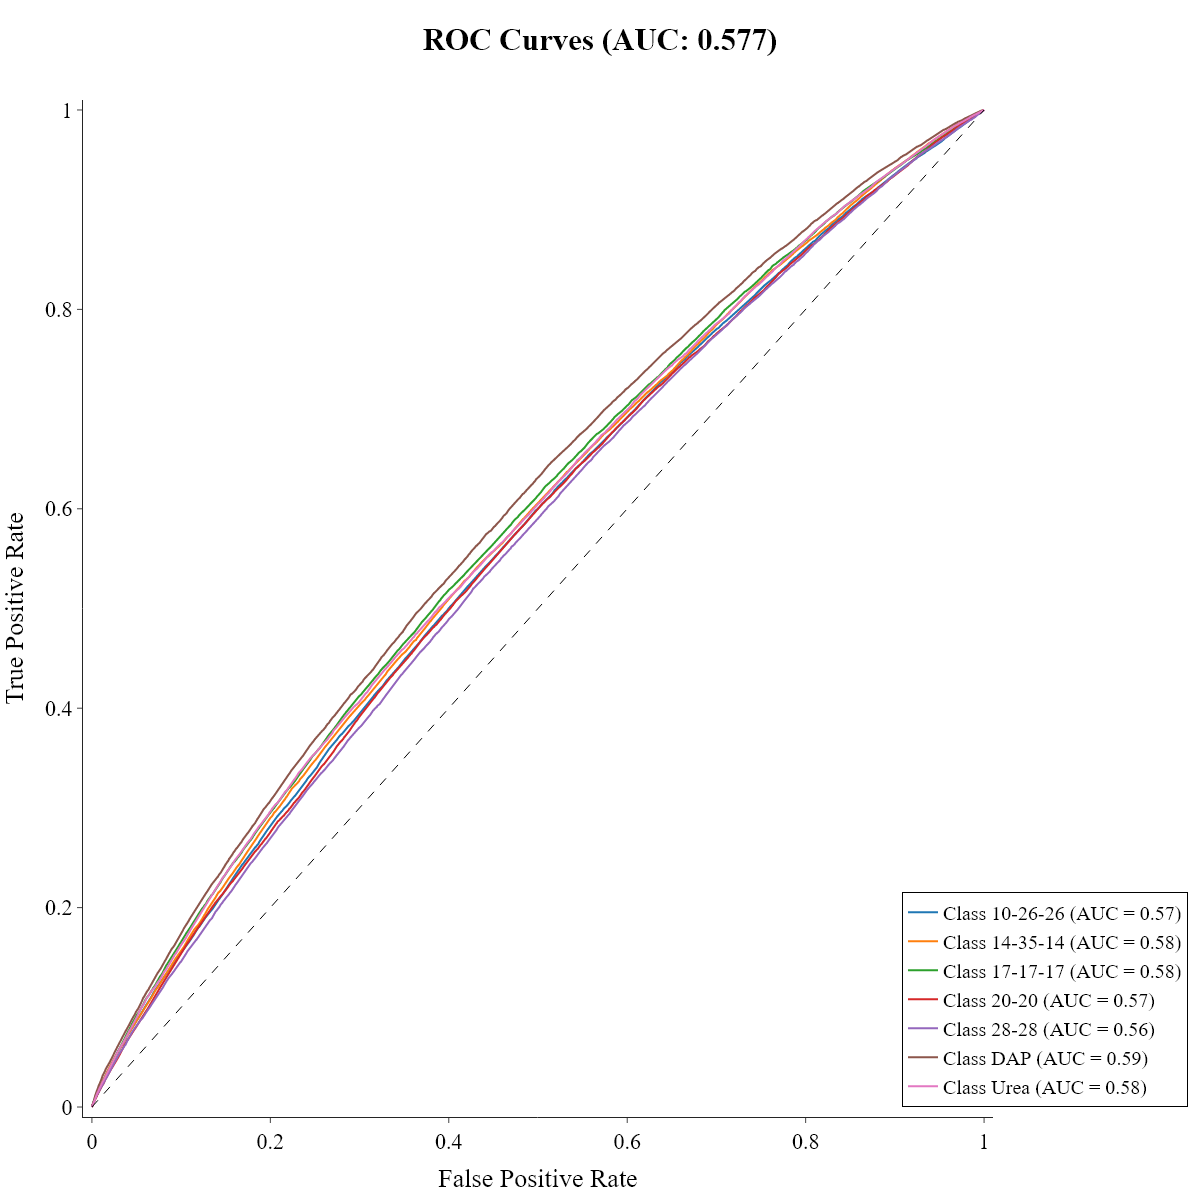

In [68]:
plots.roc_auc_multiclass(y_true=y_test_labels, probabilities=y_test_prob, labels=list(label2id.keys()))

# Final submission

In [69]:
y_pred_prob = final_model.predict_proba(test_data[independent_features])

def select_top_n_classes(y_pred_prob: np.ndarray, n: int = 3) -> list[str]:
    """
    Select top N classes based on predicted probabilities.
    
    Args:
        y_pred_prob (np.ndarray): Predicted probabilities for each class.
        n (int): Number of top classes to select.
    
    Returns:
        list[str]: List of top N class labels as strings.
    """
    top_n_indices = np.argsort(y_pred_prob, axis=1)[:, -n:][:, ::-1]
    id2label_str = {v: k for k, v in label2id.items()}
    top_n_labels = []
    for row in top_n_indices:
        labels = [id2label_str[idx] for idx in row]
        top_n_labels.append(" ".join(labels))
    return top_n_labels

top_n_classes = select_top_n_classes(y_pred_prob, n=3)

In [70]:
submission = pd.read_csv("input/sample_submission.csv")
submission[target_feature] = top_n_classes
submission.to_csv("submission.csv", index=False)
submission.head()

,id,Fertilizer Name
0,750000,DAP 14-35-14 10-26-26
1,750001,17-17-17 20-20 10-26-26
2,750002,20-20 28-28 DAP
3,750003,14-35-14 17-17-17 10-26-26
4,750004,20-20 10-26-26 28-28
